In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib as mpl
import h5py

from scipy.interpolate import CubicSpline

from tqdm.auto import tqdm

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

from multiprocess import Pool

In [3]:
workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../../../")
import pyanalib.pandas_helpers as ph
from makedf.util import *

workspace_root = os.getcwd()  
sys.path.insert(0, workspace_root + "/../")
import kinematics
import gump_cuts as gc
import loaddf
import syst

import importlib

In [4]:
# importlib.reload(gc)

In [213]:
PLOTDIR = "temp"

DOSAVE = True

import os
os.makedirs(PLOTDIR, exist_ok=True)
os.makedirs(PLOTDIR + "/png", exist_ok=True)
os.makedirs(PLOTDIR + "/pdf", exist_ok=True)

In [6]:
FONTSIZE = 14
HAWKS_COLORS = ["#315031", "#d54c28", "#1e3f54", "#c89648", "#43140b", "#95af8b"]

def add_style(ax, xlabel, title="", det="ICARUS", ylabel='Events / $10^{20}$ POT', legend_loc=None, legend_ncol=1, legend_title=None, legend_fontsize=FONTSIZE-1):
    ax.tick_params(axis='both', which='both', direction='in', length=6, width=1.5, labelsize=FONTSIZE, top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.set_xlabel(xlabel, fontsize=FONTSIZE, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=FONTSIZE, fontweight='bold')
    ax.set_title(f"$\\bf{{{det}}}$  {title}", fontsize=FONTSIZE+2)
    ax.legend(fontsize=legend_fontsize, loc=legend_loc, ncol=legend_ncol, title=legend_title, title_fontsize=FONTSIZE)

In [7]:
RECO = "PANDORA"

In [8]:
DF_DIR = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-10/"

SCV_FILES = [DF_DIR + "SBNDMCCV_%i.df" % i for i in range(3)]
SDIRT_FILE = DF_DIR + "SBND_SpringLowEMC.df"
SBEAMOFF_FILE = DF_DIR + "SBND_SpringBNBOffData.df"
SDETVARS = [
    ([DF_DIR + "SBND_SpringMC_Nom.df"], [DF_DIR + "SBND_SpringMC_0xSCE.df"], [DF_DIR + "SBND_SpringMC_2xSCE.df"]),
    ([DF_DIR + "SBND_SpringMC_WMNom.df"], [DF_DIR + "SBND_SpringMC_WMXThetaXW.df"]),
    ([DF_DIR + "SBND_SpringMC_WMNom.df"], [DF_DIR + "SBND_SpringMC_WMYZ.df"]),
]

SDETVAR_NAMES = ["SCE", "WM $X\\theta_{xw}$", "WM $YZ$"]

IRUN2_CV_FILES = [DF_DIR + "ICARUSRun2_SpringMCOverlay_rewgt.df"]
IRUN4_CV_FILES = [DF_DIR + "ICARUSRun4_SpringMCOverlay_rewgt_%i.df" % i for i in range(2)]
IRUN2_DIRT_FILES = [DF_DIR + "ICARUS_Spring_Overlay_Dirt.df"]
IRUN4_DIRT_FILES = [DF_DIR + "ICARUSRun4_Spring_Overlay_Dirt.df"]
IRUN2_BEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun2BNBOff_unblind.df"
IRUN4_BEAMOFF_FILE = DF_DIR + "ICARUS_SpringRun4BNBOff_unblind.df"

IRUN2_DETVARS = [
    ([DF_DIR + "ICARUSRun2_Spring_Overlay_Nom.df"], [DF_DIR + "ICARUSRun2_Spring_Overlay_SCE.df"]),
    ([DF_DIR + "ICARUSRun2_Spring_Overlay_Nom.df"], [DF_DIR + "ICARUSRun2_Spring_Overlay_WMXThXW.df"]),
]

IRUN4_DETVARS = [
    ([DF_DIR + "ICARUSRun4_Spring_Overlay_Nom.df"], [DF_DIR + "ICARUSRun4_Spring_Overlay_SCE.df"]),
    ([DF_DIR + "ICARUSRun2_Spring_Overlay_Nom.df"], [DF_DIR + "ICARUSRun2_Spring_Overlay_WMXThXW.df"]),
]


IDETVAR_NAMES = [
                 "SCE",
                 "WM $X\\theta_{xw}$",
                ]

IRUN2_POT = 2e20
IRUN4_POT = 3e20

In [9]:
# IDdf, IDmatch, IDpot = loaddf.load(DF_DIR + "ICARUS_Spring_WMXTHXW_rewgt.df", include_syst=False)

In [10]:
IGOAL_POT = IRUN2_POT + IRUN4_POT
SGOAL_POT = 1e20

In [11]:
def FV(df):    
    is_spine = "SPINE" in RECO
    
    ret = gc.slcfv_cut(df) & gc.mufv_cut(df) & gc.pfv_cut(df) 
    
    if is_spine:
        ret = ret & (df.is_time_contained)
    
    return ret

# NB: the flash cut is NOT applied in the load-time preselection so that the
# trigger (flash-PE scale) systematic can loosen the threshold; it is applied
# in the "selected" definition below instead.
def FVSBND(df):
    return FV(df)

def FVICARUSRun2(df):
    return FV(df)

def FVICARUSRun4(df):
    return FV(df)

In [12]:
def TrueAV(df):
    vtx = pd.DataFrame({
                        'detector': df.detector,
                        'Run': df.Run,
                        'x': df.true_vtx_x,
                       'y': df.true_vtx_y,
                       'z': df.true_vtx_z}, index=df.index)
    return gc._fv_cut(vtx, 0, 0, 0, 0)

def TrueAVSBND(df):
    return TrueAV(df)

def TrueAVICARUSRun2(df):
    return TrueAV(df)

def TrueAVICARUSRun4(df):
    return TrueAV(df)

def OOAVSBND(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVSBND(df)

def OOAVICARUS(df):
    return ~np.isnan(df.true_vtx_x) & ~TrueAVICARUSRun4(df)

In [13]:
importlib.reload(loaddf)
importlib.reload(gc)
importlib.reload(syst)

<module 'loaddf' from '/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/../loaddf.py'>

<module 'gump_cuts' from '/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/../gump_cuts.py'>

<module 'syst' from '/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/../syst.py'>

In [14]:
# Load Run 2 and Run 4 ICARUS MC separately
Idf_r2, Imatch_r2, Ipot_r2 = loaddf.loadl(IRUN2_CV_FILES, njob=min(len(IRUN2_CV_FILES), 10), detector="ICARUS Run2", 
                                 preselection=FVICARUSRun2, reweight_aFF=True, pot_univ=True, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")

Idf_r4, Imatch_r4, Ipot_r4 = loaddf.loadl(IRUN4_CV_FILES, njob=min(len(IRUN4_CV_FILES), 10), detector="ICARUS Run4", 
                                 preselection=FVICARUSRun4, reweight_aFF=True, pot_univ=True, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")


# Scale each run to its target POT before combining
loaddf.scale_pot(Idf_r2, Ipot_r2, IRUN2_POT)
loaddf.scale_pot(Idf_r4, Ipot_r4, IRUN4_POT)
Idf = pd.concat([Idf_r2, Idf_r4]).reset_index(drop=True)
Imatch = pd.concat([Imatch_r2, Imatch_r4])
Ipot = IRUN2_POT + IRUN4_POT

# Load Run 2 and Run 4 ICARUS dirt separately
Idirt_r2, Idirtmatch_r2, Idirtpot_r2 = loaddf.loadl(IRUN2_DIRT_FILES, njob=min(len(IRUN2_DIRT_FILES), 10), detector="ICARUS Run2", 
                                           preselection=FVICARUSRun2, include_syst=False, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")
Idirt_r4, Idirtmatch_r4, Idirtpot_r4 = loaddf.loadl(IRUN4_DIRT_FILES, njob=min(len(IRUN4_DIRT_FILES), 10), detector="ICARUS Run4", 
                                           preselection=FVICARUSRun4, include_syst=False, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")
loaddf.scale_pot(Idirt_r2, Idirtpot_r2, IRUN2_POT)
loaddf.scale_pot(Idirt_r4, Idirtpot_r4, IRUN4_POT)
Idirt = pd.concat([Idirt_r2, Idirt_r4]).reset_index(drop=True)


Idirtpot = IRUN2_POT + IRUN4_POT

# Load Run 2 and Run 4 ICARUS beamoff separately
Ioffbeam_r2, _, Ioffbeampot_r2 = loaddf.load(IRUN2_BEAMOFF_FILE, detector="ICARUS Run2", offbeampot=True, 
                                                   preselection=FVICARUSRun2, include_syst=False, load_truth=False, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")
Ioffbeam_r4, _, Ioffbeampot_r4 = loaddf.load(IRUN4_BEAMOFF_FILE, detector="ICARUS Run4", offbeampot=True, 
                                                   preselection=FVICARUSRun4, include_syst=False, load_truth=False, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")
loaddf.scale_pot(Ioffbeam_r2, Ioffbeampot_r2, IRUN2_POT)
loaddf.scale_pot(Ioffbeam_r4, Ioffbeampot_r4, IRUN4_POT)
Ioffbeam = pd.concat([Ioffbeam_r2, Ioffbeam_r4]).reset_index(drop=True)
Ioffbeampot = IRUN2_POT + IRUN4_POT

  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_SpringMCOverlay_rewgt.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=4] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=5] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=6] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=7] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun2_SpringMCOverlay_rewgt.df idf=8] dedup: dropped 0 duplicated ('run', 'evt', '

  0%|          | 0/2 [00:00<?, ?it/s]

[ICARUSRun4_SpringMCOverlay_rewgt_1.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_1.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_1.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_1.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_SpringMCOverlay_rewgt_0.df idf=4] dedup: dropped 0 duplicate

(np.float32(1.15649905e+21), np.float32(0.17293572))

...

(np.float32(2.476914e+20), np.float32(0.8074564))

(np.float32(1.6952675e+21), np.float32(0.17696323))

[ICARUS_SpringRun2BNBOff_unblind.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUS_SpringRun4BNBOff_unblind.df idf=0] dedup: dropped 7890 duplicated ('run', 'evt', 'nu_E0') keys (15780 hdr rows)


(np.float64(1.8288957405161357e+20), np.float64(1.0935560489826373))

(np.float64(5.255467483967318e+19), np.float64(5.708340902406878))

In [15]:
Sdf, Smatch, Spot = loaddf.loadl(SCV_FILES, njob=min(len(SCV_FILES), 10), detector="SBND",
                                 preselection=FVSBND, reweight_aFF=True, pot_univ=True, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")
Sdirt, Sdirtmatch, Sdirtpot = loaddf.load(SDIRT_FILE, detector="SBND",
                                          preselection=FVSBND, include_syst=False, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")
Soffbeam, Soffbeammatch, Soffbeampot = loaddf.load(SBEAMOFF_FILE, detector="SBND",
                                                   preselection=FVSBND, offbeampot=True, include_syst=False, load_truth=False, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir")

  0%|          | 0/3 [00:00<?, ?it/s]

[SBNDMCCV_2.df idf=0] dedup: dropped 14 duplicated ('run', 'evt', 'nu_E0') keys (28 hdr rows)
[SBNDMCCV_1.df idf=0] dedup: dropped 79 duplicated ('run', 'evt', 'nu_E0') keys (158 hdr rows)
[SBNDMCCV_0.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBNDMCCV_2.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBNDMCCV_0.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBNDMCCV_1.df idf=1] dedup: dropped 15 duplicated ('run', 'evt', 'nu_E0') keys (30 hdr rows)
[SBNDMCCV_2.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBNDMCCV_0.df idf=2] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBNDMCCV_1.df idf=2] dedup: dropped 20 duplicated ('run', 'evt', 'nu_E0') keys (40 hdr rows)
[SBNDMCCV_2.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[SBNDMCCV_0.df idf=3] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0

In [16]:
def load_detvar(detvar, detector):
    if detector == "SBND":
        FV = FVSBND
    elif detector == "ICARUS Run2":
        FV = FVICARUSRun2
    elif detector == "ICARUS Run4":
        FV = FVICARUSRun4
        
    df, match, pots = zip(*[loaddf.loadl(flist, preselection=FV, include_syst=False, detector=detector, cache_dir="/exp/sbnd/data/users/nrowe/cache_dir") for flist in detvar])
    df, pots = loaddf.match_common_evts(match, df, pots)

    return df, pots    

In [17]:
Sdetvars, Sdetvar_pots = zip(*tqdm([load_detvar(detvar, "SBND") for detvar in SDETVARS]))

  0%|          | 0/1 [00:00<?, ?it/s]

[SBND_SpringMC_Nom.df idf=0] dedup: dropped 5 duplicated ('run', 'evt', 'nu_E0') keys (10 hdr rows)
dedup: dropped 455514 duplicated rows 1.0 of the POT remaining. Before POT: 1.4257476348924867e+20, after POT 1.4257476348924867e+20.


  0%|          | 0/1 [00:00<?, ?it/s]

[SBND_SpringMC_0xSCE.df idf=0] dedup: dropped 5 duplicated ('run', 'evt', 'nu_E0') keys (10 hdr rows)
dedup: dropped 448834 duplicated rows 1.0 of the POT remaining. Before POT: 1.393366401727972e+20, after POT 1.393366401727972e+20.


  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

[SBND_SpringMC_WMNom.df idf=0] dedup: dropped 244 duplicated ('run', 'evt', 'nu_E0') keys (488 hdr rows)
[SBND_SpringMC_WMNom.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 1743754 duplicated rows 1.0 of the POT remaining. Before POT: 5.617770120089866e+20, after POT 5.617770120089866e+20.


  0%|          | 0/1 [00:00<?, ?it/s]

[SBND_SpringMC_WMYZ.df idf=0] dedup: dropped 32 duplicated ('run', 'evt', 'nu_E0') keys (64 hdr rows)
[SBND_SpringMC_WMYZ.df idf=1] dedup: dropped 1 duplicated ('run', 'evt', 'nu_E0') keys (2 hdr rows)
[SBND_SpringMC_WMYZ.df] cross-idf dedup: dropped 3 duplicated ('run', 'evt', 'nu_E0') keys (6 match rows)
dedup: dropped 1867171 duplicated rows 1.0 of the POT remaining. Before POT: 5.989052151026103e+20, after POT 5.989052151026103e+20.


  0%|          | 0/3 [00:00<?, ?it/s]

In [18]:
Ir2detvars, Ir2detvar_pots = zip(*tqdm([load_detvar(detvar, "ICARUS Run2") for detvar in IRUN2_DETVARS]))

  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_Spring_Overlay_Nom.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 842063 duplicated rows 1.0 of the POT remaining. Before POT: 1.1564993330358161e+21, after POT 1.1564993330358161e+21.


  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_Spring_Overlay_SCE.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 844729 duplicated rows 1.0 of the POT remaining. Before POT: 1.1692749896475036e+21, after POT 1.1692749896475036e+21.


  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_Spring_Overlay_Nom.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 842063 duplicated rows 1.0 of the POT remaining. Before POT: 1.1564993330358161e+21, after POT 1.1564993330358161e+21.


  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_Spring_Overlay_WMXThXW.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 750261 duplicated rows 1.0 of the POT remaining. Before POT: 1.0313543621216074e+21, after POT 1.0313543621216074e+21.


  0%|          | 0/2 [00:00<?, ?it/s]

In [19]:
Ir4detvars, Ir4detvar_pots = zip(*tqdm([load_detvar(detvar, "ICARUS Run4") for detvar in IRUN4_DETVARS]))

  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun4_Spring_Overlay_Nom.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_Spring_Overlay_Nom.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 2220885 duplicated rows 1.0 of the POT remaining. Before POT: 2.1775975210622732e+21, after POT 2.1775975210622732e+21.


  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun4_Spring_Overlay_SCE.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
[ICARUSRun4_Spring_Overlay_SCE.df idf=1] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 2225242 duplicated rows 1.0 of the POT remaining. Before POT: 2.202269084245939e+21, after POT 2.202269084245939e+21.


  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_Spring_Overlay_Nom.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 842063 duplicated rows 1.0 of the POT remaining. Before POT: 1.1564993330358161e+21, after POT 1.1564993330358161e+21.


  0%|          | 0/1 [00:00<?, ?it/s]

[ICARUSRun2_Spring_Overlay_WMXThXW.df idf=0] dedup: dropped 0 duplicated ('run', 'evt', 'nu_E0') keys (0 hdr rows)
dedup: dropped 750261 duplicated rows 1.0 of the POT remaining. Before POT: 1.0313543621216074e+21, after POT 1.0313543621216074e+21.


  0%|          | 0/2 [00:00<?, ?it/s]

In [20]:
for c in Sdf.columns:
    if "_univ" in c:
        Sdirt[c] = 1

for c in Idf.columns:
    if "_univ" in c:
        Idirt[c] = 1

if "dirt" not in Sdf.columns:
    Sdf["dirt"] = False
    Sdirt["dirt"] = True

if "dirt" not in Idf.columns:
    Idf["dirt"] = False
    Idirt["dirt"] = True

In [21]:
for i in range(len(Ir2detvars)):
    for j in range(len(Ir2detvars[i])):
        loaddf.scale_pot(Ir2detvars[i][j], Ir2detvar_pots[i][j], IRUN2_POT)

for i in range(len(Ir4detvars)):
    for j in range(len(Ir4detvars[i])):
        loaddf.scale_pot(Ir4detvars[i][j], Ir4detvar_pots[i][j], IRUN4_POT)

(np.float32(1.1564047e+21), np.float32(0.17294984))

(np.float32(1.15647745e+21), np.float32(0.17293896))

(np.float32(1.019629e+21), np.float32(0.19614978))

(np.float32(1.019657e+21), np.float32(0.1961444))

(np.float32(2.1774307e+21), np.float32(0.13777706))

(np.float32(2.1773538e+21), np.float32(0.13778193))

(np.float32(1.019629e+21), np.float32(0.29422465))

(np.float32(1.019657e+21), np.float32(0.2942166))

In [22]:
Idetvars = []

for i in range(len(Ir4detvars)):
    Idetvars.append([])
    for j in range(len(Ir4detvars)):
        Idetvars[i].append(pd.concat([Ir2detvars[i][j], Ir4detvars[i][j]]).reset_index(drop=True))

In [23]:
print("SBND CV")
loaddf.scale_pot(Sdf, Spot, SGOAL_POT)
print("SBND Dirt")
loaddf.scale_pot(Sdirt, Sdirtpot, SGOAL_POT)
print("SBND Beam OFF")
loaddf.scale_pot(Soffbeam, Soffbeampot, SGOAL_POT)
for i in range(len(Sdetvars)):
    print("SBND", SDETVAR_NAMES[i])
    for j in range(len(Sdetvars[i])):
        loaddf.scale_pot(Sdetvars[i][j], Sdetvar_pots[i][j], SGOAL_POT)

SBND CV


(np.float32(5.298958e+20), np.float32(0.18871635))

SBND Dirt


(np.float32(3.701933e+20), np.float32(0.27012917))

SBND Beam OFF


...

(np.float32(5.598661e+20), np.float32(0.17861414))

(np.float32(5.5807956e+20), np.float32(0.17918593))

SBND WM $YZ$


(np.float32(5.5618527e+20), np.float32(0.1797962))

(np.float32(5.5444213e+20), np.float32(0.18036148))

In [24]:
print("ICARUS CV -- already scaled during load")
print("ICARUS Dirt -- already scaled during load")
print("ICARUS Detvars -- already scaled during load")
print("ICARUS Beam OFF -- already scaled during load")

ICARUS CV -- already scaled during load
ICARUS Dirt -- already scaled during load
ICARUS Detvars -- already scaled during load
ICARUS Beam OFF -- already scaled during load


In [25]:
chi2vars = [
    "mu_chi2_of_mu_cand",
    "prot_chi2_of_mu_cand",
    "mu_chi2_of_prot_cand",
    "prot_chi2_of_prot_cand",
]

chi2labels = [
    "$\\chi^2_\\mu$ of Muon Candidate",
    "$\\chi^2_p$ of Muon Candidate",
    "$\\chi^2_\\mu$ of Proton Candidate",
    "$\\chi^2_p$ of Proton Candidate",
]

chi2bins = [
    np.linspace(0, 60, 21),
    np.linspace(0, 300, 21),
    np.linspace(0, 60, 21),
    np.linspace(0, 300, 21)
]

In [26]:
chi2_variations = ["smear13", "hi", "alpha_p", "beta_p", "R_p"]

chi2_variation_names = [
    "Smeared dE/dx",
    "Gain Hi",
    "EMB $\\alpha + 0.008$",
    # "EMB $\\alpha - 0.008$",
    "EMB $\\beta + 0.008$",
    "EMB $R + 0.02$",
]

In [27]:
for c in chi2vars:
    for chi2_var in chi2_variations:
        Sdirt[c.replace("chi2", "chi2" + chi2_var)] = Sdirt[c]
        Idirt[c.replace("chi2", "chi2" + chi2_var)] = Idirt[c]

In [28]:
Sdf = pd.concat([Sdf[~Sdf.dirt], Sdirt])
Idf = pd.concat([Idf[~Idf.dirt], Idirt])

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

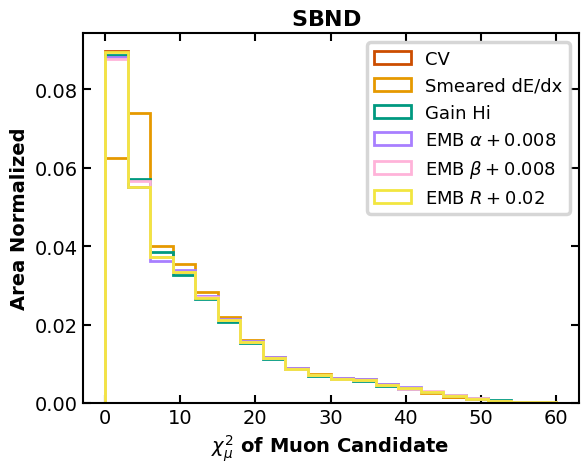

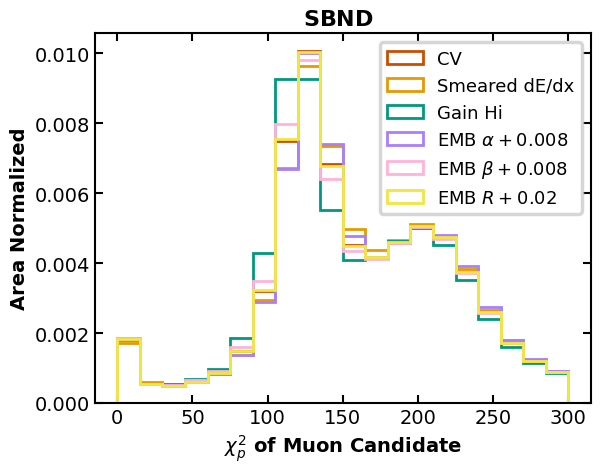

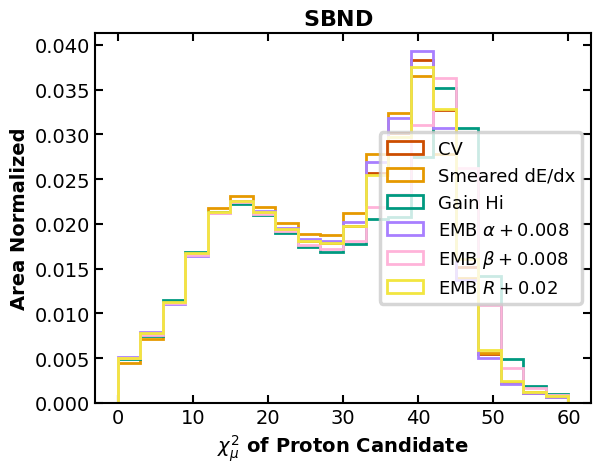

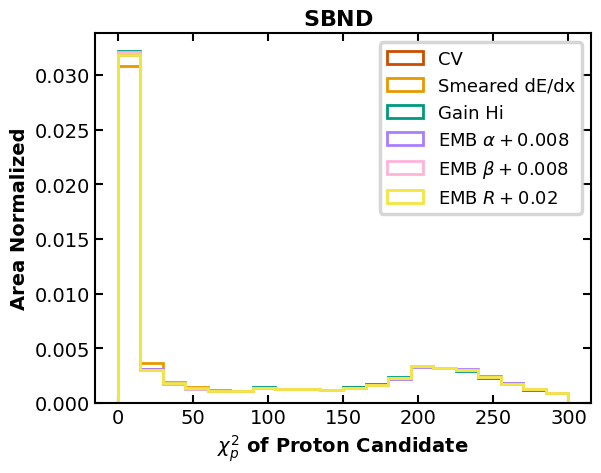

In [29]:
for i, (c,l,b) in enumerate(zip(chi2vars, chi2labels, chi2bins)):
    plt.figure(i)
    _ = plt.hist(Sdf[c], bins=b, density=True, histtype="step", linewidth=2, label="CV")
    for chi2_var, label in zip(chi2_variations, chi2_variation_names):
        _ = plt.hist(Sdf[c.replace("chi2", "chi2" + chi2_var)], bins=b, density=True, histtype="step", linewidth=2, label=label)
    add_style(plt.gca(), l, det="SBND", ylabel="Area Normalized")

    if DOSAVE:
        plt.savefig(PLOTDIR + "/png/SBND_%s_variations.png" % c, bbox_inches="tight")
        plt.savefig(PLOTDIR + "/pdf/SBND_%s_variations.pdf" % c, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

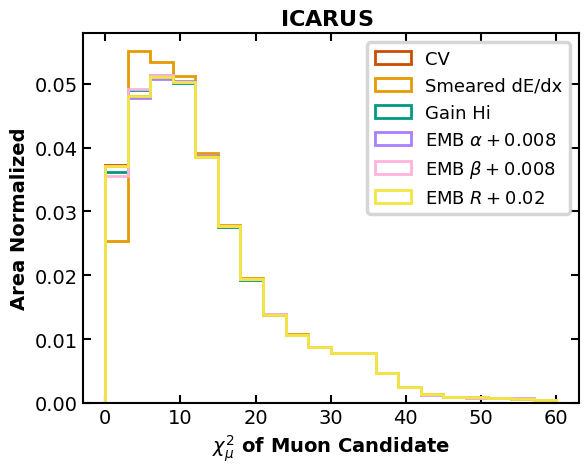

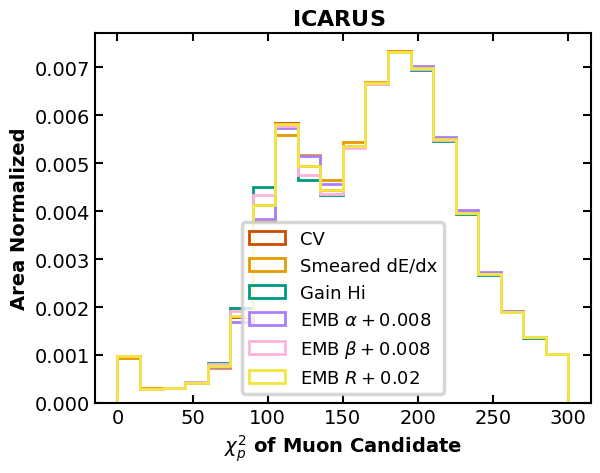

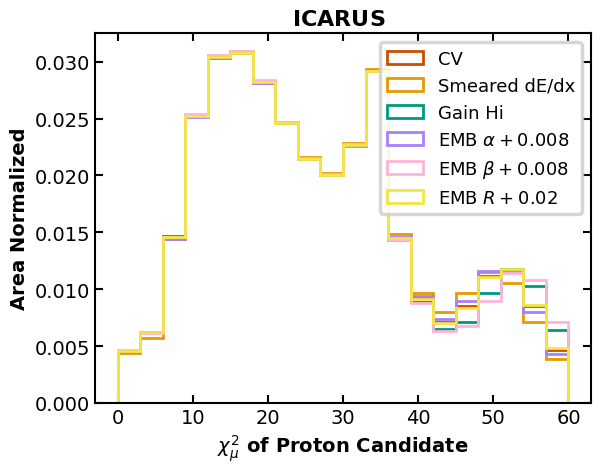

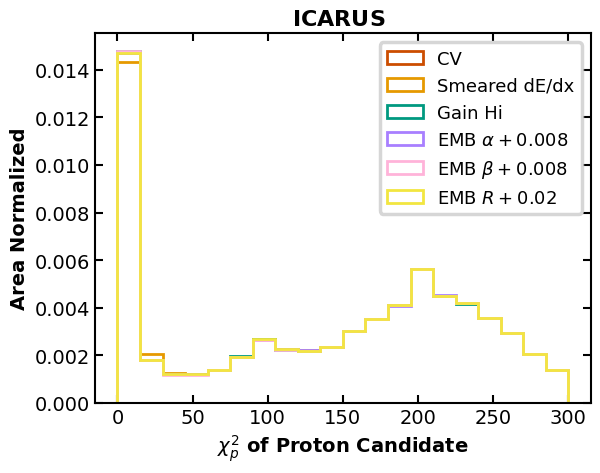

In [30]:
for i, (c,l,b) in enumerate(zip(chi2vars, chi2labels, chi2bins)):
    plt.figure(i)
    _ = plt.hist(Idf[c], bins=b, density=True, histtype="step", linewidth=2, label="CV")
    for chi2_var, label in zip(chi2_variations, chi2_variation_names):
        _ = plt.hist(Idf[c.replace("chi2", "chi2" + chi2_var)], bins=b, density=True, histtype="step", linewidth=2, label=label)
    add_style(plt.gca(), l, det="ICARUS", ylabel="Area Normalized")

    if DOSAVE:
        plt.savefig(PLOTDIR + "/png/ICARUS_%s_variations.png" % c, bbox_inches="tight")
        plt.savefig(PLOTDIR + "/pdf/ICARUS_%s_variations.pdf" % c, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

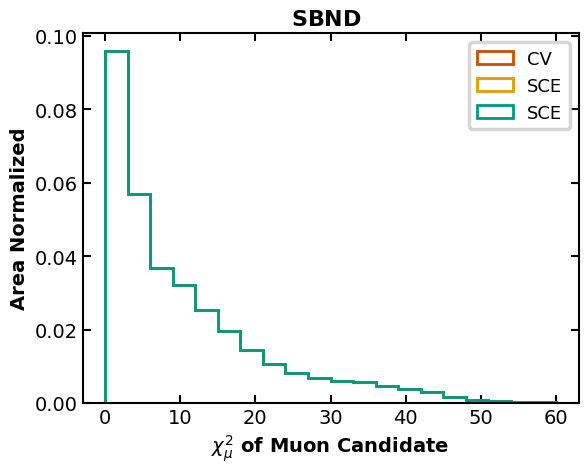

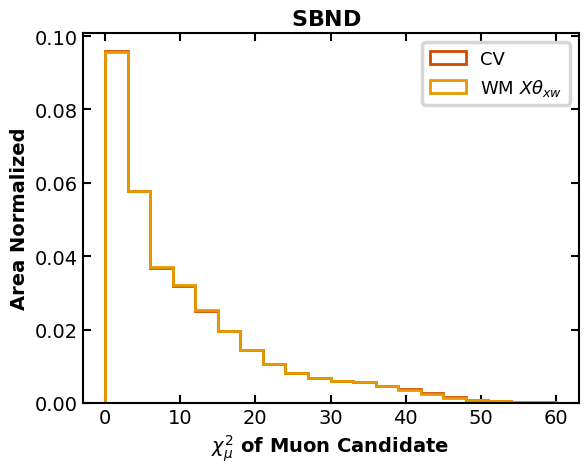

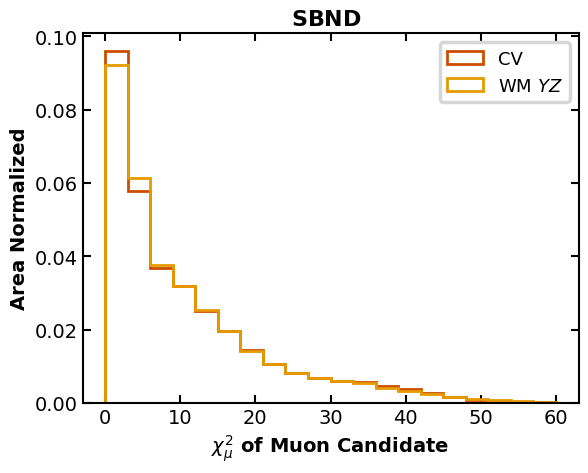

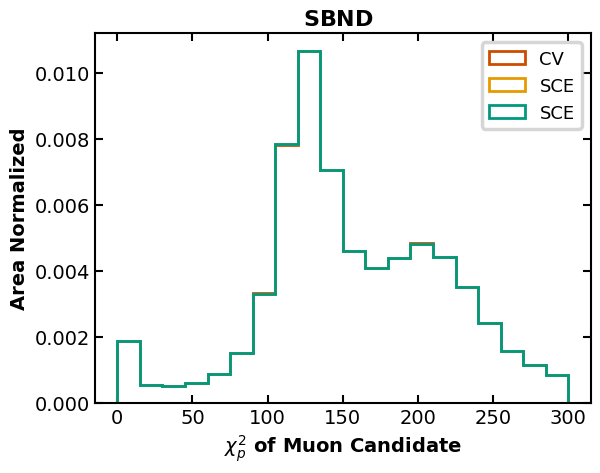

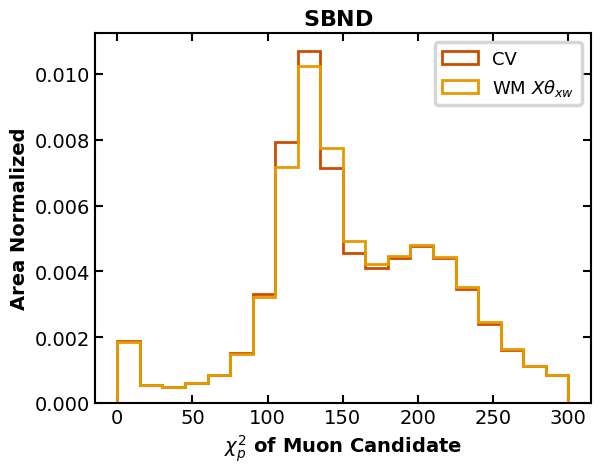

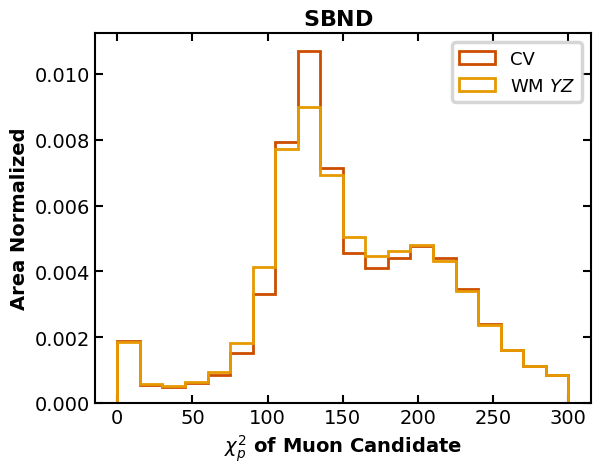

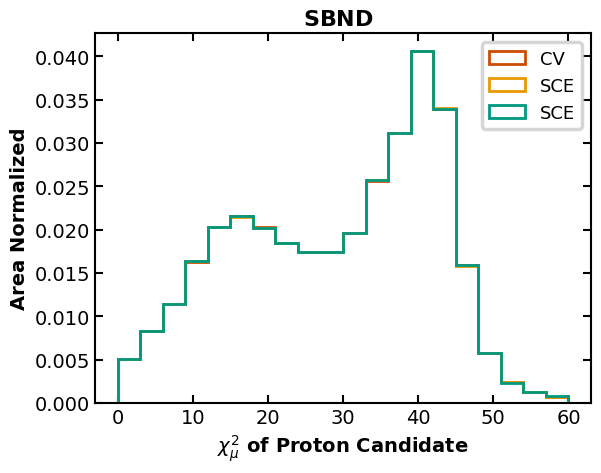

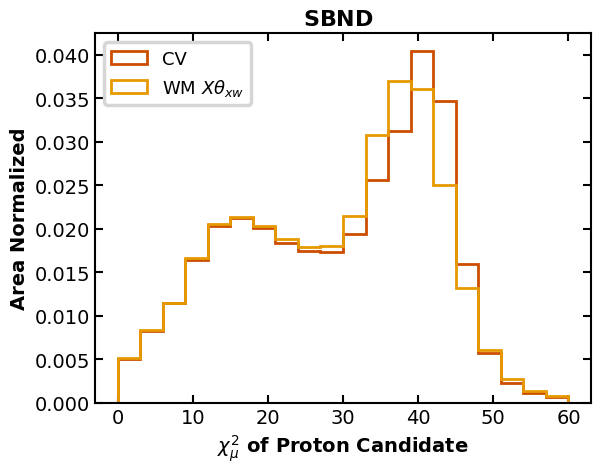

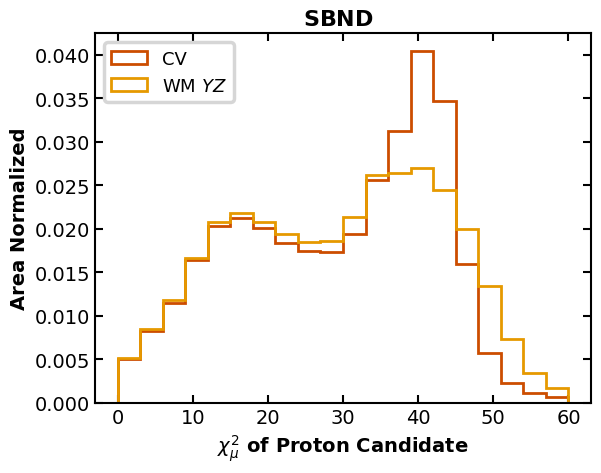

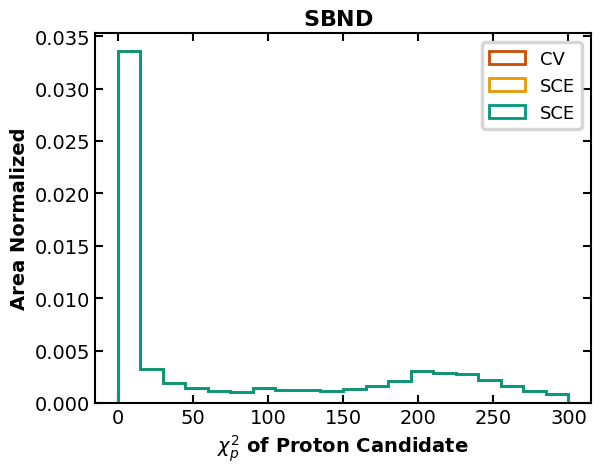

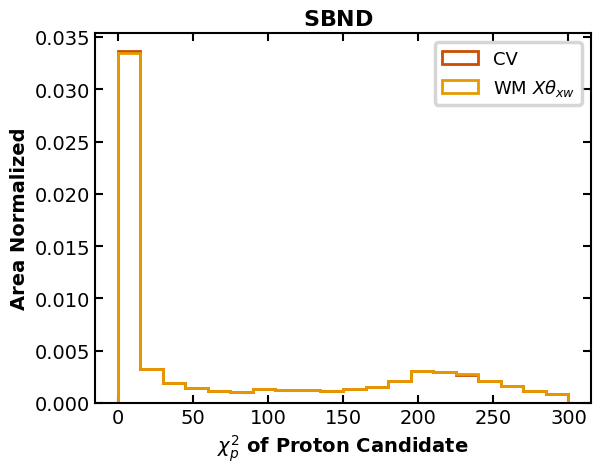

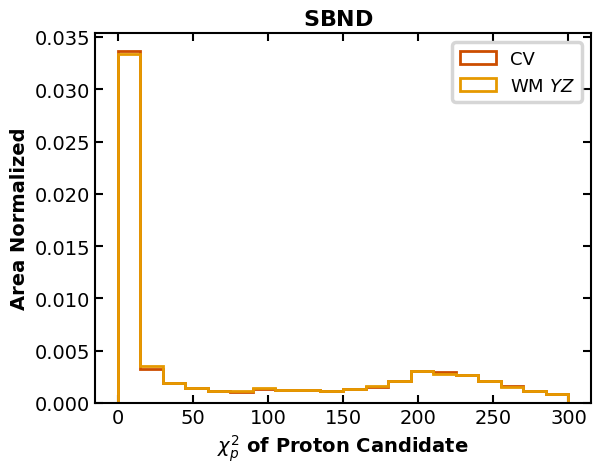

In [31]:
ifig = 0
for i, (c,l,b) in enumerate(zip(chi2vars, chi2labels, chi2bins)):
    for j in range(len(Sdetvars)):
        plt.figure(ifig)
        varname = SDETVAR_NAMES[j]
        _ = plt.hist(Sdetvars[j][0][c], bins=b, density=True, histtype="step", linewidth=2, label="CV")
        for indd, d in enumerate(Sdetvars[j][1:]):
            _ = plt.hist(d[c], bins=b, density=True, histtype="step", linewidth=2, label=varname)
        add_style(plt.gca(), l, det="SBND", ylabel="Area Normalized")
    
        if DOSAVE:
            plt.savefig(PLOTDIR + "/png/SBND_detvar_%s_variation_%s.png" % (c, varname), bbox_inches="tight")
            plt.savefig(PLOTDIR + "/pdf/SBND_detvar_%s_variation_%s.pdf" % (c, varname), bbox_inches="tight")

        ifig += 1

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

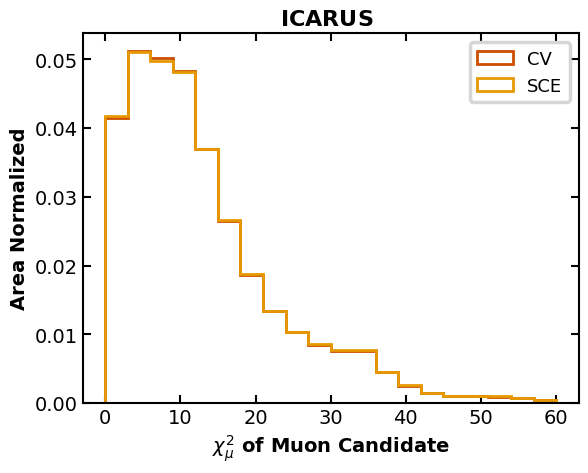

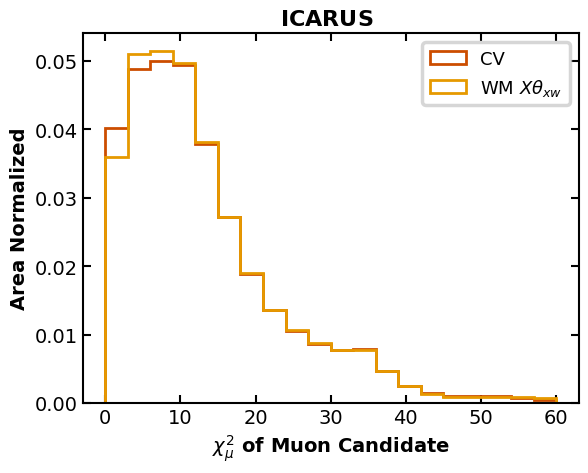

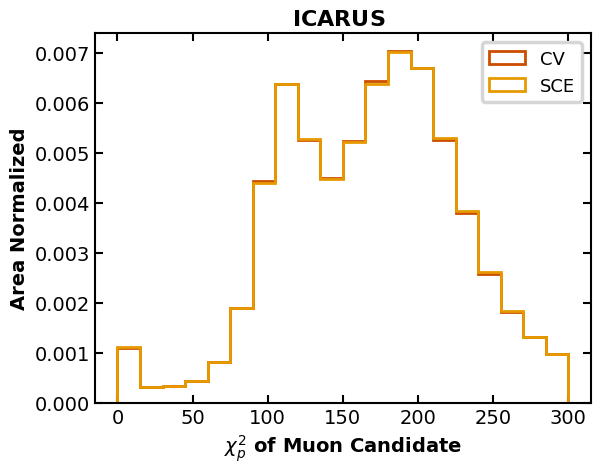

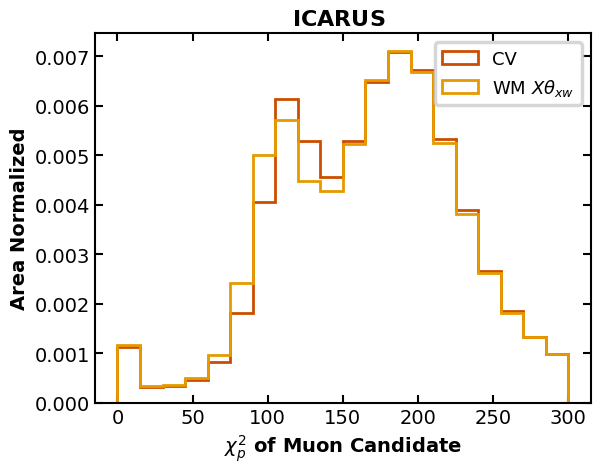

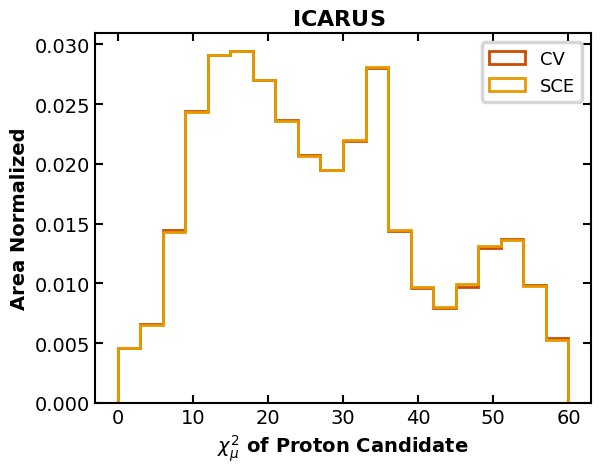

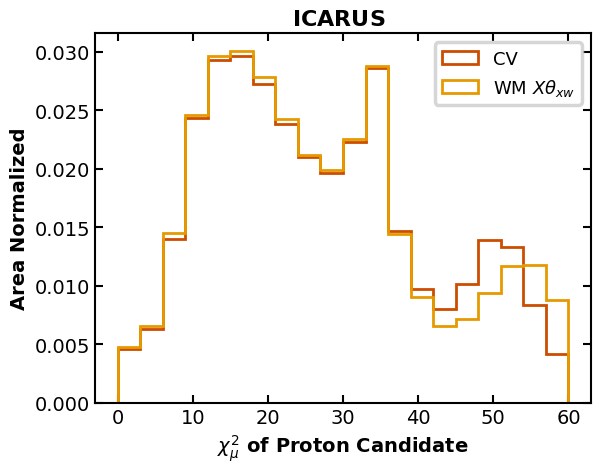

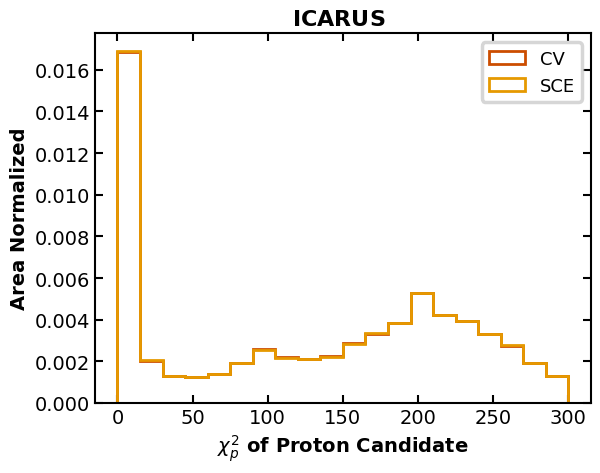

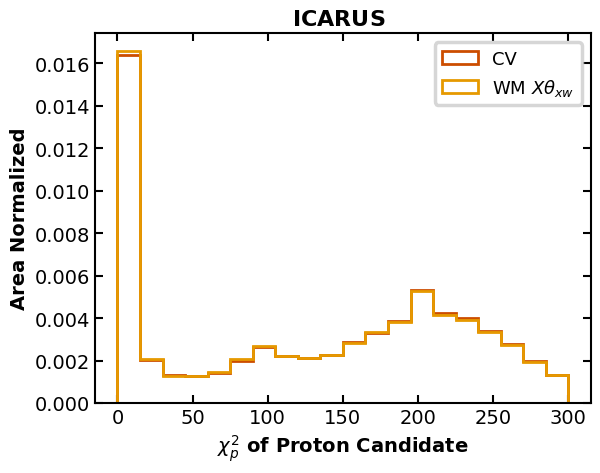

In [32]:
ifig = 0
for i, (c,l,b) in enumerate(zip(chi2vars, chi2labels, chi2bins)):
    for j in range(len(Idetvars)):
        plt.figure(ifig)
        varname = IDETVAR_NAMES[j]
        _ = plt.hist(Idetvars[j][0][c], bins=b, density=True, histtype="step", linewidth=2, label="CV")
        for indd, d in enumerate(Idetvars[j][1:]):
            _ = plt.hist(d[c], bins=b, density=True, histtype="step", linewidth=2, label=varname)
        add_style(plt.gca(), l, det="ICARUS", ylabel="Area Normalized")
    
        if DOSAVE:
            plt.savefig(PLOTDIR + "/png/ICARUS_detvar_%s_variation_%s.png" % (c, varname), bbox_inches="tight")
            plt.savefig(PLOTDIR + "/pdf/ICARUS_detvar_%s_variation_%s.pdf" % (c, varname), bbox_inches="tight")

        ifig += 1

In [33]:
# ADD IN PID VARIATIONS
def v_variation(df, setvars):
    df = df[[c for c in df.columns if "univ" not in c]].copy()
    for (new, old) in setvars:
        df[new] = df[old]
    return df

def v_chi2smear(df):
    setvars = [
        ("mu_chi2_of_mu_cand", "mu_chi2smear13_of_mu_cand"),
        ("mu_chi2_of_prot_cand",  "mu_chi2smear13_of_prot_cand"),
        ("prot_chi2_of_mu_cand", "prot_chi2smear13_of_mu_cand"),
        ("prot_chi2_of_prot_cand",  "prot_chi2smear13_of_prot_cand"),
    ]
    return v_variation(df, setvars)


def v_chi2hi(df):
    setvars = [
        ("mu_chi2_of_mu_cand", "mu_chi2hi_of_mu_cand"),
        ("mu_chi2_of_prot_cand",  "mu_chi2hi_of_prot_cand"),
        ("prot_chi2_of_mu_cand", "prot_chi2hi_of_mu_cand"),
        ("prot_chi2_of_prot_cand",  "prot_chi2hi_of_prot_cand"),
    ]
    return v_variation(df, setvars)

def v_calovariation(df, variation):
    setvars = [
        ("mu_chi2_of_mu_cand", "mu_chi2%s_of_mu_cand" % variation),
        ("mu_chi2_of_prot_cand",  "mu_chi2%s_of_prot_cand" % variation),
        ("prot_chi2_of_mu_cand", "prot_chi2%s_of_mu_cand" % variation),
        ("prot_chi2_of_prot_cand",  "prot_chi2%s_of_prot_cand" % variation),
    ]
    return v_variation(df, setvars)

In [34]:
Schi2_detvars = [v_calovariation(Sdf, V) for V in chi2_variations]
Ichi2_detvars = [v_calovariation(Idf, V) for V in chi2_variations]

SCHI2_DETVAR_NAMES = ["dE/dx Res.", "Calo. Gain", "EMB $\\alpha$", "EMB $\\beta$", "EMB $R$"]
ICHI2_DETVAR_NAMES = ["dE/dx Res.", "Calo. Gain", "EMB $\\alpha$", "EMB $\\beta$", "EMB $R$"]

In [35]:
S_TRIGGER_NAMES = ["Trigger"]
I_TRIGGER_NAMES = ["Trigger Run 2", "Trigger Run 4"]

In [36]:
importlib.reload(gc)

<module 'gump_cuts' from '/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/nb/../gump_cuts.py'>

In [37]:
import gump_cuts as gc

def signalbox(df):
    return gc.win_len(df, skip_flash=True)

In [38]:
assert(np.all(np.isnan(Sdirt[~OOAVSBND(Sdirt)].true_vtx_x)))

In [39]:
assert(len(Idirt) == 0 or np.all(np.isnan(Idirt[~OOAVICARUS(Idirt)].true_vtx_x)))

In [40]:
Sdf["selected_noflash"] = signalbox(Sdf)
Sdf["selected"] = Sdf.selected_noflash & gc.flash_cut(Sdf)
Sdirt["selected"] = signalbox(Sdirt) & gc.flash_cut(Sdirt)
Soffbeam["selected"] = signalbox(Soffbeam) & gc.flash_cut(Soffbeam)

for i in range(len(Sdetvars)):
    for j in range(len(Sdetvars[i])):
        Sdetvars[i][j]["selected"] = signalbox(Sdetvars[i][j]) & gc.flash_cut(Sdetvars[i][j])

for i in range(len(Schi2_detvars)):
    Schi2_detvars[i]["selected"] = signalbox(Schi2_detvars[i]) & gc.flash_cut(Schi2_detvars[i])


In [41]:
Idf["selected_noflash"] = signalbox(Idf)
Idf["selected"] = Idf.selected_noflash & gc.flash_cut(Idf)
if len(Idirt) > 0:
    Idirt["selected"] = signalbox(Idirt) & gc.flash_cut(Idirt)
else:
    Idirt["selected"] = False
Ioffbeam["selected"] = signalbox(Ioffbeam) & gc.flash_cut(Ioffbeam)

for i in range(len(Idetvars)):
    for j in range(len(Idetvars[i])):
        Idetvars[i][j]["selected"] = signalbox(Idetvars[i][j]) & gc.flash_cut(Idetvars[i][j])

for i in range(len(Ichi2_detvars)):
    Ichi2_detvars[i]["selected"] = signalbox(Ichi2_detvars[i]) & gc.flash_cut(Ichi2_detvars[i])


In [42]:
Sdf["true_E"] = Sdf.true_E.fillna(-1)
Sdirt["true_E"] = Sdirt.true_E.fillna(-1)
Soffbeam["true_E"] = -1

for i in range(len(Sdetvars)):
    for j in range(len(Sdetvars[i])):
        Sdetvars[i][j]["true_E"] = Sdetvars[i][j].true_E.fillna(-1)

for i in range(len(Schi2_detvars)):
    Schi2_detvars[i]["true_E"] = Schi2_detvars[i].true_E.fillna(-1)

In [43]:
Idf["true_E"] = Idf.true_E.fillna(-1)
Idirt["true_E"] = Idirt.true_E.fillna(-1)
Ioffbeam["true_E"] = -1

for i in range(len(Idetvars)):
    for j in range(len(Idetvars[i])):
        Idetvars[i][j]["true_E"] = Idetvars[i][j].true_E.fillna(-1)

for i in range(len(Ichi2_detvars)):
    Ichi2_detvars[i]["true_E"] = Ichi2_detvars[i].true_E.fillna(-1)

In [44]:
# ============================================================
# TRIGGER SYSTEMATIC: flash-PE scale-factor uncertainty
# ============================================================
# Best-fit MC PE scale factors from the data/MC fits in FlashMCDataComparison.ipynb
# (applied to flash_maxpe at load time in loaddf.py):
#   SBND: 0.642 +/- 0.005   ICARUS Run2: 0.632 +/- 0.024   ICARUS Run4: 0.358 +/- 0.017
#
# Varying the scale s -> s*(1 -+ f), f = unc/s, is equivalent to varying the
# threshold on flash_maxpe: T -> T/(1 -+ f). The flash cut is applied in the
# "selected" definition (NOT the load-time preselection), so both the
# tightened- and loosened-threshold universes are available.
TRIG_PE_SCALE     = {1: 0.642, 2: 0.632, 4: 0.358}  # Run -> best-fit s (matches loaddf.py)
TRIG_PE_SCALE_UNC = {1: 0.005, 2: 0.024, 4: 0.017}  # Run -> unc. on s
TRIG_THRESHOLD    = {1: 2000, 2: 5000., 4: 1000.}  # Run -> gump_cuts.flash_cut threshold

def trig_flash_cut_var(df, updn, runs=None):
    """Flash cut with the threshold varied by the +/-1 sigma PE-scale uncertainty.

    updn = +1: scale DOWN 1 sigma -> threshold UP   (fewer events)
    updn = -1: scale UP   1 sigma -> threshold DOWN (more events)
    runs: restrict the variation to these runs (others stay at the CV threshold);
          used to make the ICARUS Run2 / Run4 variations uncorrelated.
    """
    sel = pd.Series(False, index=df.index)
    for run, T in TRIG_THRESHOLD.items():
        f = TRIG_PE_SCALE_UNC[run] / TRIG_PE_SCALE[run]
        Tvar = T / (1 - updn*f) if (runs is None or run in runs) else T
        sel = sel | ((df.Run == run) & (df.flash_maxpe > Tvar))
    return sel

# SBND (all rows Run 1). NB: Sdf/Idf include the (MC) dirt rows, which correctly
# participate in the variation; the (data) offbeam samples correctly do not.
Sdf["selected_trig_up"] = Sdf["selected_noflash"] & trig_flash_cut_var(Sdf, +1)
Sdf["selected_trig_dn"] = Sdf["selected_noflash"] & trig_flash_cut_var(Sdf, -1)

# ICARUS: vary one run at a time -> Run2 and Run4 uncorrelated
Idf["selected_trig_r2_up"] = Idf["selected_noflash"] & trig_flash_cut_var(Idf, +1, runs=[2])
Idf["selected_trig_r2_dn"] = Idf["selected_noflash"] & trig_flash_cut_var(Idf, -1, runs=[2])
Idf["selected_trig_r4_up"] = Idf["selected_noflash"] & trig_flash_cut_var(Idf, +1, runs=[4])
Idf["selected_trig_r4_dn"] = Idf["selected_noflash"] & trig_flash_cut_var(Idf, -1, runs=[4])


In [45]:
# --- Trigger-variation diagnostics ---
trig_cols = {(1, "SBND"): ("selected_trig_up", "selected_trig_dn"),
             (2, "ICARUS"): ("selected_trig_r2_up", "selected_trig_r2_dn"),
             (4, "ICARUS"): ("selected_trig_r4_up", "selected_trig_r4_dn")}

for det, df in [("SBND", Sdf), ("ICARUS", Idf)]:
    for run in sorted(df.Run.unique()):
        upcol, dncol = trig_cols[(run, det)]
        inrun = (df.Run == run)
        T = TRIG_THRESHOLD[run]
        f = TRIG_PE_SCALE_UNC[run] / TRIG_PE_SCALE[run]
        wcv = df.loc[df.selected & inrun, "glob_scale"].sum()
        wup = df.loc[df[upcol] & inrun, "glob_scale"].sum()
        wdn = df.loc[df[dncol] & inrun, "glob_scale"].sum()
        print("%s Run %i: T = %.0f -> %.1f (up) / %.1f (dn), f = %.2f%%" %
              (det, run, T, T/(1-f), T/(1+f), 100*f))
        print("   selected: %.2f -> %.2f (%+.2f%%) up / %.2f (%+.2f%%) dn" %
              (wcv, wup, 100*(wup/wcv - 1), wdn, 100*(wdn/wcv - 1)))

# Consistency: tightening can only remove events, loosening can only add them
assert not (Sdf.selected_trig_up & ~Sdf.selected).any()
assert not (Sdf.selected & ~Sdf.selected_trig_dn).any()
assert not ((Idf.selected_trig_r2_up | Idf.selected_trig_r4_up) & ~Idf.selected).any()
assert not (Idf.selected & ~(Idf.selected_trig_r2_dn & Idf.selected_trig_r4_dn)).any()


SBND Run 1: T = 2000 -> 2015.7 (up) / 1984.5 (dn), f = 0.78%
   selected: 35435.04 -> 35432.96 (-0.01%) up / 35436.44 (+0.00%) dn
ICARUS Run 2: T = 5000 -> 5197.4 (up) / 4817.1 (dn), f = 3.80%
   selected: 7805.50 -> 7784.04 (-0.27%) up / 7825.23 (+0.25%) dn
ICARUS Run 4: T = 1000 -> 1049.9 (up) / 954.7 (dn), f = 4.75%
   selected: 18918.70 -> 18916.09 (-0.01%) up / 18921.66 (+0.02%) dn


In [276]:
Ssystematics = [
    loaddf.FluxSystematic(Sdf),
    loaddf.XSecSystematic(Sdf),
    syst.NormalizationSystematic(0.005),
    syst.SystematicList(
        [syst.SampleSystematic(detvar[1:], cvdf=detvar[0]) for detvar in Sdetvars] + # detector variation samples
        [syst.SampleSystematic(d) for d in Schi2_detvars] + # chi2 variations 
        [syst.SelectionSystematic(Sdf, ["selected_trig_up", "selected_trig_dn"])] + # Trigger (flash-PE scale)
        [syst.SystSampleSystematic(Sdf[Sdf.is_cosmic], norm=0.2)] + # Placeholder 20% cosmic uncertainty
        [syst.StatSampleSystematic(Sdf)] # MC Stat
    ),
    syst.SystSampleSystematic(Sdf[OOAVSBND(Sdf)]),
    syst.StatSampleSystematic(Soffbeam),
]

Isystematics = [
    loaddf.FluxSystematic(Idf),
    loaddf.XSecSystematic(Idf),
    syst.NormalizationSystematic(0.005),
    syst.SystematicList(
        [syst.SampleSystematic(detvar[1:], cvdf=detvar[0]) for detvar in Idetvars] + # detector variation samples
        [syst.SampleSystematic(d) for d in Ichi2_detvars] + # chi2 variations
        # Trigger (flash-PE scale): Run2 and Run4 varied independently -> uncorrelated sum
        [
            syst.SelectionSystematic(Idf, ["selected_trig_r2_up", "selected_trig_r2_dn"]),
            syst.SelectionSystematic(Idf, ["selected_trig_r4_up", "selected_trig_r4_dn"])
        ] + 
        [syst.StatSampleSystematic(Idf)] # MC Stat
    ),
    syst.SystSampleSystematic(Idf[OOAVICARUS(Idf)]),
    syst.StatSampleSystematic(Ioffbeam, norm=0.5), # TODO: change after unblinding. Simulate scaling up stats by 2x.
    
]

systematics = [
    syst.CorrelatedSystematic(Ssystematics[0], Isystematics[0]),
    syst.CorrelatedSystematic(Ssystematics[1], Isystematics[1]),
    # POT norm is correlated SBND Run1 (1e20) - ICARUS Run4 (3e20), and uncorrelated ICARUS Run 2 (2e20)
    syst.SystematicList(
        [
            syst.UnCorrelatedSystematic(syst.NormalizationSystematic(0), syst.NormalizationSystematic(0.005*(2./5.))),
            syst.CorrelatedSystematic(syst.NormalizationSystematic(0.005), syst.NormalizationSystematic(0.005*(3./5.))),
        ]),
    syst.UnCorrelatedSystematic(Ssystematics[3], Isystematics[3]),
    syst.UnCorrelatedSystematic(Ssystematics[4], Isystematics[4]),
    syst.UnCorrelatedSystematic(Ssystematics[5], Isystematics[5]),
]


labels = [
    "Flux",
    "XSec",
    "POT Norm.",
    "Detector",
    "Dirt",
    "Beam Off",
    "Stat",
]

In [277]:
# # Impact of CVwgt
# _ = plt.hist(Sdf.loc[Sdf[cut], "true_E"], weights=Sdf.loc[Sdf[cut], "glob_scale"], 
#              bins=np.linspace(0, 2, 11), histtype="step", linewidth=2)
# _ = plt.hist(Sdf.loc[Sdf[cut], "true_E"], weights=Sdf.loc[Sdf[cut], "glob_scale"]/Sdf.loc[Sdf[cut], "cvwgt"], 
#              bins=np.linspace(0, 2, 11), histtype="step", linewidth=2)

In [278]:
52# # Impact of CVwgt
# _ = plt.hist(Idf.loc[Idf[cut], "true_E"], weights=Idf.loc[Idf[cut], "glob_scale"], 
#              bins=np.linspace(0, 2, 11), histtype="step", linewidth=2)
# _ = plt.hist(Idf.loc[Idf[cut], "true_E"], weights=Idf.loc[Idf[cut], "glob_scale"]/Idf.loc[Idf[cut], "cvwgt"], 
#              bins=np.linspace(0, 2, 11), histtype="step", linewidth=2)

52

In [279]:
var = "nu_E_calo"
wgt = "glob_scale"
cut = "selected"
# bins = np.linspace(0, 1.5, 11)[2:]
bins = np.array([0.0, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5])
bins = np.array([0.3, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.25, 1.5])
centers = (bins[1:] + bins[:-1]) / 2

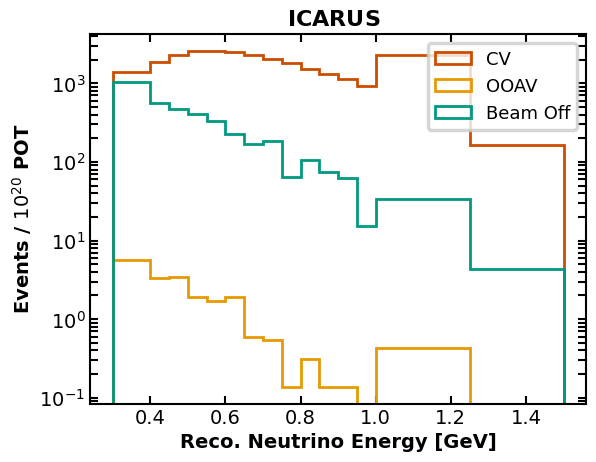

In [280]:
_ = plt.hist(Idf.loc[Idf[cut] & ~OOAVICARUS(Idf), var], bins=bins, weights=Idf.loc[Idf[cut] & ~OOAVICARUS(Idf), wgt], 
             histtype="step", linewidth=2, label="CV")
_ = plt.hist(Idf.loc[Idf[cut] & OOAVICARUS(Idf), var], bins=bins, weights=Idf.loc[Idf[cut] & OOAVICARUS(Idf), wgt], 
             histtype="step", linewidth=2, label="OOAV")
_ = plt.hist(Ioffbeam.loc[Ioffbeam[cut], var], bins=bins, weights=Ioffbeam.loc[Ioffbeam[cut], wgt], histtype="step", linewidth=2, label="Beam Off")

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS")
plt.yscale("log")

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ICARUS_altsamples.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ICARUS_altsamples.pdf", bbox_inches="tight")
    

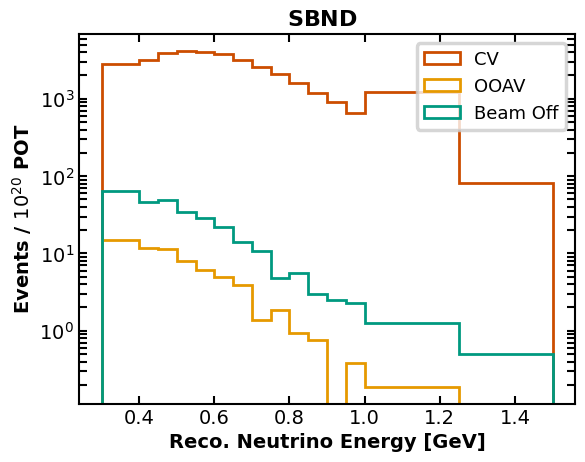

In [281]:
_ = plt.hist(Sdf.loc[Sdf[cut] & ~OOAVSBND(Sdf), var], bins=bins, weights=Sdf.loc[Sdf[cut] & ~OOAVSBND(Sdf), wgt], 
             histtype="step", linewidth=2, label="CV")
_ = plt.hist(Sdf.loc[Sdf[cut] & OOAVSBND(Sdf), var], bins=bins, weights=Sdf.loc[Sdf[cut] & OOAVSBND(Sdf), wgt], 
             histtype="step", linewidth=2, label="OOAV")
# _ = plt.hist(Sdirt.loc[Sdirt[cut], var], bins=bins, weights=Sdirt.loc[Sdirt[cut], wgt], histtype="step", linewidth=2, label="Dirt")
_ = plt.hist(Soffbeam.loc[Soffbeam[cut], var], bins=bins, weights=Soffbeam.loc[Soffbeam[cut], wgt], histtype="step", linewidth=2, label="Beam Off")

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")
plt.yscale("log")

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/SBND_altsamples.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/SBND_altsamples.pdf", bbox_inches="tight")
    

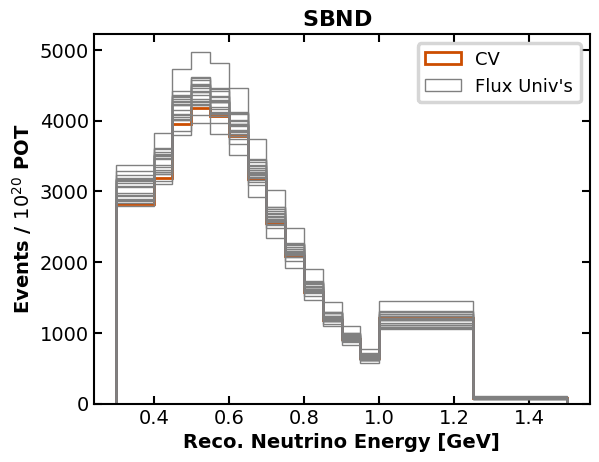

In [282]:
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt], histtype="step", linewidth=2, label="CV")

for i in range(20):
    w = Sdf[wgt]*Sdf["flux_univ%i" % i]
    label = "Flux Univ's" if i == 0 else None
    _ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w[Sdf[cut]], histtype="step", linewidth=1, color="gray", label=label)


add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")

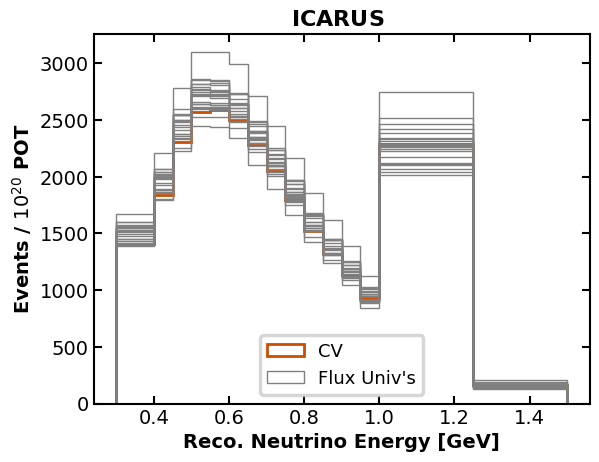

In [283]:
_ = plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt], histtype="step", linewidth=2, label="CV")

for i in range(20):
    w = Idf[wgt]*Idf["flux_univ%i" % i]
    label = "Flux Univ's" if i == 0 else None
    _ = plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w[Idf[cut]], histtype="step", linewidth=1, color="gray", label=label)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS")

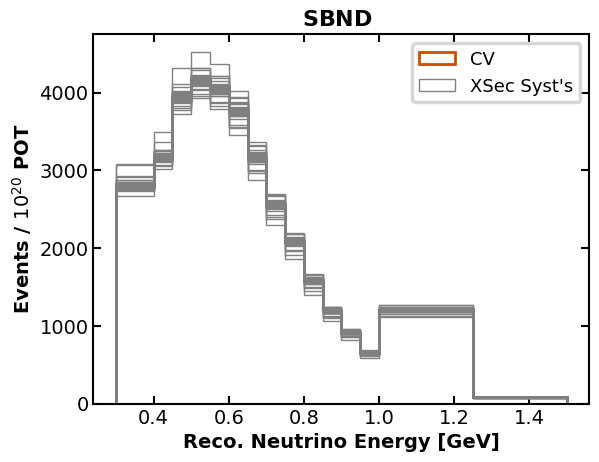

In [284]:
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt], histtype="step", linewidth=2, label="CV")

for i,s in enumerate(loaddf.xsec_syst):
    w = Sdf[wgt]*Sdf["%s_univ" % s]
    label = "XSec Syst's" if i == 0 else None
    _ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=w[Sdf[cut]], histtype="step", linewidth=1, color="gray", label=label)


add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")

In [285]:
xsec_systs_toplot = loaddf.xsec_syst

(0.8, 1.2)

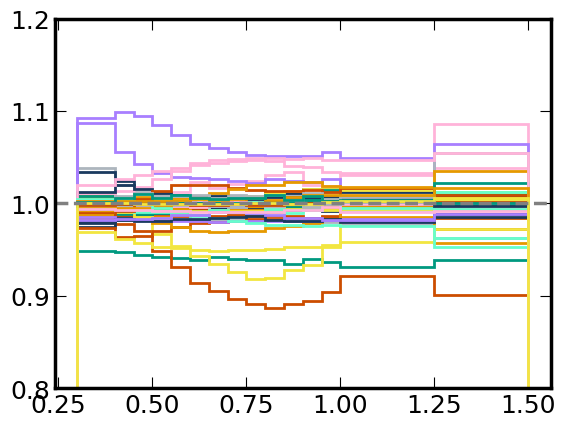

In [286]:
CV = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt])[0]


vs = []
ls = []

for i,s in enumerate(xsec_systs_toplot):
    w = Sdf[wgt]*Sdf["%s_univ" % s]
    v = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=w[Sdf[cut]])[0]
    _ = plt.hist(centers, bins=bins, weights=v/CV, histtype="step", linewidth=2)

plt.ylim([0.8, 1.2])
plt.axhline([1], color="gray", linestyle="--")


# add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")

In [287]:
for s in xsec_systs_toplot:
    if np.any(np.isnan(Sdf["%s_univ" % s])):
        print(s, np.isnan(Sdf["%s_univ" % s]).sum())

(0.8, 1.2)

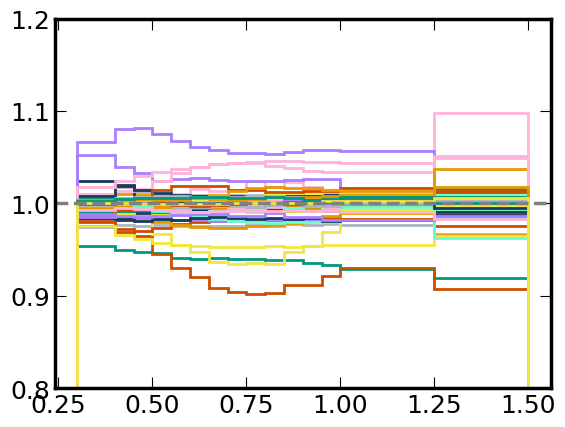

In [288]:
CV = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt])[0]

for i,s in enumerate(xsec_systs_toplot):
    w = Idf[wgt]*Idf["%s_univ" % s]
    v = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=w[Idf[cut]])[0]
    _ = plt.hist(centers, bins=bins, weights=v/CV, histtype="step", linewidth=2)

plt.ylim([0.8, 1.2])
plt.axhline([1], color="gray", linestyle="--")


# add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")

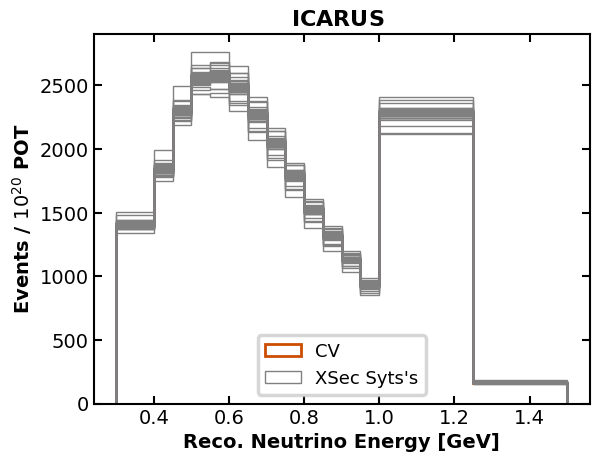

In [289]:
_ = plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt], histtype="step", linewidth=2, label="CV")

for i,s in enumerate(loaddf.xsec_syst):
    w = Idf[wgt]*Idf["%s_univ" % s]
    label = "XSec Syts's" if i == 0 else None
    _ = plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=w[Idf[cut]], histtype="step", linewidth=1, color="gray", label=label)


add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS")

In [290]:
def ratioplot_varyselect(plt, df, selects, names, title, scales=None):
    dfs = []
    for select in selects:
        dfs.append(df[[cut, var, "glob_scale"]].copy())
        dfs[-1][cut] = df[select]

    return ratioplot(plt, dfs, names, title, scales=scales)

def ratioplot(plt, detvars, names, title, presel=None, scales=None):
    fig, (ax_top, ax_bot) = plt.subplots(
      2, 1, sharex=True,
      gridspec_kw={"height_ratios": [3, 1], "hspace": 0},
    )
    
    centers = 0.5 * (bins[1:] + bins[:-1])
    
    cv_vals = None
    for i in range(len(detvars)):
        d = detvars[i]
        c = d[cut]
        if presel is not None:
            c = c & presel(d)
        
        n, _ = np.histogram(d.loc[c, var], bins=bins,
                          weights=d.loc[c, wgt])
        s = scales[i] if scales is not None else 1.
        n = n * s
        _ = ax_top.hist(centers, bins=bins, weights=n, color="tab:gray" if i == 0 else None,
                  histtype="step", linewidth=2, label=names[i])
        if i == 0:
            cv_vals = n
        else:
            ratio = np.divide(n, cv_vals, out=np.ones_like(n, dtype=float),
                            where=cv_vals > 0)
            _ = ax_bot.hist(centers, bins=bins, weights=ratio, 
                      histtype="step", linewidth=2)
    
    _ = ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    
    _ = add_style(ax_top, "", det=title)
    _ = ax_top.set_xlabel("")
    
    _ = ax_bot.set_xlabel("Reco. Neutrino Energy [GeV]", fontsize=FONTSIZE, fontweight="bold")
    _ = ax_bot.set_ylabel("Var. / Nom.", fontsize=FONTSIZE, fontweight="bold")
    _ = ax_bot.tick_params(axis="both", which="both", direction="in",
                     length=6, width=1.5, labelsize=FONTSIZE, top=True, right=True)
    _ = ax_bot.set_ylim([0.95, 1.05])
    for spine in ax_bot.spines.values():
        spine.set_linewidth(1.5)

    return ax_top, ax_bot

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'SBND SCE')

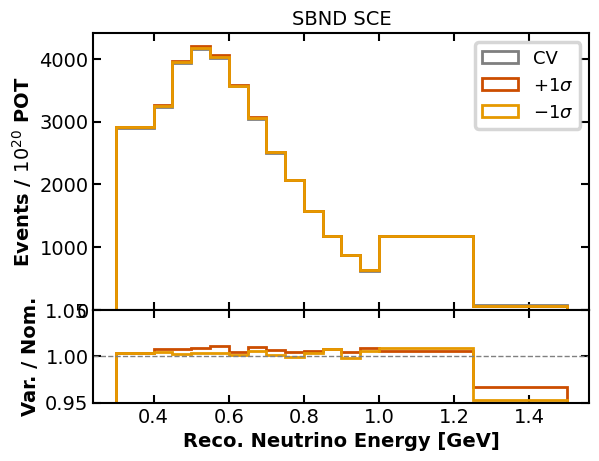

Text(0.5, 1.0, 'SBND WM $X\\theta_{xw}$')

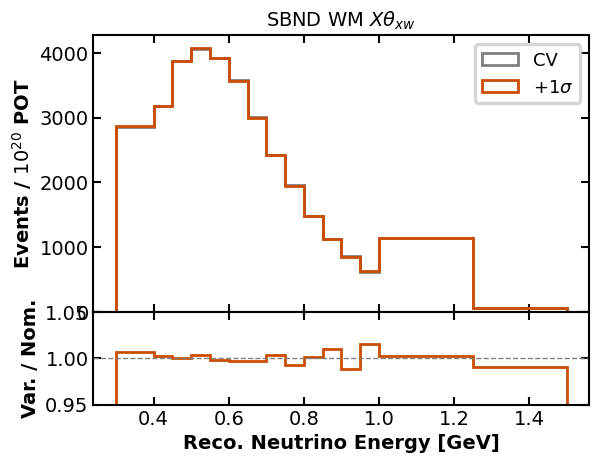

Text(0.5, 1.0, 'SBND WM $YZ$')

<Figure size 640x480 with 0 Axes>

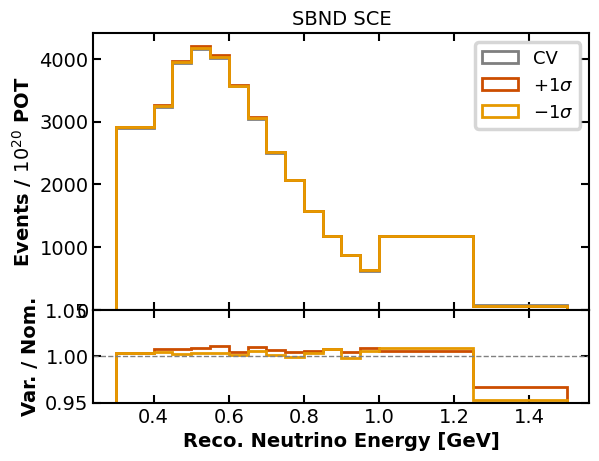

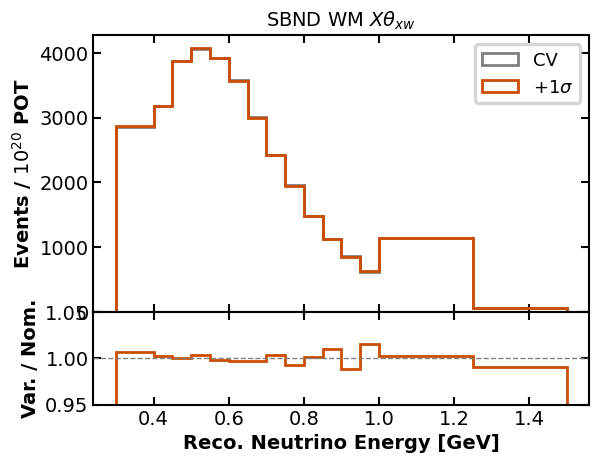

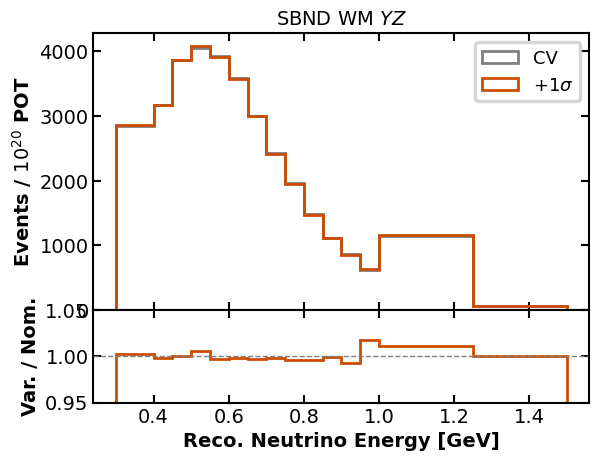

In [291]:
for i, (name, detvar) in enumerate(zip(SDETVAR_NAMES, Sdetvars)):
    varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
    plt.figure(i)
    top, bot = ratioplot(plt, detvar, varnames, "SBND")
    top.set_title("SBND %s" % name, fontsize=14)

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'ICARUS SCE')

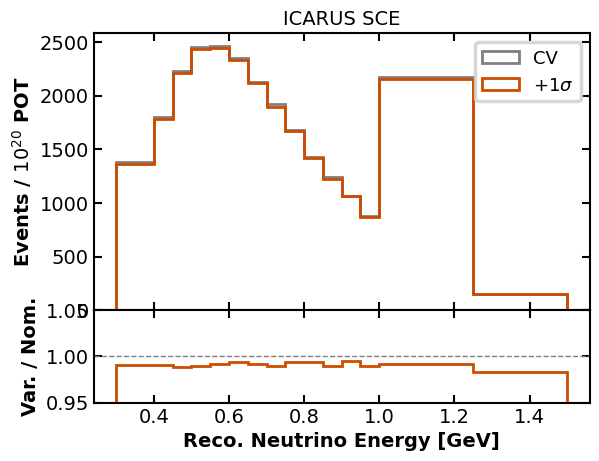

Text(0.5, 1.0, 'ICARUS WM $X\\theta_{xw}$')

<Figure size 640x480 with 0 Axes>

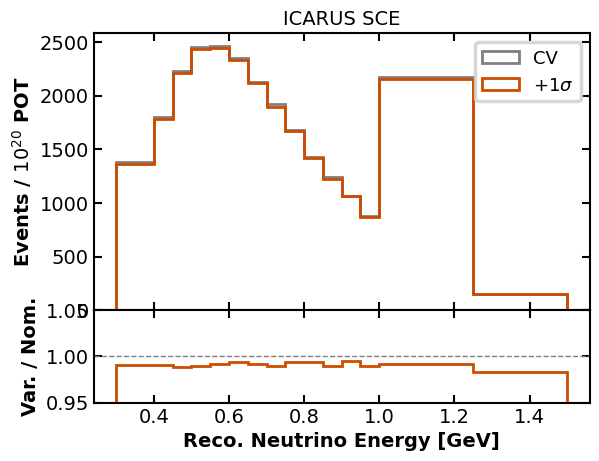

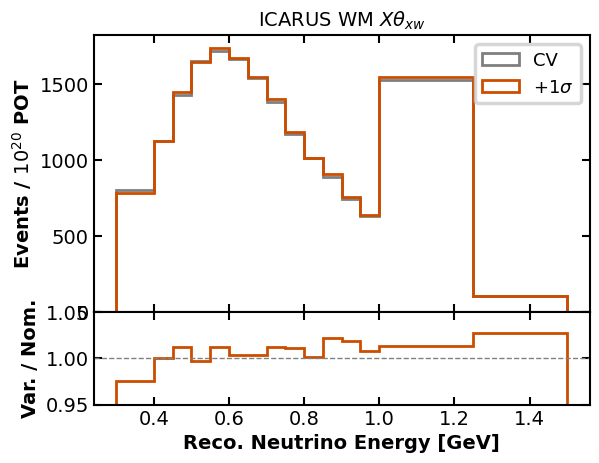

In [292]:
for i, (name, detvar) in enumerate(zip(IDETVAR_NAMES, Idetvars)):
    varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
    plt.figure(i)
    top, bot = ratioplot(plt, detvar, varnames, "ICARUS")
    top.set_title("ICARUS %s" % name, fontsize=14)

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'ICARUS Run2 SCE')

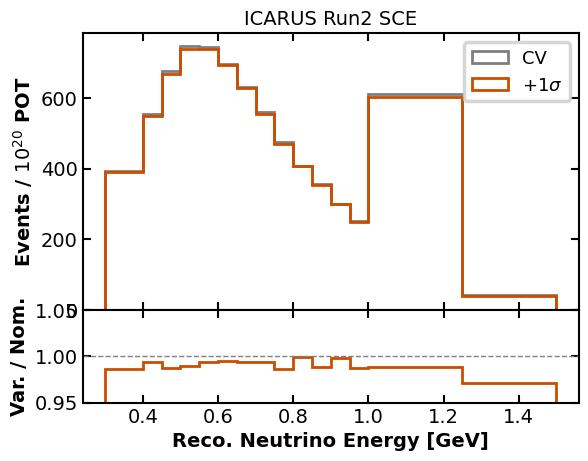

Text(0.5, 1.0, 'ICARUS Run2 WM $X\\theta_{xw}$')

<Figure size 640x480 with 0 Axes>

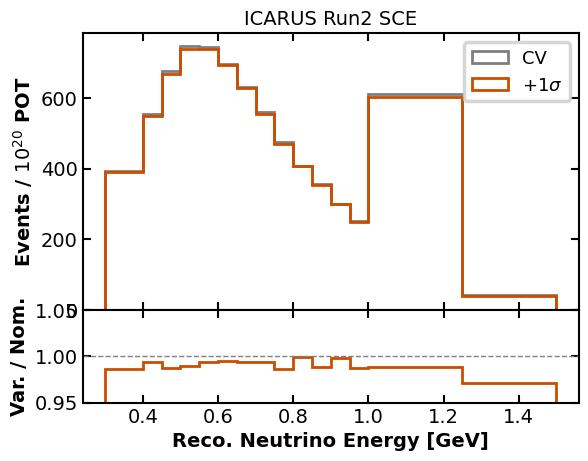

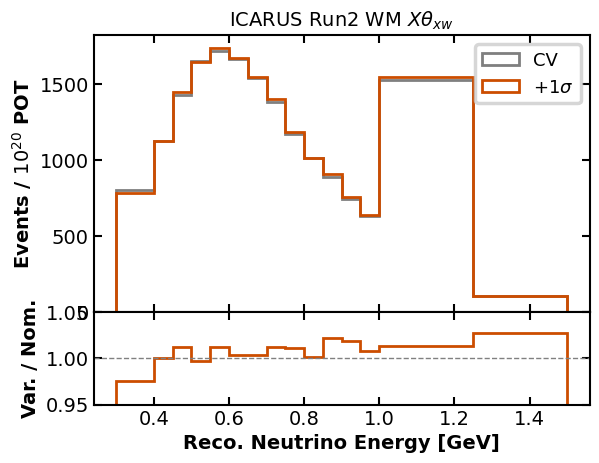

In [293]:
for i, (name, detvar) in enumerate(zip(IDETVAR_NAMES, Idetvars)):
    varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
    plt.figure(i)
    top, bot = ratioplot(plt, [d[d.Run == 2] for d in detvar], varnames, "ICARUS Run2")
    top.set_title("ICARUS Run2 %s" % name, fontsize=14)

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'ICARUS Run4 SCE')

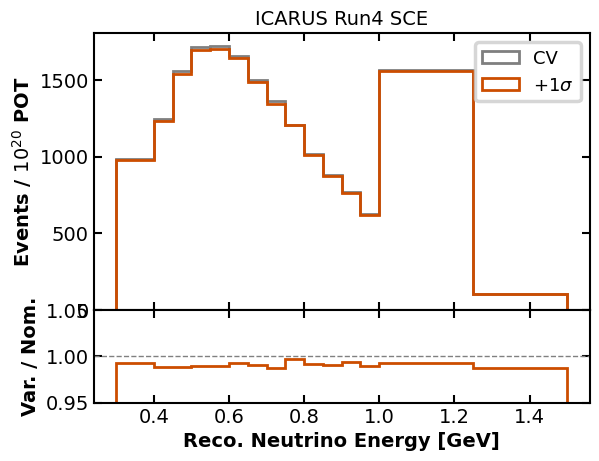

Text(0.5, 1.0, 'ICARUS Run4 WM $X\\theta_{xw}$')

<Figure size 640x480 with 0 Axes>

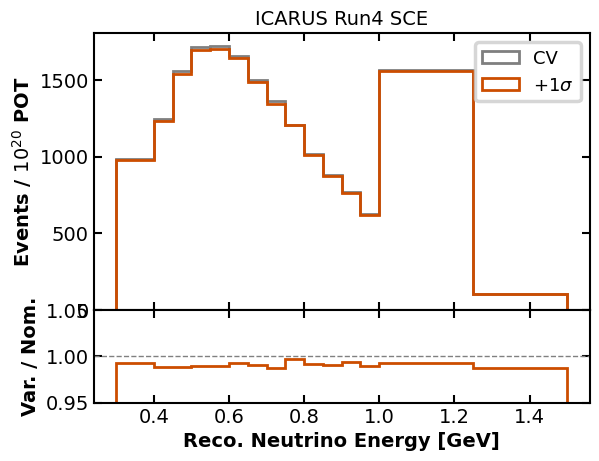

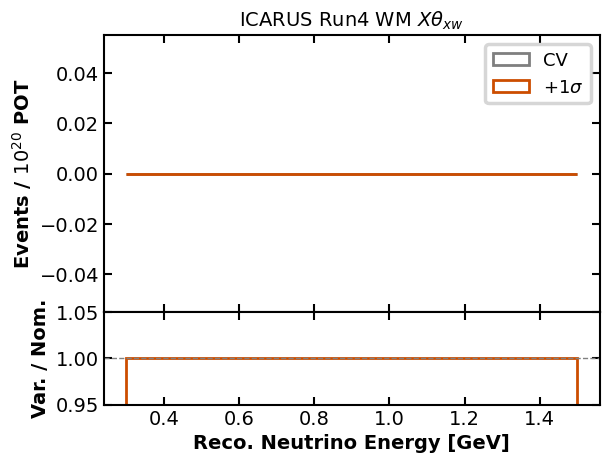

In [294]:
for i, (name, detvar) in enumerate(zip(IDETVAR_NAMES, Idetvars)):
    varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
    plt.figure(i)
    top, bot = ratioplot(plt, [d[d.Run == 4] for d in detvar], varnames, "ICARUS Run4")
    top.set_title("ICARUS Run4 %s" % name, fontsize=14)

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'SBND Trigger')

<Figure size 640x480 with 0 Axes>

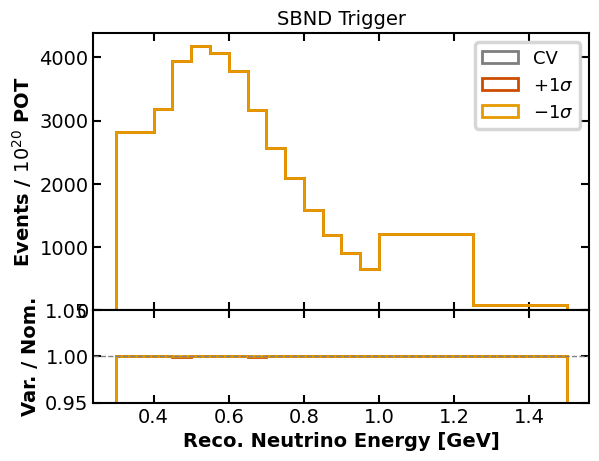

In [295]:
varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
selects = ["selected", "selected_trig_up", "selected_trig_dn"]

plt.figure(i)
top, bot = ratioplot_varyselect(plt, Sdf, selects, varnames, "SBND")
top.set_title("SBND Trigger", fontsize=14)

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'ICARUS Run 2 Trigger')

<Figure size 640x480 with 0 Axes>

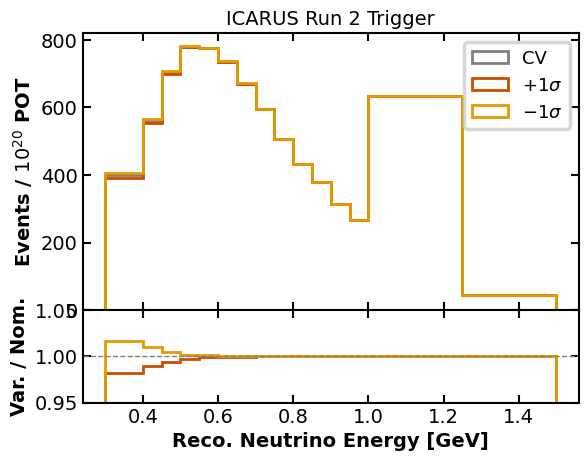

In [296]:
varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
selects = ["selected", "selected_trig_r2_up", "selected_trig_r2_dn"]

plt.figure(i)
top, bot = ratioplot_varyselect(plt, Idf[Idf.Run == 2], selects, varnames, "ICARUS Run2")
top.set_title("ICARUS Run 2 Trigger", fontsize=14)

<Figure size 640x480 with 0 Axes>

Text(0.5, 1.0, 'ICARUS Run 4 Trigger')

<Figure size 640x480 with 0 Axes>

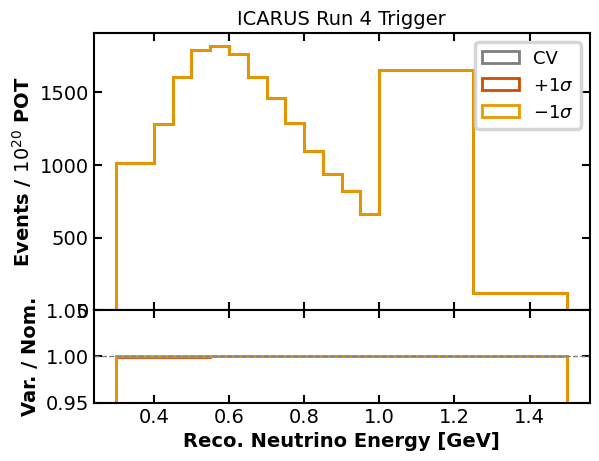

In [297]:
varnames = ["CV", "$+1\\sigma$", "$-1\\sigma$"]
selects = ["selected", "selected_trig_r4_up", "selected_trig_r2_dn"]

plt.figure(i)
top, bot = ratioplot_varyselect(plt, Idf[Idf.Run == 4], selects, varnames, "ICARUS Run4")
top.set_title("ICARUS Run 4 Trigger", fontsize=14)

In [298]:
# for i in range(len(Sdetvars)):
#     _ = plt.hist(Sdetvars[i].loc[Sdetvars[i][cut], var], bins=bins, weights=Sdetvars[i].loc[Sdetvars[i][cut], wgt], 
#             histtype="step", linewidth=2, label=SDETVAR_NAMES[i])

# add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")

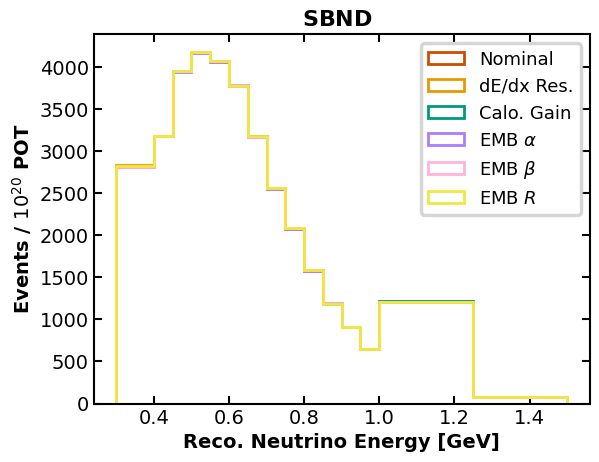

In [299]:
_ = plt.hist(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt], histtype="step", linewidth=2, label="Nominal")

for i in range(len(Schi2_detvars)):
    _ = plt.hist(Schi2_detvars[i].loc[Schi2_detvars[i][cut], var], bins=bins, weights=Schi2_detvars[i].loc[Schi2_detvars[i][cut], wgt], 
            histtype="step", linewidth=2, label=SCHI2_DETVAR_NAMES[i])

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND")

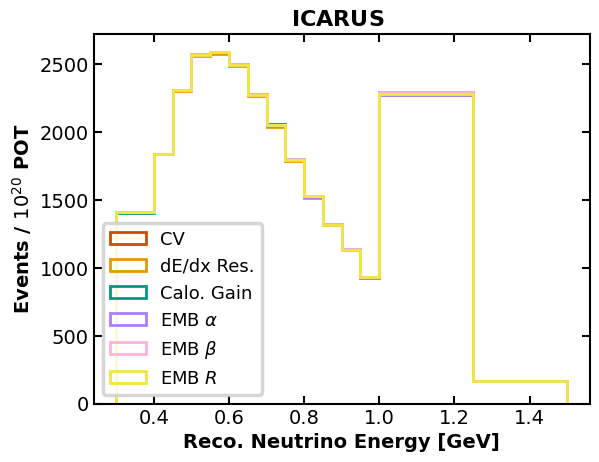

In [300]:
_ = plt.hist(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt], histtype="step", linewidth=2, label="CV")

for i in range(len(Ichi2_detvars)):
    _ = plt.hist(Ichi2_detvars[i].loc[Ichi2_detvars[i][cut], var], bins=bins, weights=Ichi2_detvars[i].loc[Ichi2_detvars[i][cut], wgt], 
            histtype="step", linewidth=2, label=ICHI2_DETVAR_NAMES[i])

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS")

In [301]:
SCV = np.histogram(Sdf.loc[Sdf[cut], var], bins=bins, weights=Sdf.loc[Sdf[cut], wgt])[0]
Scovs = [s.cov(var, cut, bins, SCV) for s in Ssystematics]
Scovs.append(np.diag(SCV))

In [302]:
ICV = np.histogram(Idf.loc[Idf[cut], var], bins=bins, weights=Idf.loc[Idf[cut], wgt])[0]
Icovs = [s.cov(var, cut, bins, ICV) for s in Isystematics]
Icovs.append(np.diag(ICV))

In [303]:
S_detsyst_covs = [s.cov(var, cut, bins, SCV) for s in Ssystematics[labels.index("Detector")].systs]
I_detsyst_covs = [s.cov(var, cut, bins, ICV) for s in Isystematics[labels.index("Detector")].systs]

(0.0, 0.5)

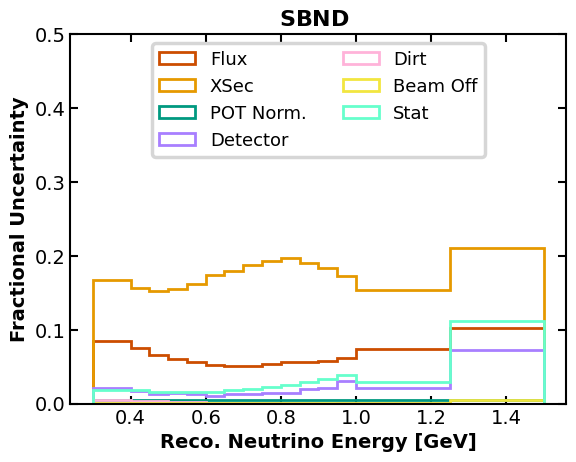

In [304]:
for c, l in zip(Scovs, labels):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2)

plt.ylim([0, 0.5])

# plt.yscale("log")

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/SBND_signalbox_systematics.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/SBND_signalbox_systematics.pdf", bbox_inches="tight")

(0.0, 0.5)

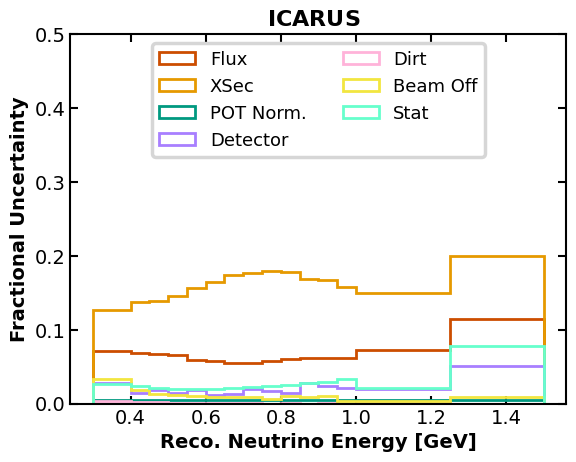

In [305]:
for c, l in zip(Icovs, labels):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2)

plt.ylim([0, 0.5])

# plt.yscale("log")

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ICARUS_signalbox_systematics.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ICARUS_signalbox_systematics.pdf", bbox_inches="tight")

(0.001, 8.0)

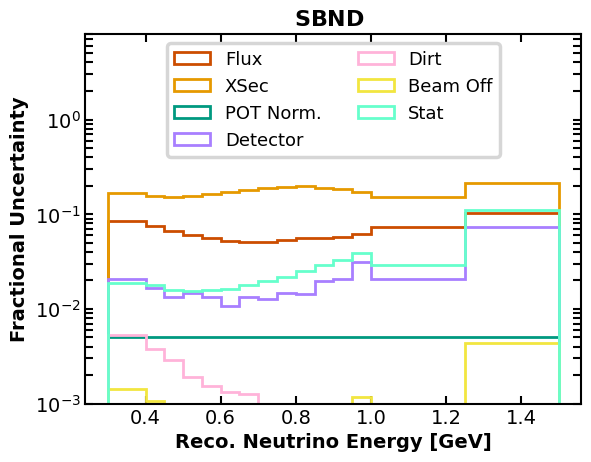

In [306]:
for c, l in zip(Scovs, labels):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2)

plt.ylim([1e-3, 8])

plt.yscale("log")

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/SBND_signalbox_systematics_log.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/SBND_signalbox_systematics_log.pdf", bbox_inches="tight")

In [307]:
len(I_detsyst_covs), len(IDETVAR_NAMES + ICHI2_DETVAR_NAMES)

(10, 7)

(array([0.02853579, 0.02447044, 0.02100919, 0.02149022, 0.02071413,
        0.01952698, 0.02231031, 0.02346256, 0.02633422, 0.02899657,
        0.03502814, 0.03915074, 0.05005572, 0.03538395, 0.13302175]),
 array([0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85,
        0.9 , 0.95, 1.  , 1.25, 1.5 ]),
 [<matplotlib.patches.Polygon at 0x7fb83c2cfdf0>])

(0.0, 0.125)

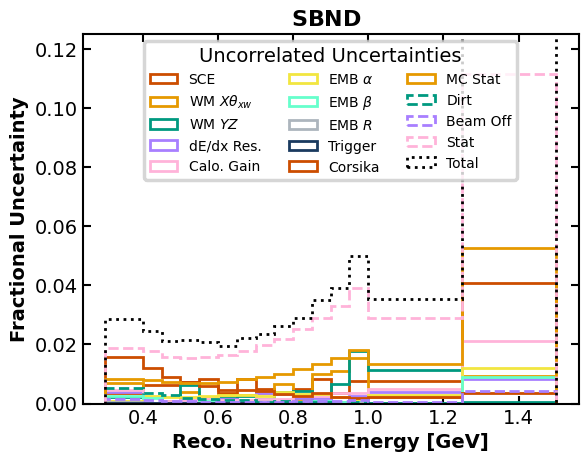

In [308]:
combined = np.zeros(Scovs[0].shape)
for c, l in zip(S_detsyst_covs, SDETVAR_NAMES + SCHI2_DETVAR_NAMES + S_TRIGGER_NAMES + ["Corsika", "MC Stat"]):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2)
    combined += c
    
for c, l in zip(Scovs[4:], labels[4:]):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/SCV), label=l, histtype="step", linewidth=2, linestyle="--")
    combined += c

plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(combined))/SCV), label="Total", histtype="step", color="black", linewidth=2, linestyle=":")

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=3, legend_title="Uncorrelated Uncertainties", legend_fontsize=10)

plt.ylim([0, 0.125])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/SBND_signalbox_systematics_uncorr.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/SBND_signalbox_systematics_uncorr.pdf", bbox_inches="tight")

(array([0.05121118, 0.03280785, 0.03114701, 0.02665975, 0.02850623,
        0.02485486, 0.02612372, 0.03120479, 0.02938748, 0.03082717,
        0.04005649, 0.03950483, 0.03910507, 0.02912559, 0.09334794]),
 array([0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85,
        0.9 , 0.95, 1.  , 1.25, 1.5 ]),
 [<matplotlib.patches.Polygon at 0x7fb84d2a25c0>])

(0.0, 0.125)

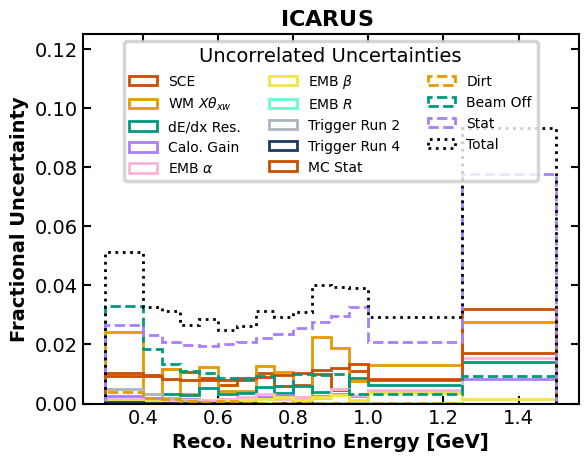

In [309]:
combined = np.zeros(Icovs[0].shape)
for c, l in zip(I_detsyst_covs, IDETVAR_NAMES + ICHI2_DETVAR_NAMES + I_TRIGGER_NAMES + ["MC Stat"]):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2)
    combined += c
    
for c, l in zip(Icovs[4:], labels[4:]):
    _ = plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(c))/ICV), label=l, histtype="step", linewidth=2, linestyle="--")
    combined += c

plt.hist(centers, bins=bins, weights=(np.sqrt(np.diag(combined))/ICV), label="Total", histtype="step", color="black", linewidth=2, linestyle=":")

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=3, legend_title="Uncorrelated Uncertainties", legend_fontsize=10)

plt.ylim([0, 0.125])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ICARUS_signalbox_systematics_uncorr.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ICARUS_signalbox_systematics_uncorr.pdf", bbox_inches="tight")

(0.001, 8.0)

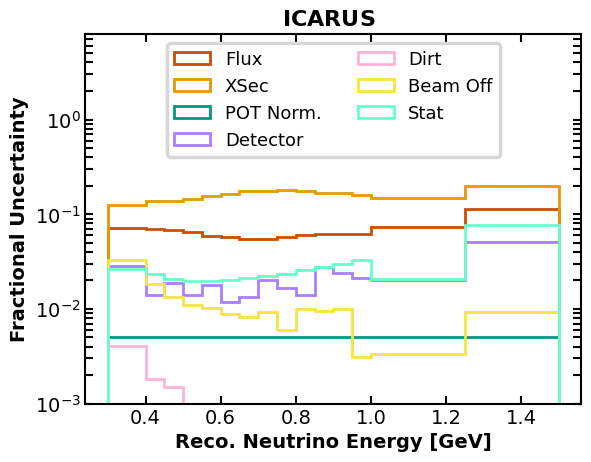

In [310]:
for c, l in zip(Icovs, labels):
    _ = plt.hist(centers[ICV>0], bins=bins, weights=(np.sqrt(np.diag(c))/ICV)[ICV>0], label=l, histtype="step", linewidth=2)

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="ICARUS", ylabel="Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=2)

plt.ylim([1e-3, 8])

plt.yscale("log")

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ICARUS_signalbox_systematics_log.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ICARUS_signalbox_systematics_log.pdf", bbox_inches="tight")

In [311]:
covs = [s.cov(var, cut, bins, np.concatenate((SCV, ICV))) for s in systematics]
covs.append(np.diag(np.concatenate((SCV, ICV))))

In [312]:
def corr_f(cov):
    err = np.sqrt(np.diag(cov))
    err[err==0] = 1
    err_inv = np.diag(1/err)
    return err_inv@cov@err_inv

In [313]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib as mpl

In [314]:
mpl.__version__

'3.10.8'

Text(0, 0.5, 'ICARUS')

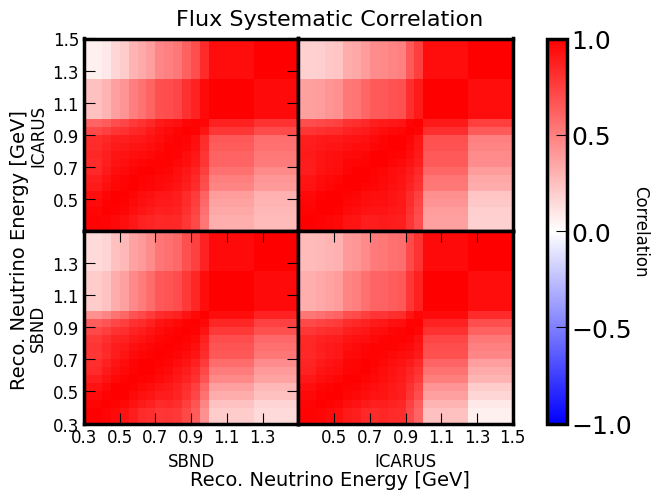

In [315]:
fig, axs = plt.subplots(2, 2, layout='constrained',
    gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
# plt.subplots_adjust(hspace=0, wspace=0)
fig.get_layout_engine().set(w_pad=0 / 72, h_pad=0 / 72, hspace=0,
                            wspace=0)

C = corr_f(covs[0])

nbin = len(bins) - 1
for i, ax in enumerate(axs):
    for j, a in enumerate(ax):
        ic = 1 if i == 0 else 0
        cov = C[nbin*ic:nbin*(ic+1), nbin*j:nbin*(j+1)]
        pcol = a.pcolormesh(bins, bins, cov, cmap="bwr", vmin=-1, vmax=1, linewidth=0, rasterized=True)
        
        a.tick_params(axis='both', which='major', labelsize=FONTSIZE-2)
        if i == 0 and j == 0:
            _ = a.set_xticks([])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[1:])
            a.set_ylabel("ICARUS", size=FONTSIZE-2)
        if i == 0 and j == 1:
            _ = a.set_xticks([])
            _ = a.set_yticks([])
        if i == 1 and j == 0:
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_ylabel("SBND", size=FONTSIZE-2)
            _ = a.set_xlabel("SBND", size=FONTSIZE-2)
        elif i == 1 and j == 1:
            pass
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_yticks([])
            _ = a.set_xlabel("ICARUS", size=FONTSIZE-2)


_ = fig.suptitle("Flux Systematic Correlation", size=FONTSIZE+2) #, x=0.46, y=0.95)
_ = fig.supxlabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)
_ = fig.supylabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)

norm = mcolors.Normalize(vmin=-1, vmax=1)
sm = cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=[a for ax in axs for a in ax])
cbar.set_label("Correlation", rotation=270, size=FONTSIZE-2, labelpad=12)

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/flux_correlation.png")
    plt.savefig(PLOTDIR + "/pdf/flux_correlation.pdf")

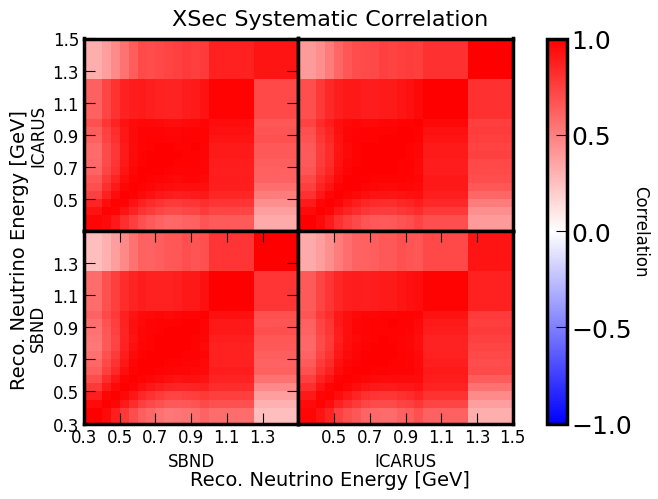

In [316]:
fig, axs = plt.subplots(2, 2, layout='constrained',
    gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
# plt.subplots_adjust(hspace=0, wspace=0)
fig.get_layout_engine().set(w_pad=0 / 72, h_pad=0 / 72, hspace=0,
                            wspace=0)

C = corr_f(covs[1])

nbin = len(bins) - 1
for i, ax in enumerate(axs):
    for j, a in enumerate(ax):
        ic = 1 if i == 0 else 0
        cov = C[nbin*ic:nbin*(ic+1), nbin*j:nbin*(j+1)]
        pcol = a.pcolormesh(bins, bins, cov, cmap="bwr", vmin=-1, vmax=1, linewidth=0, rasterized=True)

        a.tick_params(axis='both', which='major', labelsize=FONTSIZE-2)
        if i == 0 and j == 0:
            _ = a.set_xticks([])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_ylabel("ICARUS", size=FONTSIZE-2)
        if i == 0 and j == 1:
            _ = a.set_xticks([])
            _ = a.set_yticks([])
        if i == 1 and j == 0:
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_ylabel("SBND", size=FONTSIZE-2)
            _ = a.set_xlabel("SBND", size=FONTSIZE-2)
        elif i == 1 and j == 1:
            pass
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_yticks([])
            _ = a.set_xlabel("ICARUS", size=FONTSIZE-2)


_ = fig.suptitle("XSec Systematic Correlation", size=FONTSIZE+2) #, x=0.46, y=0.95)
_ = fig.supxlabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)
_ = fig.supylabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)

norm = mcolors.Normalize(vmin=-1, vmax=1)
sm = cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=[a for ax in axs for a in ax])
cbar.set_label("Correlation", rotation=270, size=FONTSIZE-2, labelpad=12)

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/xsec_correlation.png")
    plt.savefig(PLOTDIR + "/pdf/xsec_correlation.pdf")

Text(0.5, 1.0, 'XSec Systematics')

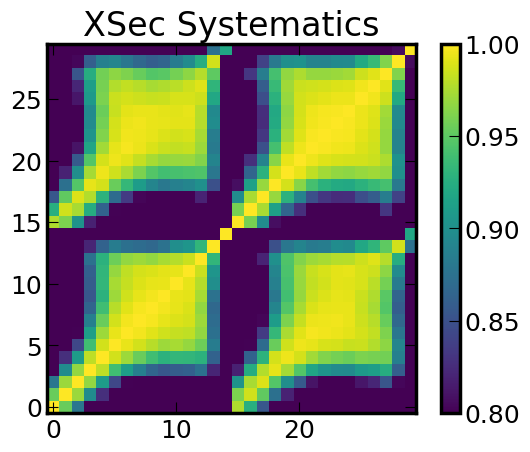

In [317]:
plt.title("XSec Systematics")

plt.imshow(corr_f(covs[1]), origin="lower", vmin=0.8, vmax=1)
plt.colorbar()

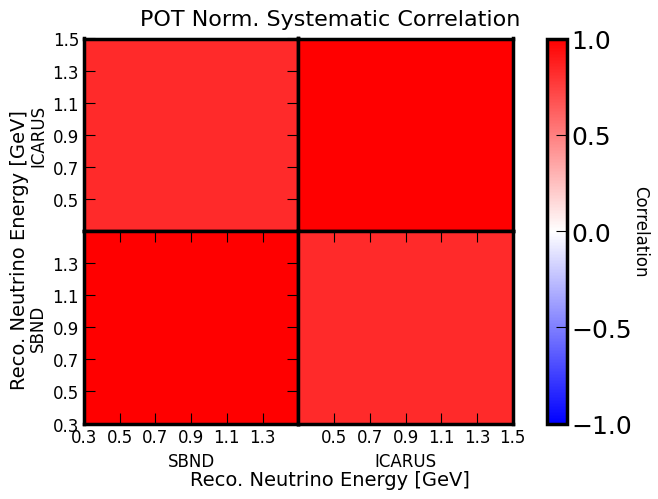

In [318]:
fig, axs = plt.subplots(2, 2, layout='constrained',
    gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
# plt.subplots_adjust(hspace=0, wspace=0)
fig.get_layout_engine().set(w_pad=0 / 72, h_pad=0 / 72, hspace=0,
                            wspace=0)

C = corr_f(covs[2])

nbin = len(bins) - 1
for i, ax in enumerate(axs):
    for j, a in enumerate(ax):
        ic = 1 if i == 0 else 0
        cov = C[nbin*ic:nbin*(ic+1), nbin*j:nbin*(j+1)]
        pcol = a.pcolormesh(bins, bins, cov, cmap="bwr", vmin=-1, vmax=1, linewidth=0, rasterized=True)

        a.tick_params(axis='both', which='major', labelsize=FONTSIZE-2)
        if i == 0 and j == 0:
            _ = a.set_xticks([])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_ylabel("ICARUS", size=FONTSIZE-2)
        if i == 0 and j == 1:
            _ = a.set_xticks([])
            _ = a.set_yticks([])
        if i == 1 and j == 0:
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_ylabel("SBND", size=FONTSIZE-2)
            _ = a.set_xlabel("SBND", size=FONTSIZE-2)
        elif i == 1 and j == 1:
            pass
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_yticks([])
            _ = a.set_xlabel("ICARUS", size=FONTSIZE-2)


_ = fig.suptitle("POT Norm. Systematic Correlation", size=FONTSIZE+2) #, x=0.46, y=0.95)
_ = fig.supxlabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)
_ = fig.supylabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)

norm = mcolors.Normalize(vmin=-1, vmax=1)
sm = cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=[a for ax in axs for a in ax])
cbar.set_label("Correlation", rotation=270, size=FONTSIZE-2, labelpad=12)

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/norm_correlation.png")
    plt.savefig(PLOTDIR + "/pdf/norm_correlation.pdf")

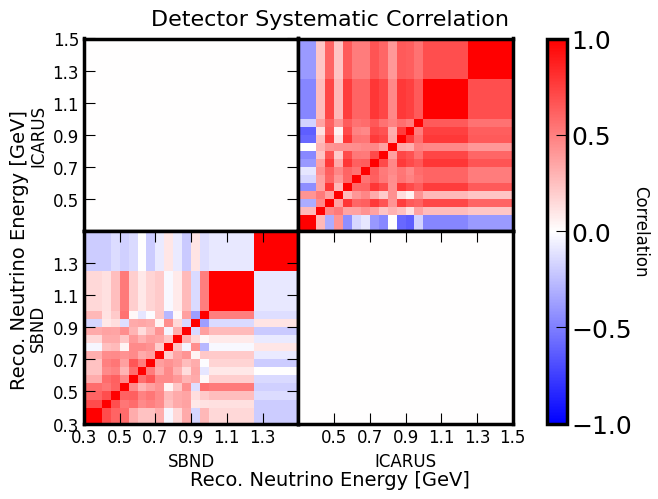

In [319]:
fig, axs = plt.subplots(2, 2, layout='constrained',
    gridspec_kw={'wspace': 0.0, 'hspace': 0.0})
# plt.subplots_adjust(hspace=0, wspace=0)
fig.get_layout_engine().set(w_pad=0 / 72, h_pad=0 / 72, hspace=0,
                            wspace=0)

C = corr_f(covs[3])

nbin = len(bins) - 1
for i, ax in enumerate(axs):
    for j, a in enumerate(ax):
        ic = 1 if i == 0 else 0
        cov = C[nbin*ic:nbin*(ic+1), nbin*j:nbin*(j+1)]
        pcol = a.pcolormesh(bins, bins, cov, cmap="bwr", vmin=-1, vmax=1, linewidth=0, rasterized=True)

        a.tick_params(axis='both', which='major', labelsize=FONTSIZE-2)
        if i == 0 and j == 0:
            _ = a.set_xticks([])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_ylabel("ICARUS", size=FONTSIZE-2)
        if i == 0 and j == 1:
            _ = a.set_xticks([])
            _ = a.set_yticks([])
        if i == 1 and j == 0:
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_yticks(np.linspace(bins[0], bins[-1], 7)[:-1])
            _ = a.set_ylabel("SBND", size=FONTSIZE-2)
            _ = a.set_xlabel("SBND", size=FONTSIZE-2)
        elif i == 1 and j == 1:
            pass
            _ = a.set_xticks(np.linspace(bins[0], bins[-1], 7)[1:])
            _ = a.set_yticks([])
            _ = a.set_xlabel("ICARUS", size=FONTSIZE-2)


_ = fig.suptitle("Detector Systematic Correlation", size=FONTSIZE+2) #, x=0.46, y=0.95)
_ = fig.supxlabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)
_ = fig.supylabel("Reco. Neutrino Energy [GeV]", size=FONTSIZE)

norm = mcolors.Normalize(vmin=-1, vmax=1)
sm = cm.ScalarMappable(cmap="bwr", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=[a for ax in axs for a in ax])
cbar.set_label("Correlation", rotation=270, size=FONTSIZE-2, labelpad=12)

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/detector_correlation.png")
    plt.savefig(PLOTDIR + "/pdf/detector_correlation.pdf")

In [320]:
def ratio_cov_full(x, y, cov):
    """
    Covariance of r = x / y given the full covariance of (x, y).

    Parameters
    ----------
    x, y : array-like, shape (n,)
        Central values
    cov : array-like, shape (2n, 2n)
        Full covariance matrix of (x, y)

        Ordering must be:
        cov = [[Cov(x,x), Cov(x,y)],
               [Cov(y,x), Cov(y,y)]]

    Returns
    -------
    cov_r : ndarray, shape (n, n)
        Covariance matrix of r
    """
    n = len(x)
    assert cov.shape == (2*n, 2*n)

    # Protect against division by zero
    eps = 1e-12
    y_safe = np.where(np.abs(y) < eps, eps, y)

    Dx = np.diag(1.0 / y_safe)
    Dy = np.diag(-x / y_safe**2)

    # Full Jacobian: shape (n, 2n)
    J = np.hstack([Dx, Dy])

    return J @ cov @ J.T

In [321]:
def conditional_constraint_full(cov):
    """
    Conditional (Gaussian) constraint on y given a measurement of x,
    using the full joint covariance of (x, y).

        cov:   Cov(y,y) - Cov(y,x) Cov(x,x)^{-1} Cov(x,y)

    i.e. the standard Schur-complement / near-detector-style conditional
    constraint. The conditional covariance depends only on the covariance
    blocks, not on x, y, or x_obs.

    Parameters
    ----------
    cov : array-like, shape (2n, 2n)
        Full covariance matrix of (x, y).
        Ordering must be:
        cov = [[Cov(x,x), Cov(x,y)],
               [Cov(y,x), Cov(y,y)]]

    Returns
    -------
    cov_cond : ndarray, shape (n, n)
        Conditional (post-constraint) covariance of y.
    """

    cov = np.asarray(cov, dtype=float)
    n = cov.shape[0]//2
    assert cov.shape == (2*n, 2*n)


    # Block decomposition
    Cxx = cov[:n, :n]
    Cxy = cov[:n, n:]
    Cyx = cov[n:, :n]
    Cyy = cov[n:, n:]

    # Gain matrix K = Cyx Cxx^{-1}
    K = Cyx @ np.linalg.inv(Cxx)

    cov_cond = Cyy - K @ Cxy
    cov_cond = 0.5 * (cov_cond + cov_cond.T)  # enforce symmetry vs. roundoff
    return cov_cond

In [322]:
labels = [
    "Flux",
    "XSec",
    "POT Norm.",
    "Detector",
    "Dirt",
    "Beam Off",
    "Stat",
]

In [323]:
len(covs)

7

In [324]:
ratio = SCV / ICV
# ratio = ratio / ratio.mean()

ratio_cov_flux = ratio_cov_full(SCV, ICV, covs[0])
ratio_cov_xsec = ratio_cov_full(SCV, ICV, covs[1])
ratio_cov_norm = ratio_cov_full(SCV, ICV, covs[2])
ratio_cov_det = ratio_cov_full(SCV, ICV, covs[3] + covs[4] + covs[5])
ratio_cov_stat = ratio_cov_full(SCV, ICV, covs[6])
ratio_cov_all = ratio_cov_full(SCV, ICV, np.sum(covs, axis=0))

In [325]:
Sdf.crthit.mean()

np.float64(0.0)

(0.0, 0.2)

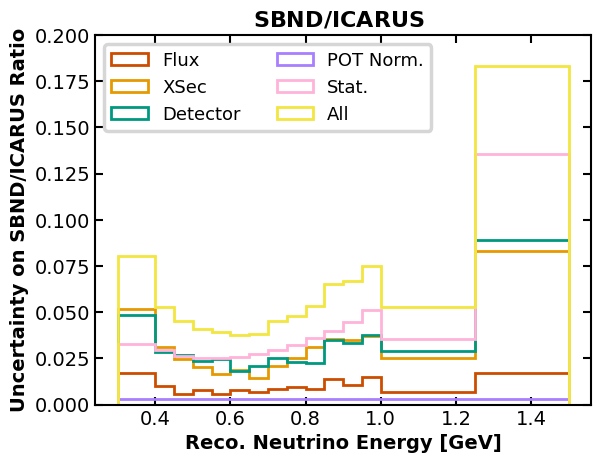

In [326]:
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_flux))/ratio, histtype="step", linewidth=2, label="Flux")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_xsec))/ratio, histtype="step", linewidth=2, label="XSec")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_det))/ratio, histtype="step", linewidth=2, label="Detector")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_norm))/ratio, histtype="step", linewidth=2, label="POT Norm.")
# _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_dirt))/ratio, histtype="step", linewidth=2, label="Dirt")
# _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_beamoff))/ratio, histtype="step", linewidth=2, label="Beam-Off")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_stat))/ratio, histtype="step", linewidth=2, label="Stat.")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_all))/ratio, histtype="step", linewidth=2, label="All")
# plt.ylim([0, 0.25])

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND / ICARUS", 
          ylabel="Uncertainty on SBND/ICARUS Ratio", legend_loc="upper left", legend_ncol=2)

plt.ylim([0, 0.2])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ratio_signalbox_systematics.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ratio_signalbox_systematics.pdf", bbox_inches="tight")

In [327]:
cond_cov_flux = conditional_constraint_full(np.sum(covs, axis=0) - covs[0])
cond_cov_xsec = conditional_constraint_full(np.sum(covs, axis=0) - covs[1])
cond_cov_norm = conditional_constraint_full(np.sum(covs, axis=0) - covs[2])
cond_cov_det = conditional_constraint_full(np.sum(covs, axis=0) - (covs[3] + covs[4] + covs[5]))
cond_cov_stat = conditional_constraint_full(np.sum(covs, axis=0) - covs[6])
cond_cov_all = conditional_constraint_full(np.sum(covs, axis=0))

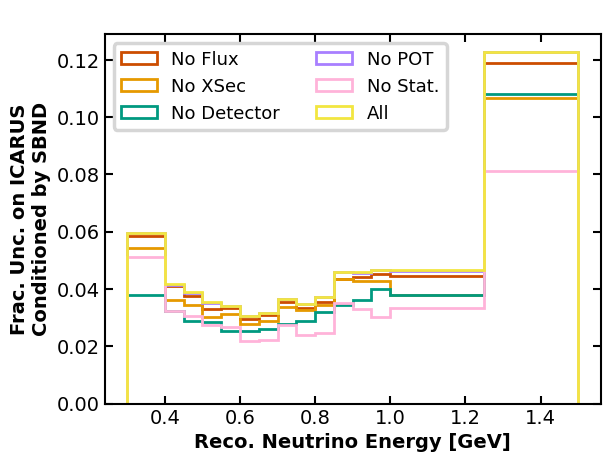

In [328]:
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_flux))/ICV, histtype="step", linewidth=2, label="No Flux")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_xsec))/ICV, histtype="step", linewidth=2, label="No XSec")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_det))/ICV, histtype="step", linewidth=2, label="No Detector")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_norm))/ICV, histtype="step", linewidth=2, label="No POT")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_stat))/ICV, histtype="step", linewidth=2, label="No Stat.")
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_all))/ICV, histtype="step", linewidth=2, label="All")
# plt.ylim([0, 0.25])

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="", 
          ylabel="Frac. Unc. on ICARUS\nConditioned by SBND", legend_loc="upper left", legend_ncol=2)

# plt.ylim([0, 0.15])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/condconstraint_signalbox_systematics.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/condconstraint_signalbox_systematics.pdf", bbox_inches="tight")

/tmp/ipykernel_1892/643021199.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=legend_fontsize, loc=legend_loc, ncol=legend_ncol, title=legend_title, title_fontsize=FONTSIZE)


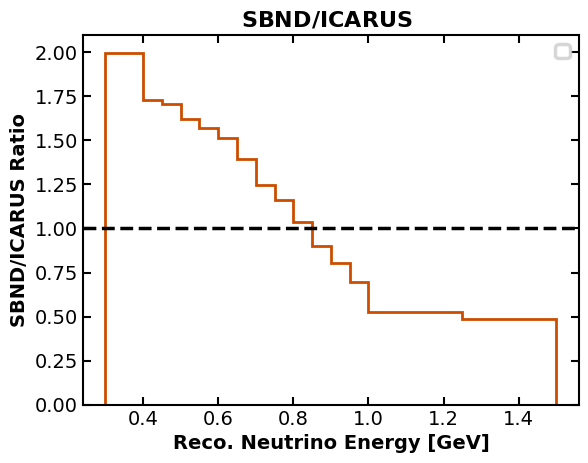

In [329]:
_ = plt.hist(centers, bins=bins, weights=ratio, histtype="step", linewidth=2)
add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND / ICARUS", ylabel="SBND/ICARUS Ratio")
plt.axhline([1], color="black", linestyle="--")

In [330]:
xs = systematics[1]
xsec_unc_ratios = []
xsec_unc_sbnd = []
xsec_unc_icarus = []

for w in xs.systa.wgts:
    s = syst.CorrelatedSystematic(syst.WeightSystematic(Sdf, [w], avg=False), syst.WeightSystematic(Idf, [w], avg=False))
    cov = s.cov(var, cut, bins, np.concatenate((SCV, ICV)))
    ratio_unc = ratio_cov_full(SCV, ICV, cov)
    xsec_unc_ratios.append(np.sqrt(np.diag(ratio_unc))/ratio)
    xsec_unc_sbnd.append(np.sqrt(np.diag(s.systa.cov(var, cut, bins, SCV))) / SCV)
    xsec_unc_icarus.append(np.sqrt(np.diag(s.systb.cov(var, cut, bins, ICV))) / ICV)

In [331]:
xsec_unc_ratios[0].shape

(15,)

In [332]:
np.max(xsec_unc_sbnd, axis=1).shape, np.max(xsec_unc_ratios, axis=1).shape

((87,), (87,))

Text(0, 0.5, 'RMS Uncertainty on SBND/ICARUS')

Text(0.5, 0, 'RMS Uncertainty on SBND')

Text(0.5, 1.0, 'Cross Seciton Uncertainties')

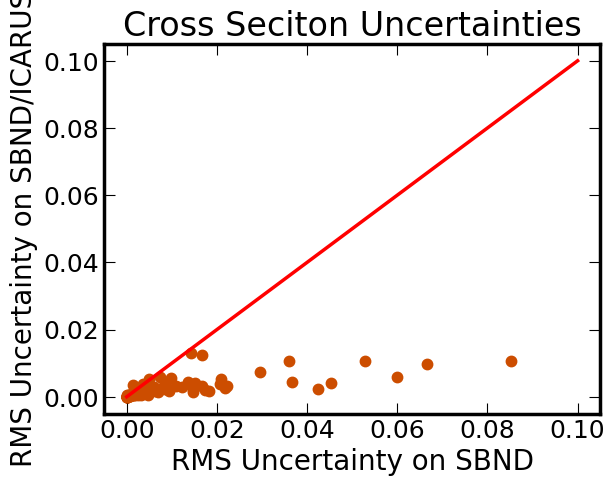

In [333]:
plt.scatter(np.sqrt(np.mean(np.array(xsec_unc_sbnd)**2, axis=1)), np.sqrt(np.mean(np.array(xsec_unc_ratios)**2, axis=1)))
plt.plot([0, 0.1], [0, 0.1], color="red")

plt.ylabel("RMS Uncertainty on SBND/ICARUS")
plt.xlabel("RMS Uncertainty on SBND")
plt.title("Cross Seciton Uncertainties")

In [334]:
def weightname(w):
    w = w.split("_")
    if w[0] == "CCQETemplateReweight":
        return w[3] + " " + w[4]
    elif w[0] == "QEInterference":
        return w[3] + " bin" + w[5]
    elif w[0] == "GENIEReWeight":
        return " ".join(w[3:-1])
    elif w[0] == "ZExpPCAWeighter":
        return "axialFF bin" + w[4][-1] 
    elif w[0] == "MECq0q3InterpWeighting":
        return "MEC %s %s" % (w[3], w[5][-1])
    else:
        print(w)
        assert(False)

In [335]:
ifig = 0

for r, rS, rI, w in zip(xsec_unc_ratios, xsec_unc_sbnd, xsec_unc_icarus, xs.systa.wgts):
    # if np.any(r > 0.03):
    _ = plt.figure(ifig)
    _ = plt.hist(centers, bins=bins, weights=rS, histtype="step", linewidth=2, label="SBND")
    _ = plt.hist(centers, bins=bins, weights=rI, histtype="step", linewidth=2, label="ICAURS")
    _ = plt.hist(centers, bins=bins, weights=r, histtype="step", linewidth=2, label="Ratio")

    _ = plt.legend()
    _ = plt.title(w)

    ifig += 1
    add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det=weightname(w), 
      ylabel="Frac. Unc. on ICARUS\nConditioned by SBND")
    plt.savefig(PLOTDIR + f"/png/{w}_condconstraint_signalbox_systematics.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + f"/pdf/{w}_condconstraint_signalbox_systematics.pdf", bbox_inches="tight")
    plt.clf()

/tmp/ipykernel_1892/2634269877.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _ = plt.figure(ifig)


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [336]:
xsec_unc_constraint = []
xsec_unc_single_constraint = []

for w in xs.systa.wgts:
    s = syst.CorrelatedSystematic(syst.WeightSystematic(Sdf, [w], avg=False), syst.WeightSystematic(Idf, [w], avg=False))
    cov = s.cov(var, cut, bins, np.concatenate((SCV, ICV)))
    constraint = conditional_constraint_full(np.sum(covs, axis=0) - cov)
    xsec_unc_constraint.append(constraint)
    xsec_unc_single_constraint.append(conditional_constraint_full(cov + covs[5]))

stat_unc_constraint = conditional_constraint_full(covs[5])

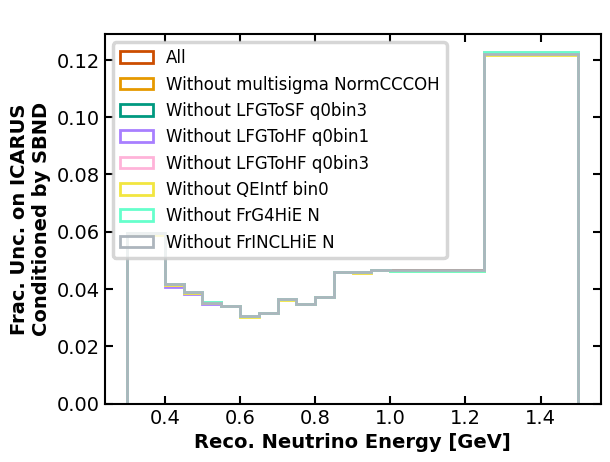

In [337]:
_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(cond_cov_all))/ICV, histtype="step", linewidth=2, label="All")

for w,c,r in zip(xs.systa.wgts, xsec_unc_constraint, xsec_unc_ratios):
    if np.any(r > 0.02):
        _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(c))/ICV, histtype="step", linewidth=2, label="Without %s" % weightname(w))

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="", 
          ylabel="Frac. Unc. on ICARUS\nConditioned by SBND", legend_loc="upper left", legend_ncol=1, legend_fontsize=12)

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/xsec_cond_breakdown.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/xsec_cond_breakdown.pdf", bbox_inches="tight")

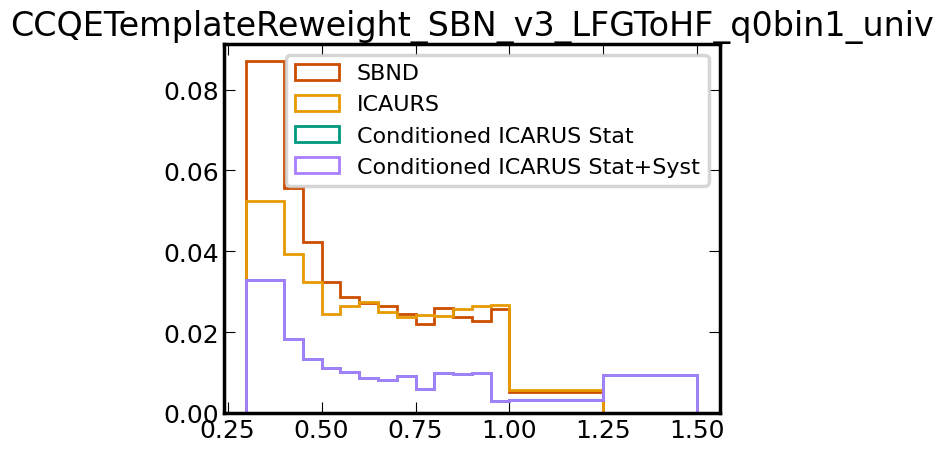

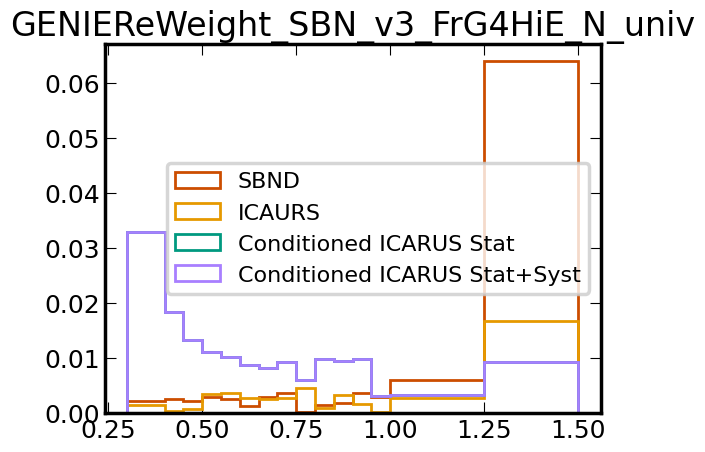

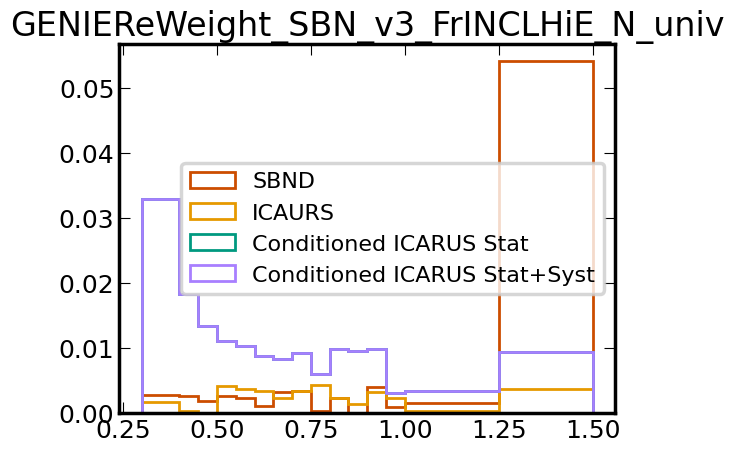

In [338]:
ifig = 0

for r, sc, rS, rI, w in zip(xsec_unc_ratios, xsec_unc_single_constraint, xsec_unc_sbnd, xsec_unc_icarus, xs.systa.wgts):
    if np.any(r > 0.03):
        _ = plt.figure(ifig)
        _ = plt.hist(centers, bins=bins, weights=rS, histtype="step", linewidth=2, label="SBND")
        _ = plt.hist(centers, bins=bins, weights=rI, histtype="step", linewidth=2, label="ICAURS")
        _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(stat_unc_constraint))/ICV, histtype="step", linewidth=2, label="Conditioned ICARUS Stat")
        _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(sc))/ICV, histtype="step", linewidth=2, label="Conditioned ICARUS Stat+Syst")

        _ = plt.legend()
        _ = plt.title(w)

        ifig += 1

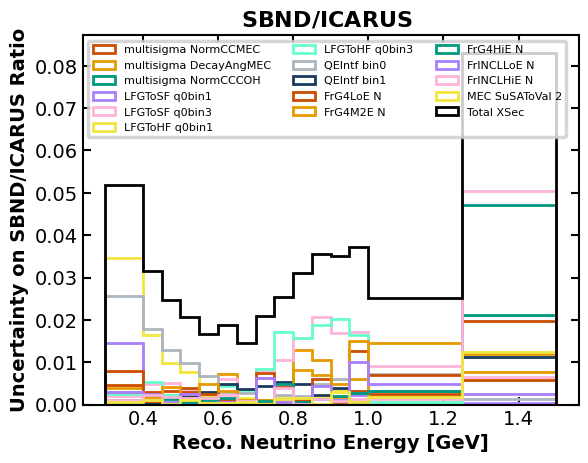

In [339]:
for r,w in zip(xsec_unc_ratios, xs.systa.wgts):
    
    if np.any(r > 0.01):
        _ = plt.hist(centers, bins=bins, weights=r, histtype="step", linewidth=2, label=weightname(w))

_ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_xsec))/ratio, histtype="step", linewidth=2, label="Total XSec", color="black")

add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det="SBND / ICARUS", 
          ylabel="Uncertainty on SBND/ICARUS Ratio", legend_loc="upper left", legend_ncol=3, legend_fontsize=8)

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/xsec_breakdown.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/xsec_breakdown.pdf", bbox_inches="tight")

In [340]:
xsec_syst_names = [
    # CCQE
    "GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape",
    'GENIEReWeight_SBN_v1_multisigma_CoulombCCQE',

    # MEC
    'GENIEReWeight_SBN_v1_multisigma_NormCCMEC',
    'GENIEReWeight_SBN_v1_multisigma_NormNCMEC',
    "GENIEReWeight_SBN_v1_multisigma_DecayAngMEC",

    # RES
    "GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi",
    "GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad",
    "GENIEReWeight_SBN_v1_multisigma_MaCCRES",
    "GENIEReWeight_SBN_v1_multisigma_MaNCRES",
    "GENIEReWeight_SBN_v1_multisigma_MvCCRES",
    "GENIEReWeight_SBN_v1_multisigma_MvNCRES",
    "GENIEReWeight_SBN_v1_multisigma_RDecBR1gamma",
    "GENIEReWeight_SBN_v1_multisigma_RDecBR1eta",

    # Non-Res
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvpCC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvpNC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvpNC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvnCC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvnCC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvnNC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpCC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpCC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarpNC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarnCC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarnCC2pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarnNC1pi',
    'GENIEReWeight_SBN_v1_multisim_NonRESBGvbarnNC2pi',

    # DIS
    # "GENIEReWeight_SBN_v1_multisim_DISBYVariationResponse",
    'GENIEReWeight_SBN_v1_multisigma_AhtBY',
    'GENIEReWeight_SBN_v1_multisigma_BhtBY',
    'GENIEReWeight_SBN_v1_multisigma_CV1uBY',
    'GENIEReWeight_SBN_v1_multisigma_CV2uBY',

    # COH
    "GENIEReWeight_SBN_v1_multisigma_NormCCCOH",
    "GENIEReWeight_SBN_v1_multisigma_NormNCCOH",

    # FSI
    'GENIEReWeight_SBN_v1_multisigma_MFP_pi',
    'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi',
    'GENIEReWeight_SBN_v1_multisigma_FrInel_pi',
    'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
    'GENIEReWeight_SBN_v1_multisigma_FrPiProd_pi',

    # NCEL
    'GENIEReWeight_SBN_v1_multisigma_MaNCEL',
    'GENIEReWeight_SBN_v1_multisigma_EtaNCEL',

    # Systematics introduced by Ar23+
    "CCQETemplateReweight_SBN_v3_LFGToSF_q0bin0",
    "CCQETemplateReweight_SBN_v3_LFGToSF_q0bin1",
    "CCQETemplateReweight_SBN_v3_LFGToSF_q0bin2",
    "CCQETemplateReweight_SBN_v3_LFGToSF_q0bin3",
    "CCQETemplateReweight_SBN_v3_LFGToSF_q0bin4",

    "CCQETemplateReweight_SBN_v3_LFGToHF_q0bin0",
    "CCQETemplateReweight_SBN_v3_LFGToHF_q0bin1",
    "CCQETemplateReweight_SBN_v3_LFGToHF_q0bin2",
    "CCQETemplateReweight_SBN_v3_LFGToHF_q0bin3",
    "CCQETemplateReweight_SBN_v3_LFGToHF_q0bin4",

    "CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin0",
    "CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin1",
    "CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin2",
    "CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin3",
    "CCQETemplateReweight_SBN_v3_HFToCRPA_q0bin4",

    "QEInterference_SBN_v3_QEIntf_dial_0",
    "QEInterference_SBN_v3_QEIntf_dial_1",
    "QEInterference_SBN_v3_QEIntf_dial_2",
    "QEInterference_SBN_v3_QEIntf_dial_3",
    "QEInterference_SBN_v3_QEIntf_dial_4",
    "QEInterference_SBN_v3_QEIntf_dial_5",

    "GENIEReWeight_SBN_v3_FrG4LoE_N",
    "GENIEReWeight_SBN_v3_FrG4M1E_N",
    "GENIEReWeight_SBN_v3_FrG4M2E_N",
    "GENIEReWeight_SBN_v3_FrG4HiE_N",
    "GENIEReWeight_SBN_v3_FrINCLLoE_N",
    "GENIEReWeight_SBN_v3_FrINCLM1E_N",
    "GENIEReWeight_SBN_v3_FrINCLM2E_N",
    "GENIEReWeight_SBN_v3_FrINCLHiE_N",
    "GENIEReWeight_SBN_v3_MFPLoE_N",
    "GENIEReWeight_SBN_v3_MFPM1E_N",
    "GENIEReWeight_SBN_v3_MFPM2E_N",
    "GENIEReWeight_SBN_v3_MFPHiE_N",

    "ZExpPCAWeighter_SBN_v3_MvA_b1",
    "ZExpPCAWeighter_SBN_v3_MvA_b2",
    "ZExpPCAWeighter_SBN_v3_MvA_b3",
    "ZExpPCAWeighter_SBN_v3_MvA_b4",

    "MECq0q3InterpWeighting_SBN_v3_SuSAToVal_MECResponse_q0bin0",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToVal_MECResponse_q0bin1",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToVal_MECResponse_q0bin2",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToVal_MECResponse_q0bin3",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToMar_MECResponse_q0bin0",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToMar_MECResponse_q0bin1",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToMar_MECResponse_q0bin2",
    "MECq0q3InterpWeighting_SBN_v3_SuSAToMar_MECResponse_q0bin3",
]

In [370]:
key_words = [
    "LFGToSF", "LFGToHF", "HFToCRPA", "QEIntf", 
    ["Fr", "MFP"], "axialFF", 
    "MEC", ["CRES", "Delta2N", "RDecBR1"], "NonRES", 
    ["tBY", "uBY"], "CCOH", "NCEL", "CCQE", 
]

tot = 0

all_syst_list = []

for kw in key_words:
    # 1. Standardize kw to always be a list of strings
    kw_list = kw if isinstance(kw, list) else [kw]
    # Start a fresh figure for each category
    plt.figure()
    plotted_any = False

    for r, w in zip(xsec_unc_ratios, xs.systa.wgts):
        w_name = weightname(w)
        # 2. Match full keyword strings instead of characters
        if any(k in w_name for k in kw_list):
            tot += 1
            all_syst_list.append(w_name)
            _ = plt.hist(centers, bins=bins, weights=r, histtype="step", linewidth=2, label=w_name)
            plotted_any = True

    # Only format and save if at least one weight matched
    if plotted_any:
        # Optional: total cross-section overlay
        # plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(ratio_cov_xsec))/ratio, 
        #          histtype="step", linewidth=2, label="Total XSec", color="black")
        
        add_style(
            plt.gca(), 
            "Reco. Neutrino Energy [GeV]", 
            det="SBND / ICARUS", 
            ylabel="Uncertainty on SBND/ICARUS Ratio", 
            legend_loc="upper left", 
            legend_ncol=2, 
            legend_fontsize=8
        )

        if DOSAVE:
            sv = "_".join(kw_list)  # Joins list items with '_' for clean filenames
            plt.savefig(f"{PLOTDIR}/png/{sv}_single_xsec_breakdown.png", bbox_inches="tight")
            plt.savefig(f"{PLOTDIR}/pdf/{sv}_single_xsec_breakdown.pdf", bbox_inches="tight")
    plt.close()
print("total len: ", tot)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

total len:  87


In [167]:
for w in xs.systa.wgts:
    if "CCQETemplate" in w or "QEInt" in w:
        Sdf[w + "_clipped"] = np.clip(Sdf[w], 0, 3)
        Idf[w + "_clipped"] = np.clip(Idf[w], 0, 3)

In [168]:
xs = systematics[1]
xsec_unc_ratios_clipped = []

for w in xs.systa.wgts:
    if "CCQETemplate" in w or "QEInt" in w:
        s = syst.CorrelatedSystematic(syst.WeightSystematic(Sdf, [w + "_clipped"], avg=False), syst.WeightSystematic(Idf, [w + "_clipped"], avg=False))
        cov = s.cov(var, cut, bins, np.concatenate((SCV, ICV)))
        ratio_unc = ratio_cov_full(SCV, ICV, cov)
        xsec_unc_ratios_clipped.append(ratio_unc)

/tmp/ipykernel_1892/643021199.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=legend_fontsize, loc=legend_loc, ncol=legend_ncol, title=legend_title, title_fontsize=FONTSIZE)


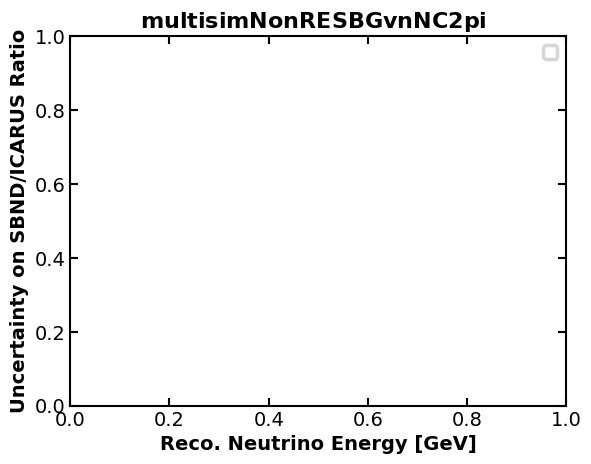

In [169]:
ifig = 0
for r,w in zip(xsec_unc_ratios_clipped, xs.systa.wgts):
    
    if "CCQETemplate" in w or "QEInt" in w:
        _ = plt.figure(ifig)
        _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(r))/ratio, histtype="step", linewidth=2, label="Clipped 10")
        _ = plt.hist(centers, bins=bins, weights=np.sqrt(np.diag(xsec_unc_ratios_clipped[ifig]))/ratio, histtype="step", linewidth=2, label="Clipped 3")

        _ = plt.title(w)
        _ = plt.legend()
    ifig += 1
    add_style(plt.gca(), "Reco. Neutrino Energy [GeV]", det=weightname(w), 
          ylabel="Uncertainty on SBND/ICARUS Ratio")

In [170]:
reco_bins = bins
true_bins = np.array([-2] + list(reco_bins) + [np.inf])
true_bins_centers = (true_bins[:-1] + true_bins[1:])/2
true_bins_centers, true_bins

(array([-0.85 ,  0.35 ,  0.425,  0.475,  0.525,  0.575,  0.625,  0.675,
         0.725,  0.775,  0.825,  0.875,  0.925,  0.975,  1.125,  1.375,
           inf]),
 array([-2.  ,  0.3 ,  0.4 ,  0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,
         0.75,  0.8 ,  0.85,  0.9 ,  0.95,  1.  ,  1.25,  1.5 ,   inf]))

In [171]:
SCV2 = np.histogramdd([Sdf.loc[Sdf[cut], "nu_E_calo"], Sdf.loc[Sdf[cut], "true_E"]], 
                      bins=[reco_bins, true_bins], weights=Sdf.loc[Sdf[cut], wgt])[0]

ICV2 = np.histogramdd([Idf.loc[Idf[cut], "nu_E_calo"], Idf.loc[Idf[cut], "true_E"]], 
                      bins=[reco_bins, true_bins], weights=Idf.loc[Idf[cut], wgt])[0]

SCVT = np.histogram(Sdf.loc[Sdf[cut], "true_E"], bins=true_bins, weights=Sdf.loc[Sdf[cut], wgt])[0]
ICVT = np.histogram(Idf.loc[Idf[cut], "true_E"], bins=true_bins, weights=Idf.loc[Idf[cut], wgt])[0]

# CV2D = np.concatenate((SCV2.T, ICV2.T), axis=0) # .flatten()
# CV2D = np.concatenate((CV2D, CV2D), axis=1)

Imig = ICV2.T / ICV2.sum(axis=1)
Smig = SCV2.T / SCV2.sum(axis=1)

migration = np.block([
    [Smig, np.zeros(Smig.shape)],
    [np.zeros(Imig.shape), Imig]
])

def unfold(C):
    return migration@C@migration.T

def unfoldSBND(C):
    return Smig@C@Smig.T

def unfoldICARUS(C):
    return Imig@C@Imig.T

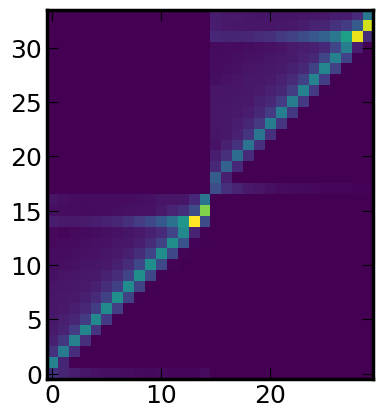

In [172]:
plt.imshow(migration, origin="lower")

In [173]:
ratioT = SCVT / ICVT
ratioT = ratioT / ratioT.mean()

ratioT_cov_flux = ratio_cov_full(SCVT, ICVT, unfold(covs[0]))
ratioT_cov_xsec = ratio_cov_full(SCVT, ICVT, unfold(covs[1]))
ratioT_cov_norm = ratio_cov_full(SCVT, ICVT, unfold(covs[2]))
ratioT_cov_det = ratio_cov_full(SCVT, ICVT, unfold(covs[3] + covs[4] + covs[5]))
ratioT_cov_stat = ratio_cov_full(SCVT, ICVT, unfold(covs[6]))
ratioT_cov_all = ratio_cov_full(SCVT, ICVT, unfold(np.sum(covs, axis=0)))

(0.0, 0.15)

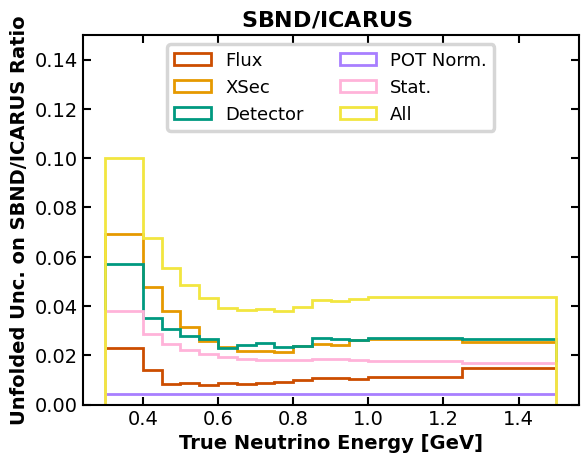

In [174]:
plot_bins = true_bins[1:-1]

_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(ratioT_cov_flux))/ratioT)[1:-1],
             histtype="step", linewidth=2, label="Flux")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(ratioT_cov_xsec))/ratioT)[1:-1],
             histtype="step", linewidth=2, label="XSec")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(ratioT_cov_det))/ratioT)[1:-1],
             histtype="step", linewidth=2, label="Detector")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(ratioT_cov_norm))/ratioT)[1:-1],
             histtype="step", linewidth=2, label="POT Norm.")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(ratioT_cov_stat))/ratioT)[1:-1],
             histtype="step", linewidth=2, label="Stat.")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(ratioT_cov_all))/ratioT)[1:-1],
             histtype="step", linewidth=2, label="All")
# plt.ylim([0, 0.25])

add_style(plt.gca(), "True Neutrino Energy [GeV]", det="SBND / ICARUS", 
          ylabel="Unfolded Unc. on SBND/ICARUS Ratio", legend_loc="upper center", legend_ncol=2)

plt.ylim([0, 0.15])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ratio_signalbox_systematics_trueE.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ratio_signalbox_systematics_trueE.pdf", bbox_inches="tight")

(array([0.0384917 , 0.02328425, 0.02036296, 0.01800977, 0.01738557,
        0.01539807, 0.01555684, 0.0164877 , 0.01539344, 0.01555285,
        0.01789782, 0.01776475, 0.01712865, 0.01729752, 0.01737034]),
 array([0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85,
        0.9 , 0.95, 1.  , 1.25, 1.5 ]),
 [<matplotlib.patches.Polygon at 0x7fb8a93a7c40>])

(0.0, 0.08)

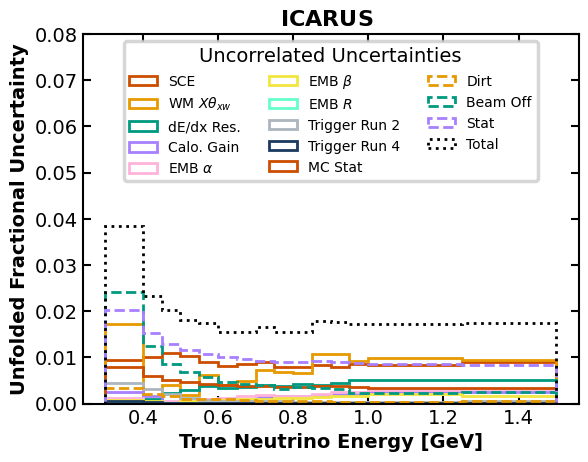

In [175]:
combined = np.zeros(Icovs[0].shape)
for c, l in zip(I_detsyst_covs, IDETVAR_NAMES + ICHI2_DETVAR_NAMES + I_TRIGGER_NAMES + ["MC Stat"]):
    _ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(c)))/ICVT)[1:-1], label=l, histtype="step", linewidth=2)
    combined += c
    
for c, l in zip(Icovs[4:], labels[4:]):
    _ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(c)))/ICVT)[1:-1], label=l, 
                 histtype="step", linewidth=2, linestyle="--")
    combined += c

plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(combined)))/ICVT)[1:-1], label="Total", 
         histtype="step", color="black", linewidth=2, linestyle=":")

add_style(plt.gca(), "True Neutrino Energy [GeV]", det="ICARUS", ylabel="Unfolded Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=3, legend_title="Uncorrelated Uncertainties", legend_fontsize=10)

plt.ylim([0, 0.08])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/ICARUS_signalbox_systematics_trueE_uncorr.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/ICARUS_signalbox_systematics_trueE_uncorr.pdf", bbox_inches="tight")

(array([0.02467018, 0.01921597, 0.01649308, 0.01544064, 0.01394878,
        0.01283723, 0.01294242, 0.0122937 , 0.01217041, 0.01232499,
        0.01255544, 0.01227623, 0.01277025, 0.01280584, 0.01211408]),
 array([0.3 , 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85,
        0.9 , 0.95, 1.  , 1.25, 1.5 ]),
 [<matplotlib.patches.Polygon at 0x7fb8b0240700>])

(0.0, 0.08)

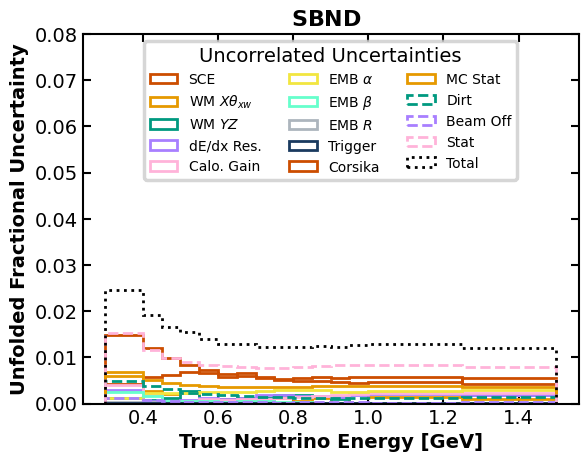

In [176]:
combined = np.zeros(Scovs[0].shape)
for c, l in zip(S_detsyst_covs, SDETVAR_NAMES + SCHI2_DETVAR_NAMES + S_TRIGGER_NAMES+ ["Corsika", "MC Stat"]):
    _ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldSBND(c)))/SCVT)[1:-1], label=l, histtype="step", linewidth=2)
    combined += c
    
for c, l in zip(Scovs[4:], labels[4:]):
    _ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldSBND(c)))/SCVT)[1:-1], 
                 label=l, histtype="step", linewidth=2, linestyle="--")
    combined += c

plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldSBND(combined)))/SCVT)[1:-1], label="Total", 
         histtype="step", color="black", linewidth=2, linestyle=":")

add_style(plt.gca(), "True Neutrino Energy [GeV]", det="SBND", ylabel="Unfolded Fractional Uncertainty", 
          legend_loc="upper center", legend_ncol=3, legend_title="Uncorrelated Uncertainties", legend_fontsize=10)

plt.ylim([0, 0.08])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/SBND_signalbox_systematics_trueE_uncorr.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/SBND_signalbox_systematics_trueE_uncorr.pdf", bbox_inches="tight")

(0.0, 0.075)

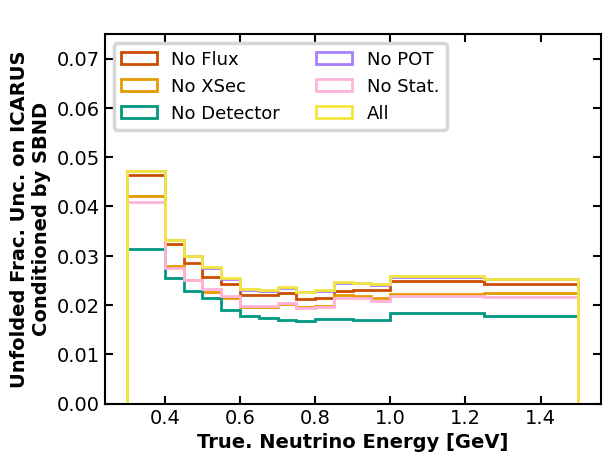

In [177]:
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(cond_cov_flux)))/ICVT)[1:-1], histtype="step", linewidth=2, label="No Flux")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(cond_cov_xsec)))/ICVT)[1:-1], histtype="step", linewidth=2, label="No XSec")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(cond_cov_det)))/ICVT)[1:-1], histtype="step", linewidth=2, label="No Detector")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(cond_cov_norm)))/ICVT)[1:-1], histtype="step", linewidth=2, label="No POT")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(cond_cov_stat)))/ICVT)[1:-1], histtype="step", linewidth=2, label="No Stat.")
_ = plt.hist(true_bins_centers[1:-1], bins=plot_bins, weights=(np.sqrt(np.diag(unfoldICARUS(cond_cov_all)))/ICVT)[1:-1], histtype="step", linewidth=2, label="All")
# plt.ylim([0, 0.25])

add_style(plt.gca(), "True. Neutrino Energy [GeV]", det="", 
          ylabel="Unfolded Frac. Unc. on ICARUS\nConditioned by SBND", legend_loc="upper left", legend_ncol=2)

plt.ylim([0, 0.075])

if DOSAVE:
    plt.savefig(PLOTDIR + "/png/condconstraint_signalbox_systematics_trueE.png", bbox_inches="tight")
    plt.savefig(PLOTDIR + "/pdf/condconstraint_signalbox_systematics_trueE.pdf", bbox_inches="tight")


--- Processing bin min:0.3, max:0.4 ---


Text(0.5, 1.0, 'Energy Transfer ($q_0$) Distribution')

Text(0.5, 1.0, '3-Momentum Transfer ($q_3$) Distribution')

Text(0.5, 0.98, 'Kinematic Distributions for $0.3 < E_{reco} < 0.4$ GeV: SBND vs ICARUS')


--- Processing bin min:0.4, max:0.45 ---


...

Text(0.5, 0.98, 'Kinematic Distributions for $1.0 < E_{reco} < 1.25$ GeV: SBND vs ICARUS')


--- Processing bin min:1.25, max:1.5 ---


Text(0.5, 1.0, 'Energy Transfer ($q_0$) Distribution')

Text(0.5, 1.0, '3-Momentum Transfer ($q_3$) Distribution')

Text(0.5, 0.98, 'Kinematic Distributions for $1.25 < E_{reco} < 1.5$ GeV: SBND vs ICARUS')

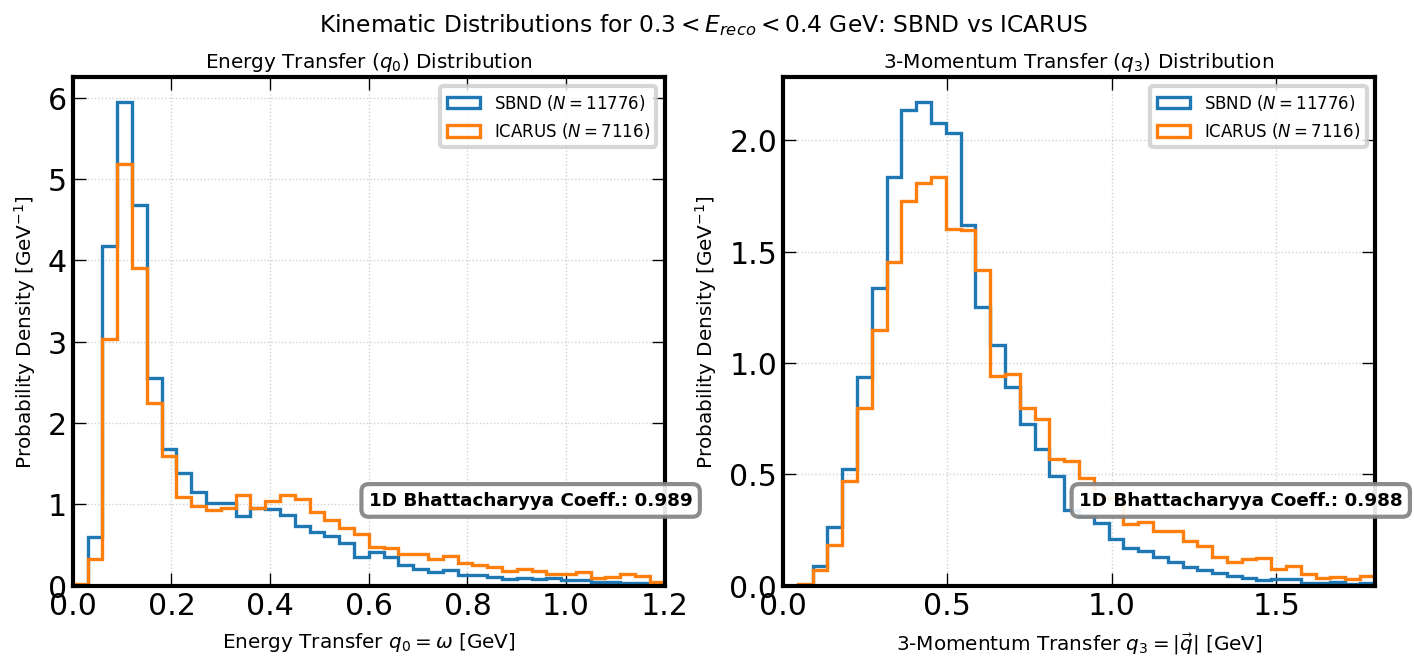

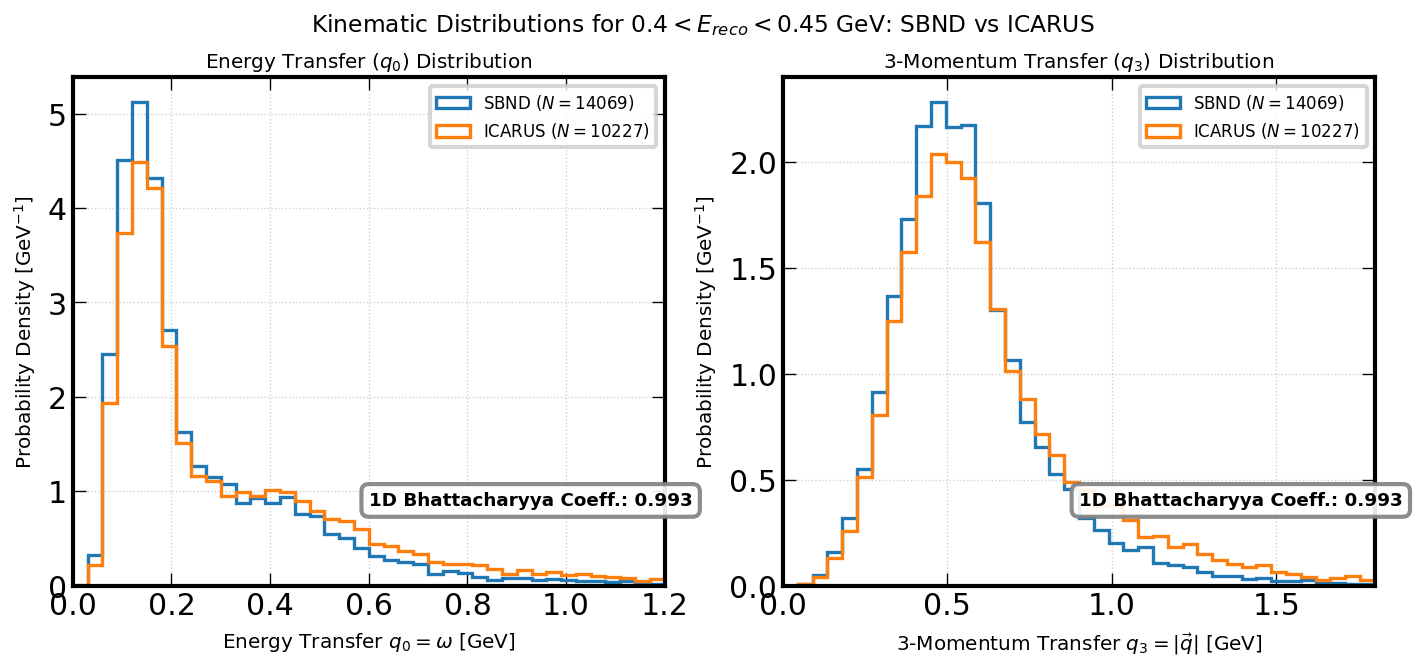

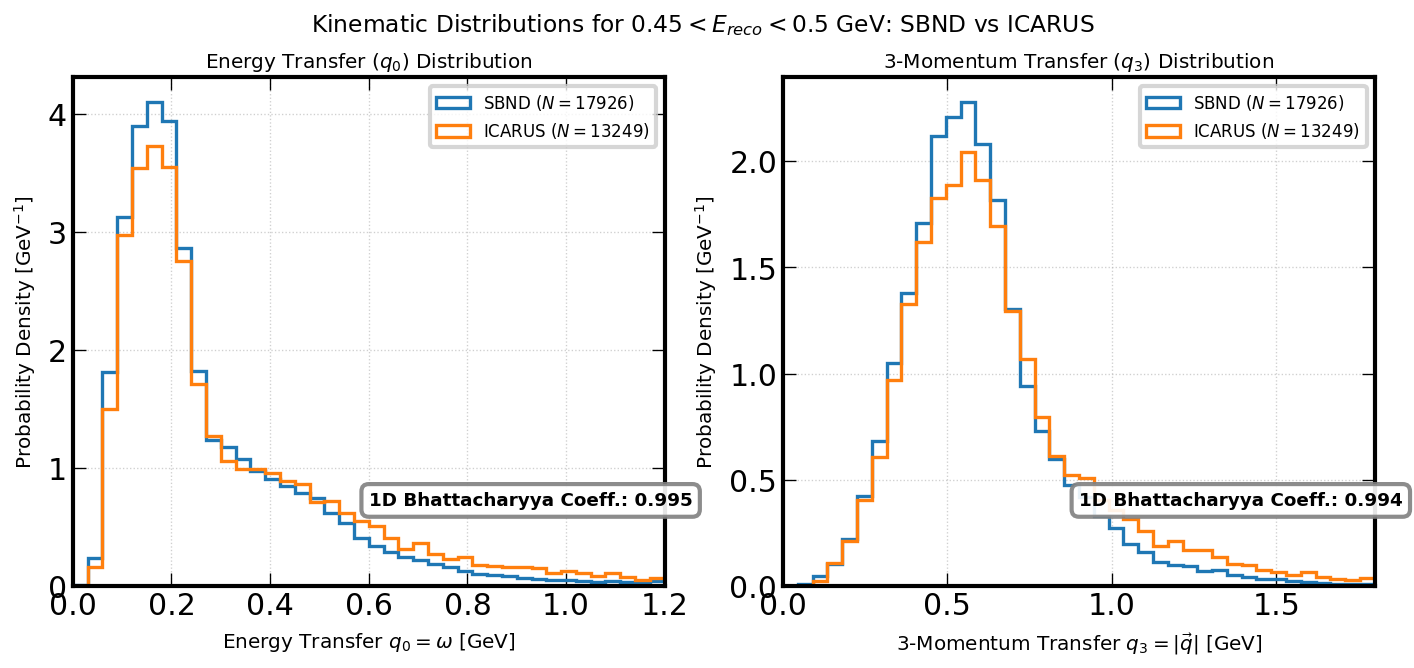

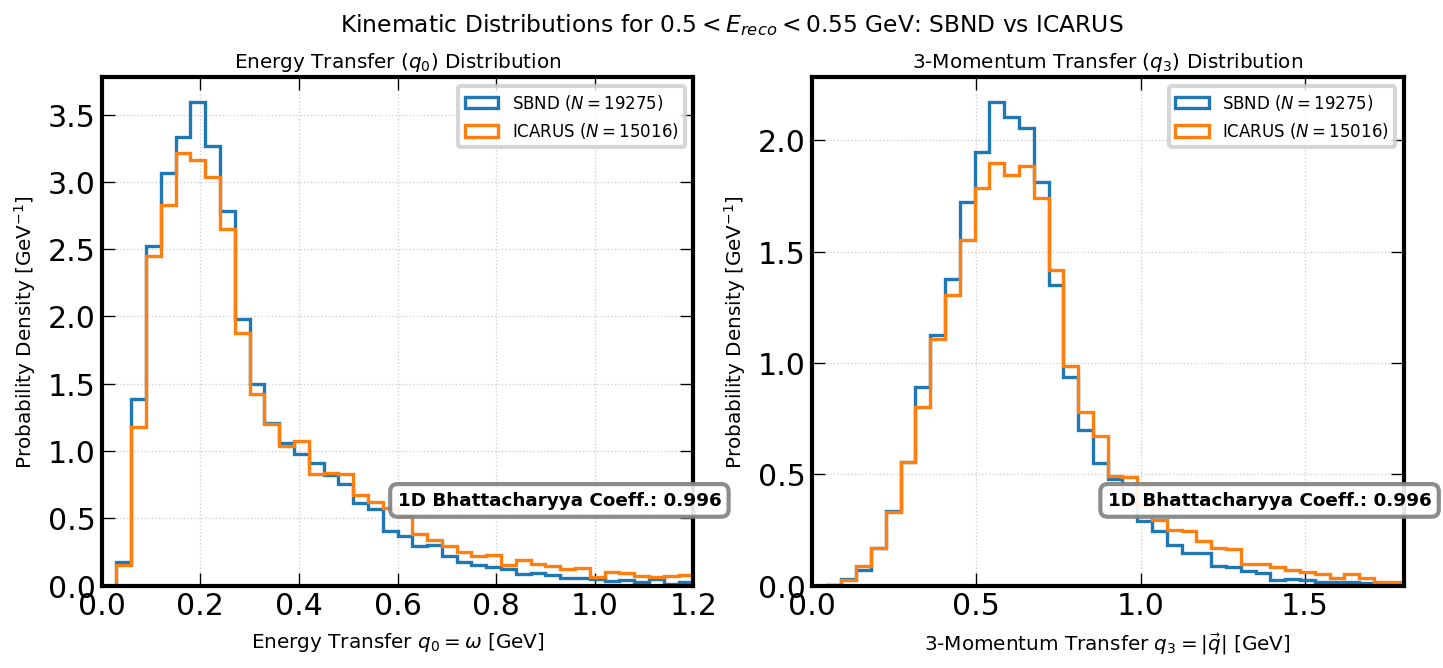

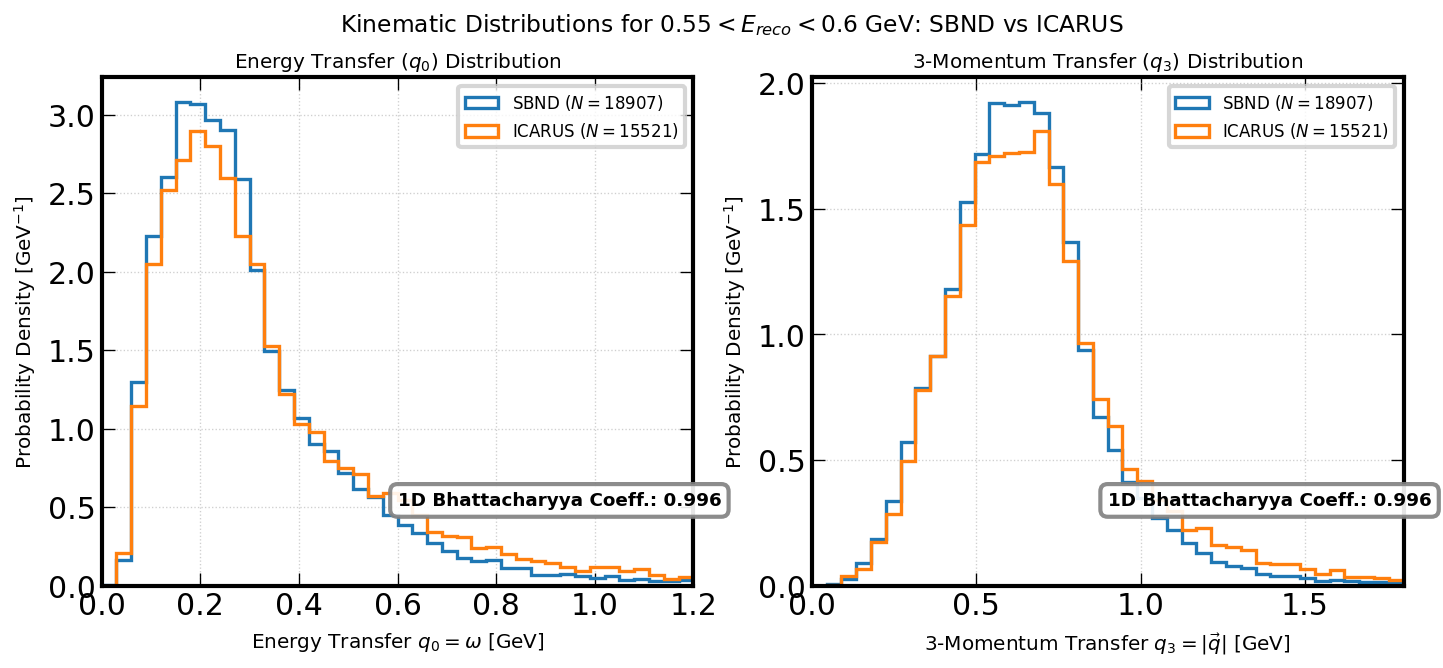

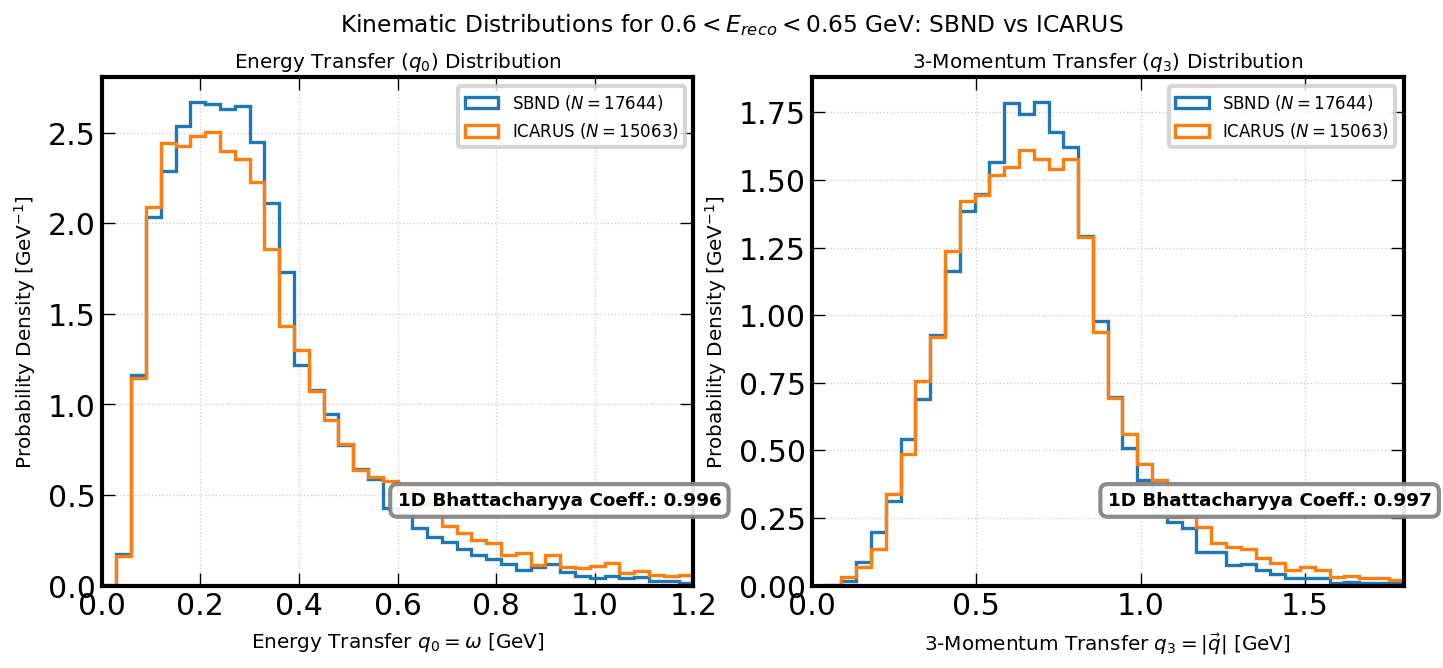

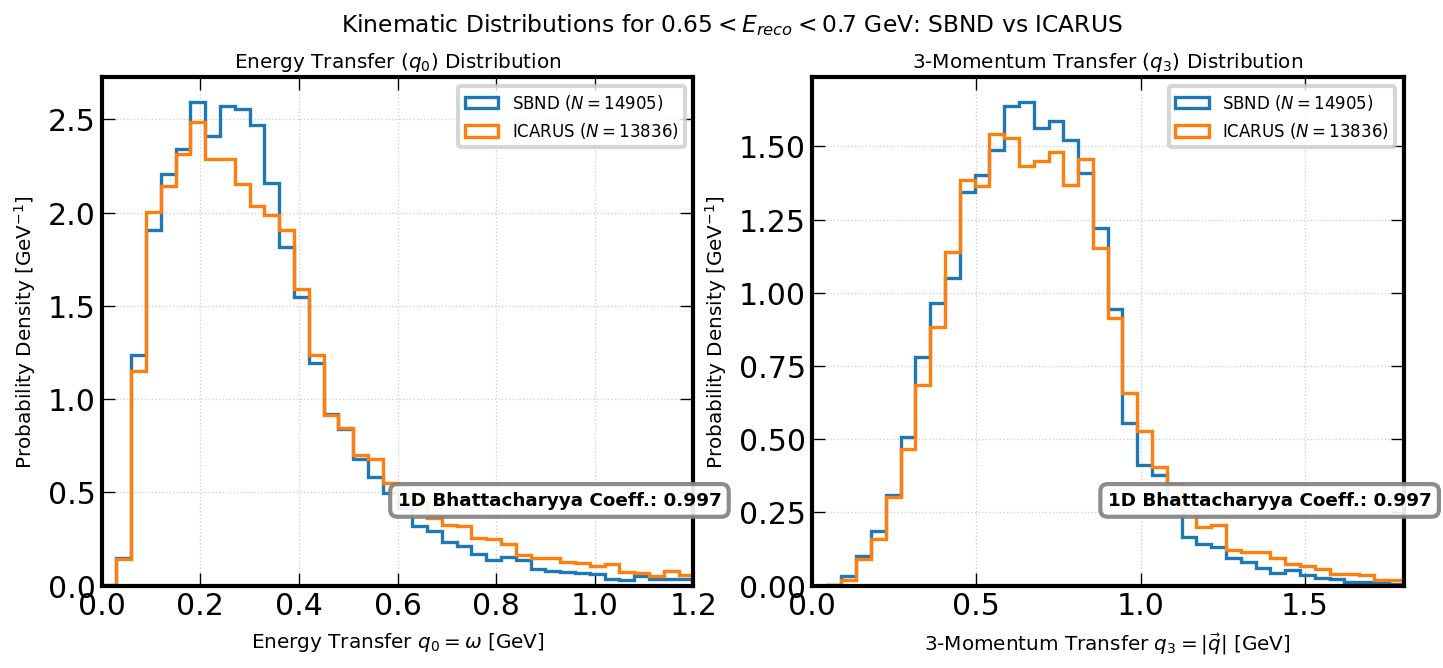

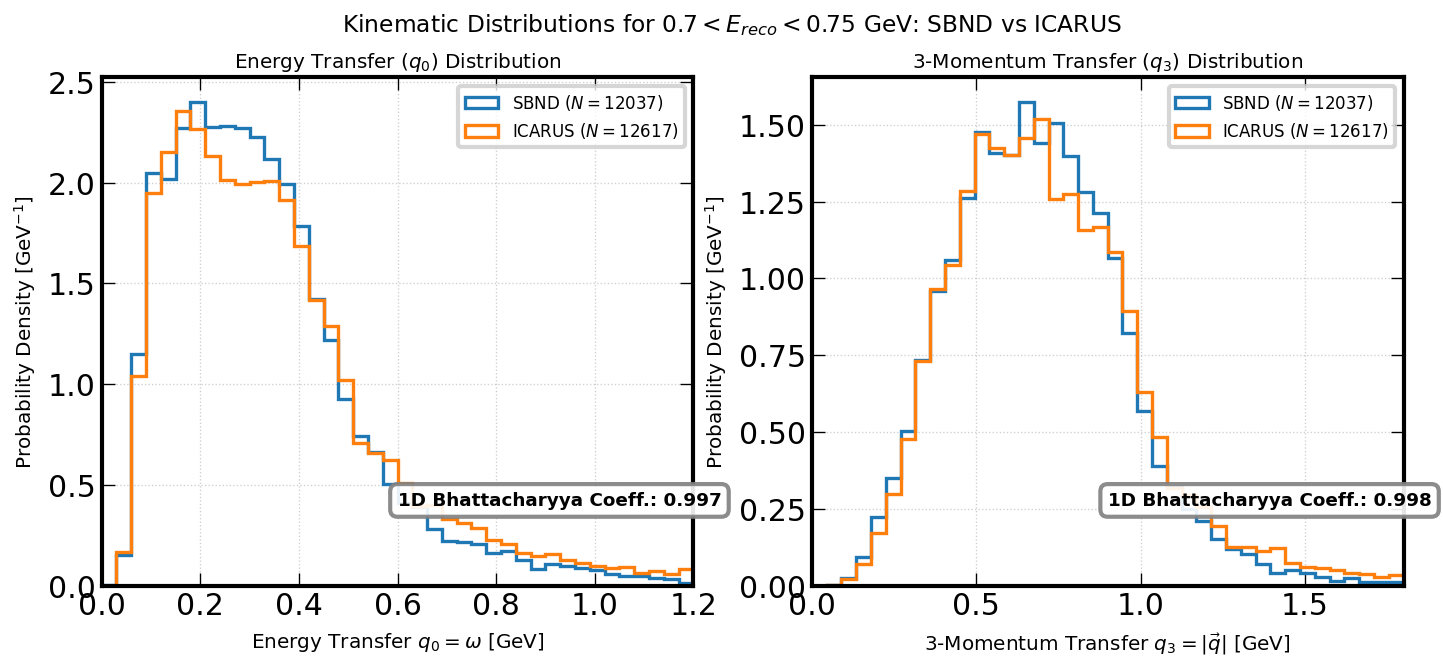

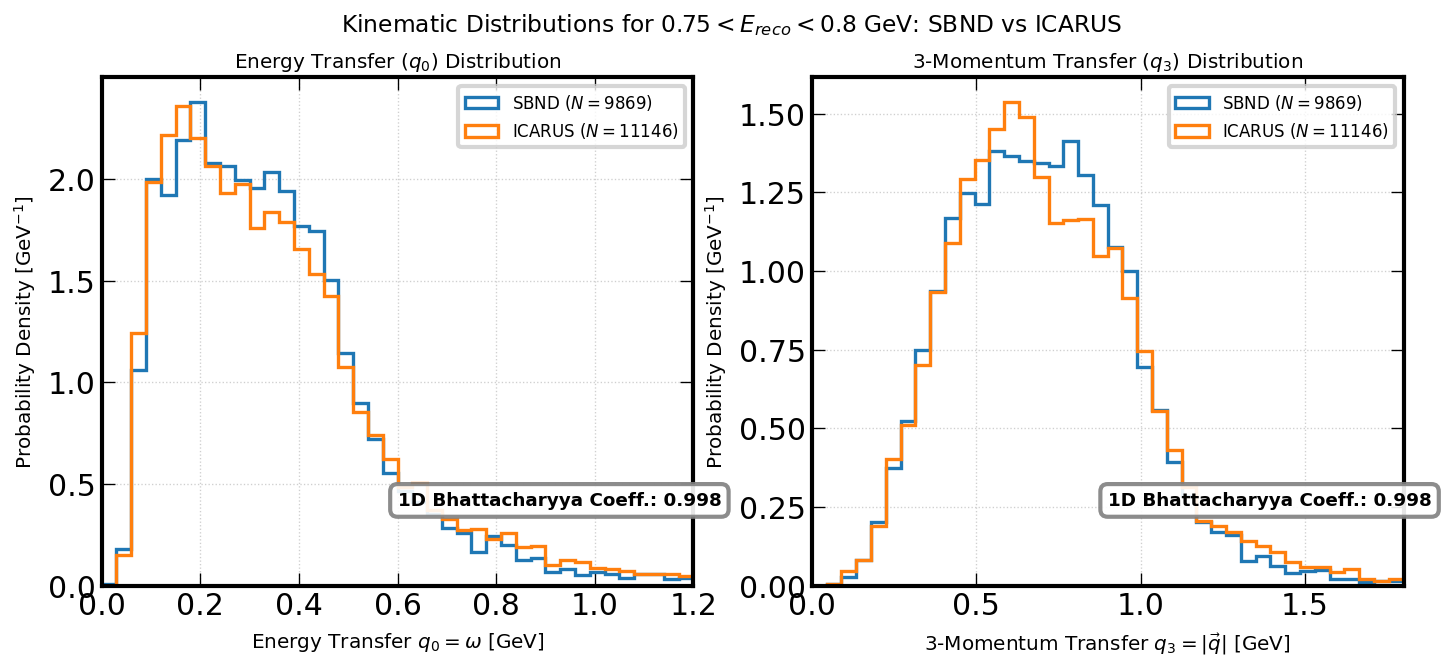

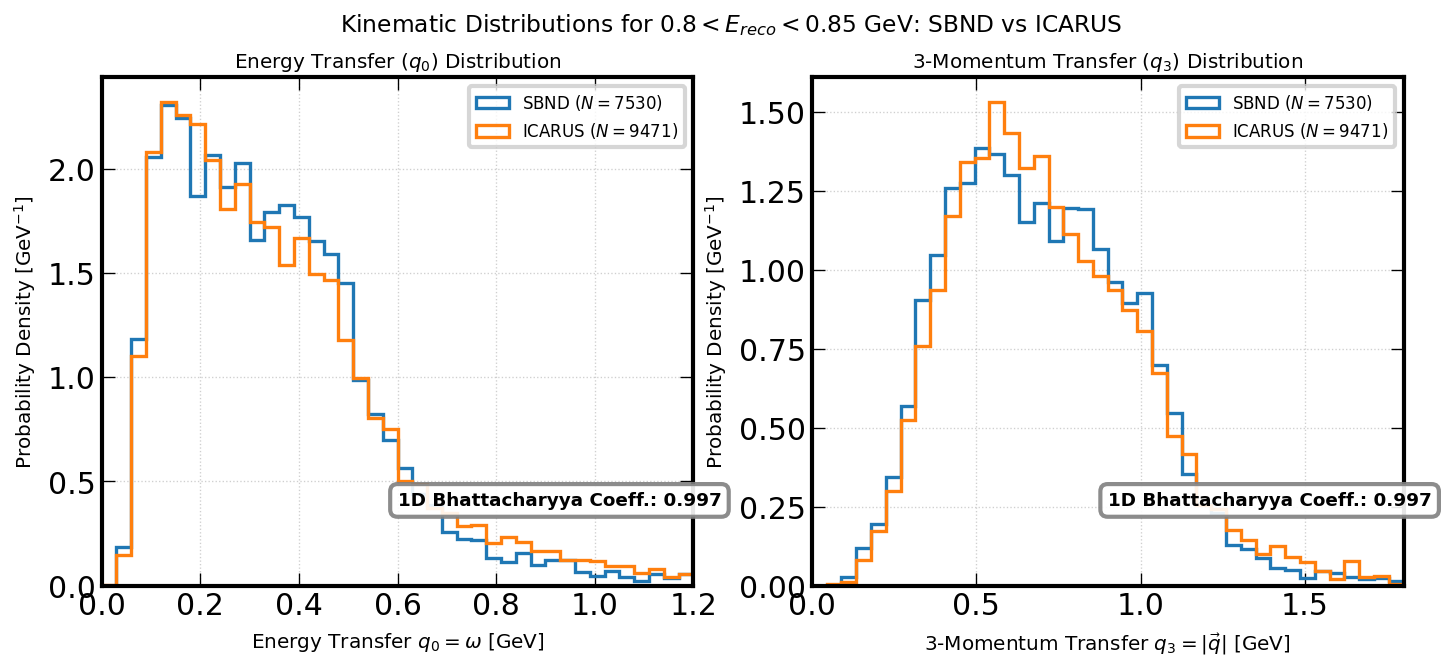

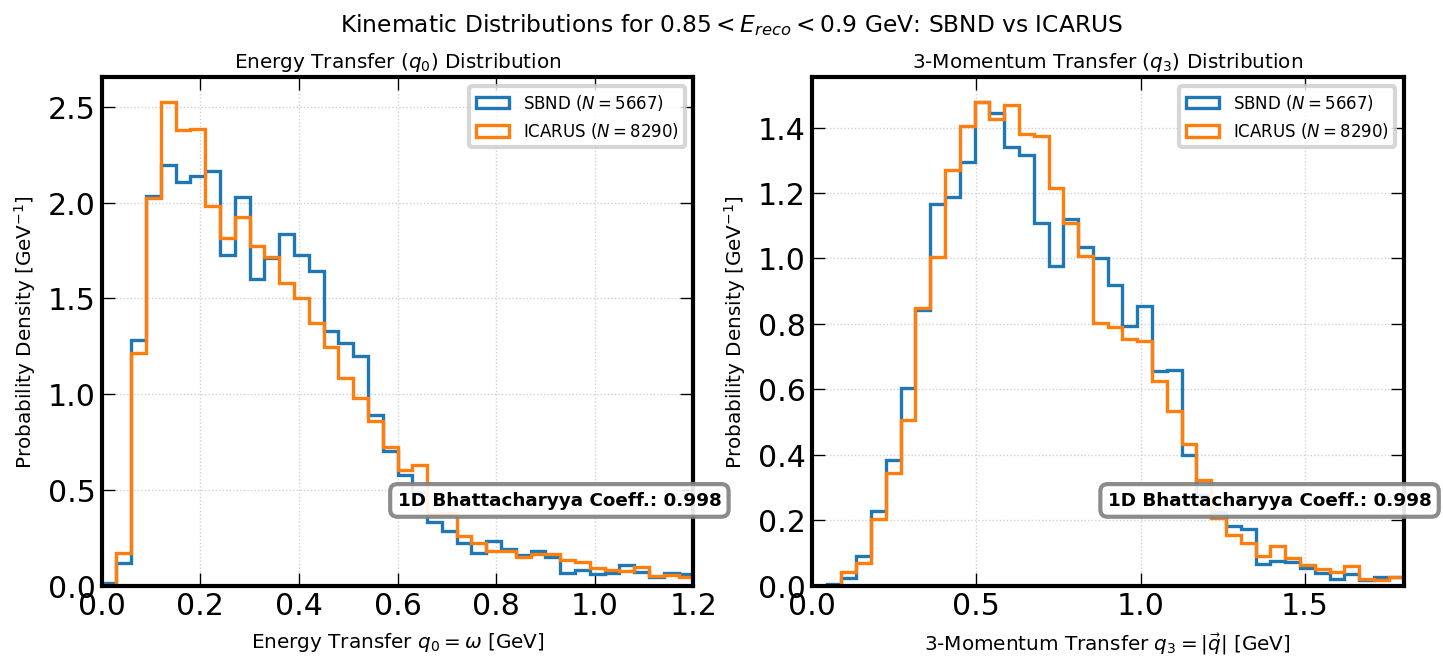

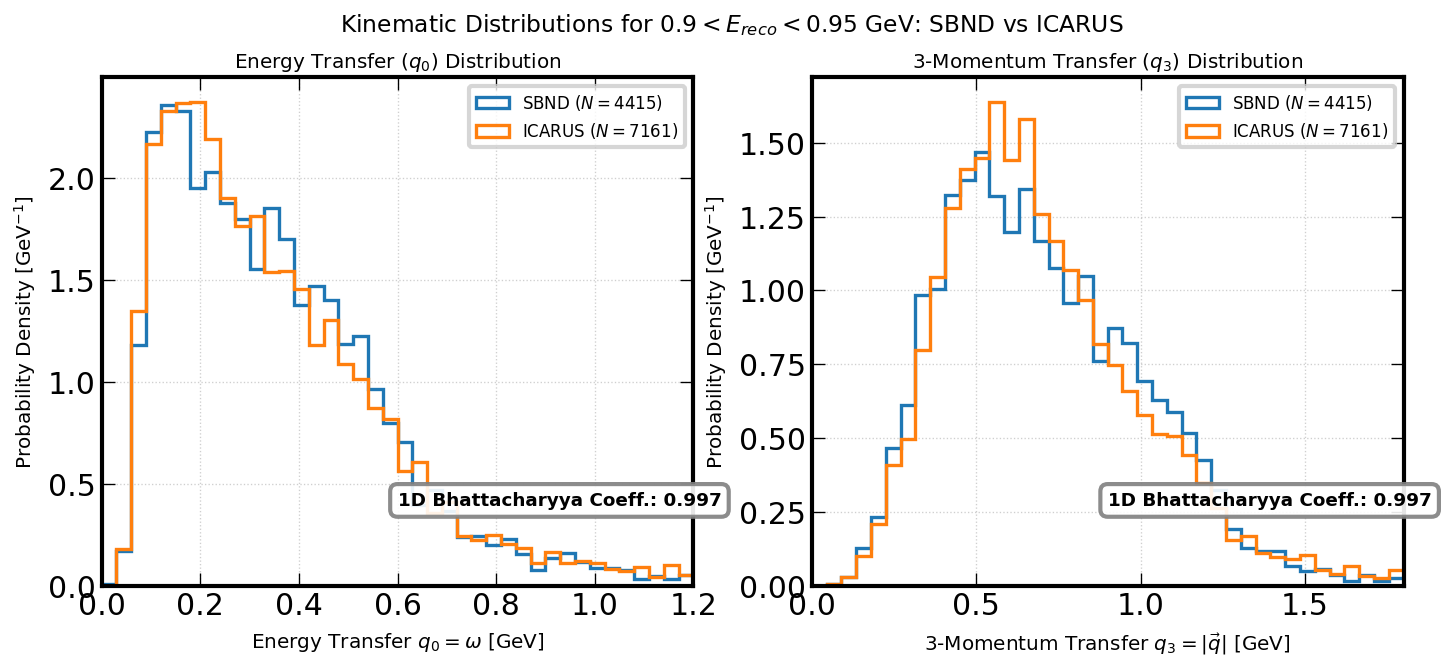

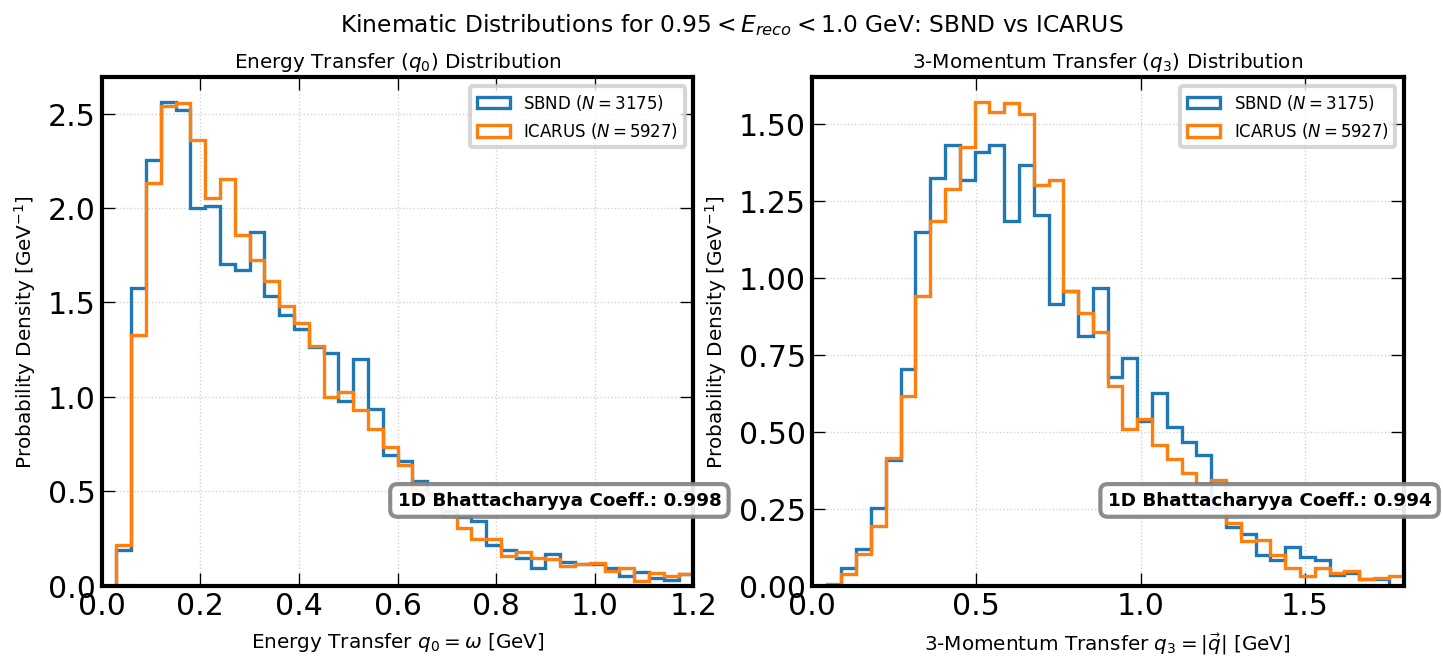

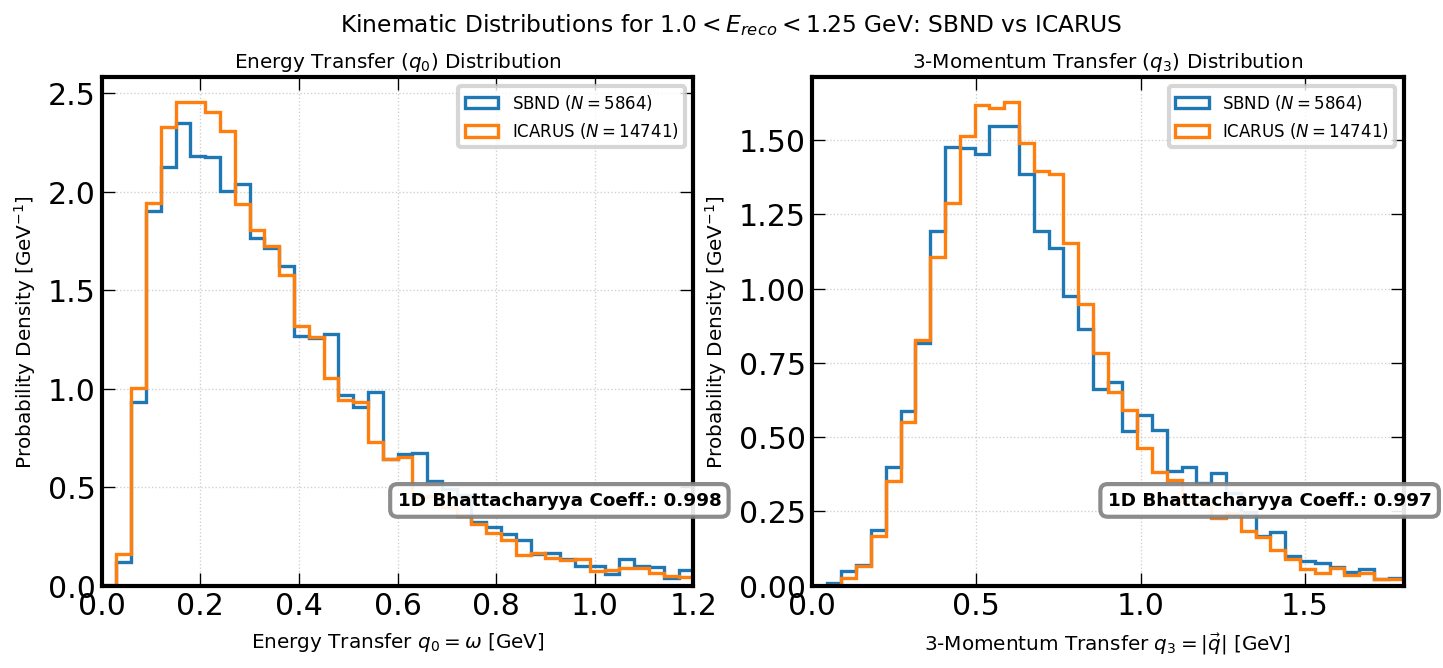

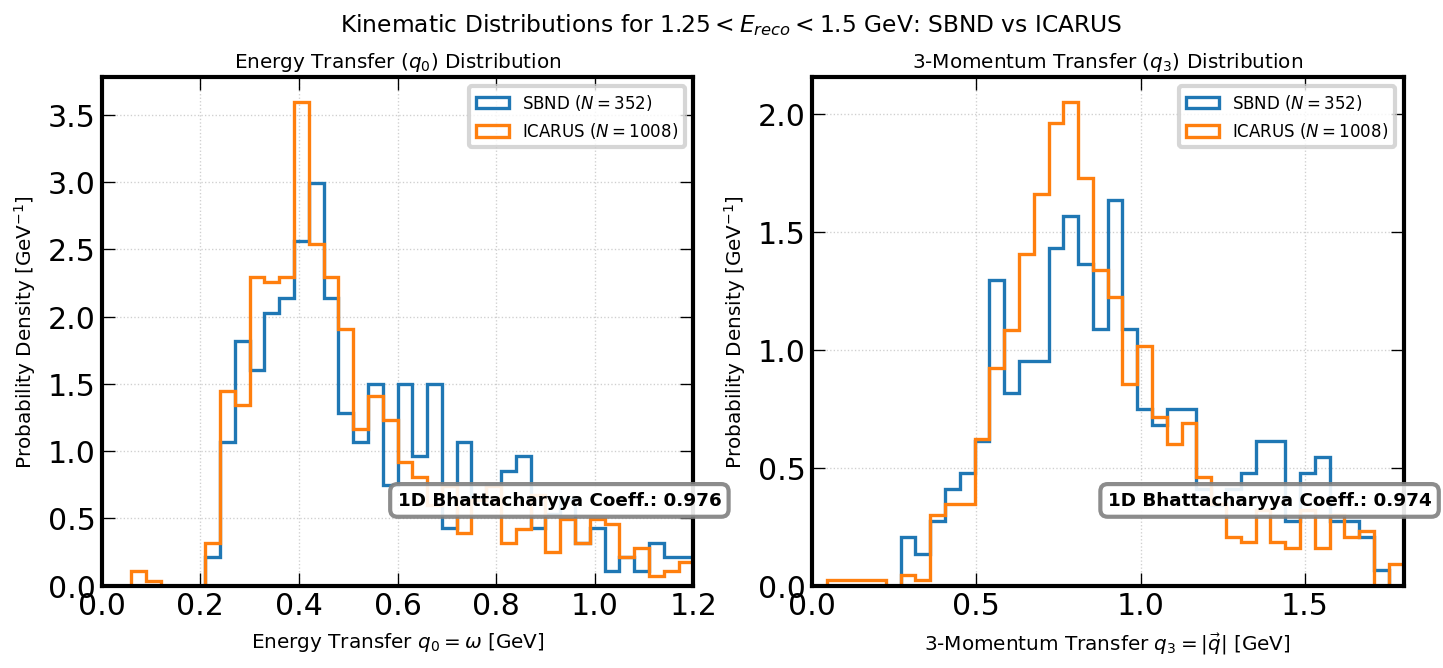

In [223]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# Particle masses in GeV
MUON_MASS = 0.105658
bins = np.array(
    [
        0.3,
        0.4,
        0.45,
        0.5,
        0.55,
        0.6,
        0.65,
        0.7,
        0.75,
        0.8,
        0.85,
        0.9,
        0.95,
        1.0,
        1.25,
        1.5,
    ]
)


def compute_true_q0_q3(df):
    """Computes true energy transfer (q0) and 3-momentum transfer magnitude (q3)

    from the DataFrame truth branches.
    """
    true_mu_E = np.sqrt(df["true_mu_p"] ** 2 + MUON_MASS**2)
    q0 = df["true_nu_E"] - true_mu_E

    cos_theta_mu = df["true_mu_dir_z"]
    q3_sq = (
        df["true_nu_E"] ** 2
        + df["true_mu_p"] ** 2
        - 2 * df["true_nu_E"] * df["true_mu_p"] * cos_theta_mu
    )

    q3 = np.sqrt(np.maximum(q3_sq, 0))
    return q0, q3


def calculate_bhattacharyya_1d(
    df1, df2, col, nbins=50, val_range=(0, 1.8)
):
    """Computes the 1D Bhattacharyya Coefficient directly from binned probability distributions."""
    if len(df1) == 0 or len(df2) == 0:
        return np.nan

    # 1D histograms over the same range
    h1, _ = np.histogram(df1[col], bins=nbins, range=list(val_range))
    h2, _ = np.histogram(df2[col], bins=nbins, range=list(val_range))

    # Normalize to discrete probabilities (sum = 1.0)
    p1 = h1 / np.sum(h1) if np.sum(h1) > 0 else np.zeros_like(h1)
    p2 = h2 / np.sum(h2) if np.sum(h2) > 0 else np.zeros_like(h2)

    # BC = sum(sqrt(p1 * p2))
    return np.sum(np.sqrt(p1 * p2))


def plot_1d_distribution(
    ax,
    df1,
    df2,
    col,
    nbins=30,
    val_range=(0, 1.5),
    xlabel="",
    title_suffix="",
):
    """Plots normalized 1D step histograms for SBND vs ICARUS and annotates the 1D BC."""
    bc_score = calculate_bhattacharyya_1d(
        df1, df2, col=col, nbins=nbins, val_range=val_range
    )

    # SBND
    ax.hist(
        df1[col],
        bins=nbins,
        range=val_range,
        density=True,
        histtype="step",
        linewidth=2,
        color="#1f77b4",
        label=f"SBND ($N={len(df1)}$)",
    )

    # ICARUS
    ax.hist(
        df2[col],
        bins=nbins,
        range=val_range,
        density=True,
        histtype="step",
        linewidth=2,
        color="#ff7f0e",
        label=f"ICARUS ($N={len(df2)}$)",
    )

    # Formatting
    ax.set_xlabel(xlabel, fontsize=12, labelpad=6)
    ax.set_ylabel("Probability Density [GeV$^{-1}$]", fontsize=12, labelpad=6)
    ax.set_xlim(val_range)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", frameon=True, fontsize=10)

    # BC Annotation
    bc_str = (
        f"1D Bhattacharyya Coeff.: {bc_score:.3f}" if not np.isnan(bc_score) else "1D BC: N/A"
    )
    ax.text(
        0.5,
        0.15,
        bc_str,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray",
            alpha=0.9,
        ),
    )


# --- Processing Loop ---
for bl, br in zip(bins[:-1], bins[1:]):
    print(f"\n--- Processing bin min:{bl}, max:{br} ---")

    # --- Compute kinematics & filter valid entries ---
    Sdf_clean = Sdf.loc[
        Sdf["selected"] & (Sdf.nu_E_calo > bl) & (Sdf.nu_E_calo < br)
    ].dropna(subset=["true_nu_E", "true_mu_p", "true_mu_dir_z"]).copy()

    Idf_clean = Idf.loc[
        Idf["selected"] & (Idf.nu_E_calo > bl) & (Idf.nu_E_calo < br)
    ].dropna(subset=["true_nu_E", "true_mu_p", "true_mu_dir_z"]).copy()

    if Sdf_clean.empty or Idf_clean.empty:
        print(
            f"Skipping bin {bl}-{br}: Insufficient data (SBND: {len(Sdf_clean)}, ICARUS: {len(Idf_clean)})"
        )
        continue

    Sdf_clean["q0_true"], Sdf_clean["q3_true"] = compute_true_q0_q3(Sdf_clean)
    Idf_clean["q0_true"], Idf_clean["q3_true"] = compute_true_q0_q3(Idf_clean)

    # Filter physical CC region (q3 >= q0 and q0 > 0)
    Sdf_clean = Sdf_clean[
        (Sdf_clean["q3_true"] >= Sdf_clean["q0_true"])
        & (Sdf_clean["q0_true"] > 0)
    ]
    Idf_clean = Idf_clean[
        (Idf_clean["q3_true"] >= Idf_clean["q0_true"])
        & (Idf_clean["q0_true"] > 0)
    ]

    # --- Plotting 1D Subplots ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

    # 1D q0 Distribution (Left Subplot)
    plot_1d_distribution(
        ax1,
        Sdf_clean,
        Idf_clean,
        col="q0_true",
        nbins=40,
        val_range=(0, 1.2),
        xlabel=r"Energy Transfer $q_0 = \omega$ [GeV]",
    )
    ax1.set_title(r"Energy Transfer ($q_0$) Distribution", fontsize=12)

    # 1D q3 Distribution (Right Subplot)
    plot_1d_distribution(
        ax2,
        Sdf_clean,
        Idf_clean,
        col="q3_true",
        nbins=40,
        val_range=(0, 1.8),
        xlabel=r"3-Momentum Transfer $q_3 = |\vec{q}|$ [GeV]",
    )
    ax2.set_title(r"3-Momentum Transfer ($q_3$) Distribution", fontsize=12)

    # Figure Super-Title
    fig.suptitle(
        rf"Kinematic Distributions for ${bl} < E_{{reco}} < {br}$ GeV: SBND vs ICARUS",
        fontsize=14,
        y=0.98,
    )

    if DOSAVE:
        plt.savefig(PLOTDIR + f"/png/{bl}_{br}_q_plots.png", bbox_inches="tight")

Text(0.5, 1.0, '$0.3 < E_{true} < 0.4$ GeV — $q_0$ Distribution')

Text(0.5, 1.0, '$0.3 < E_{true} < 0.4$ GeV — $q_3$ Distribution')

Text(0.5, 1.0, '$0.4 < E_{true} < 0.45$ GeV — $q_0$ Distribution')

Text(0.5, 1.0, '$0.4 < E_{true} < 0.45$ GeV — $q_3$ Distribution')

Text(0.5, 1.0, '$0.45 < E_{true} < 0.5$ GeV — $q_0$ Distribution')

...

Text(0.5, 1.0, '$1.0 < E_{true} < 1.25$ GeV — $q_3$ Distribution')

/home/nrowe/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


Text(0.5, 1.0, '$1.25 < E_{true} < 1.5$ GeV — $q_0$ Distribution')

Text(0.5, 1.0, '$1.25 < E_{true} < 1.5$ GeV — $q_3$ Distribution')

Text(0.5, 1.002, 'Kinematic Distributions ($q_0, q_3$) Across Energy Bins: SBND vs ICARUS')

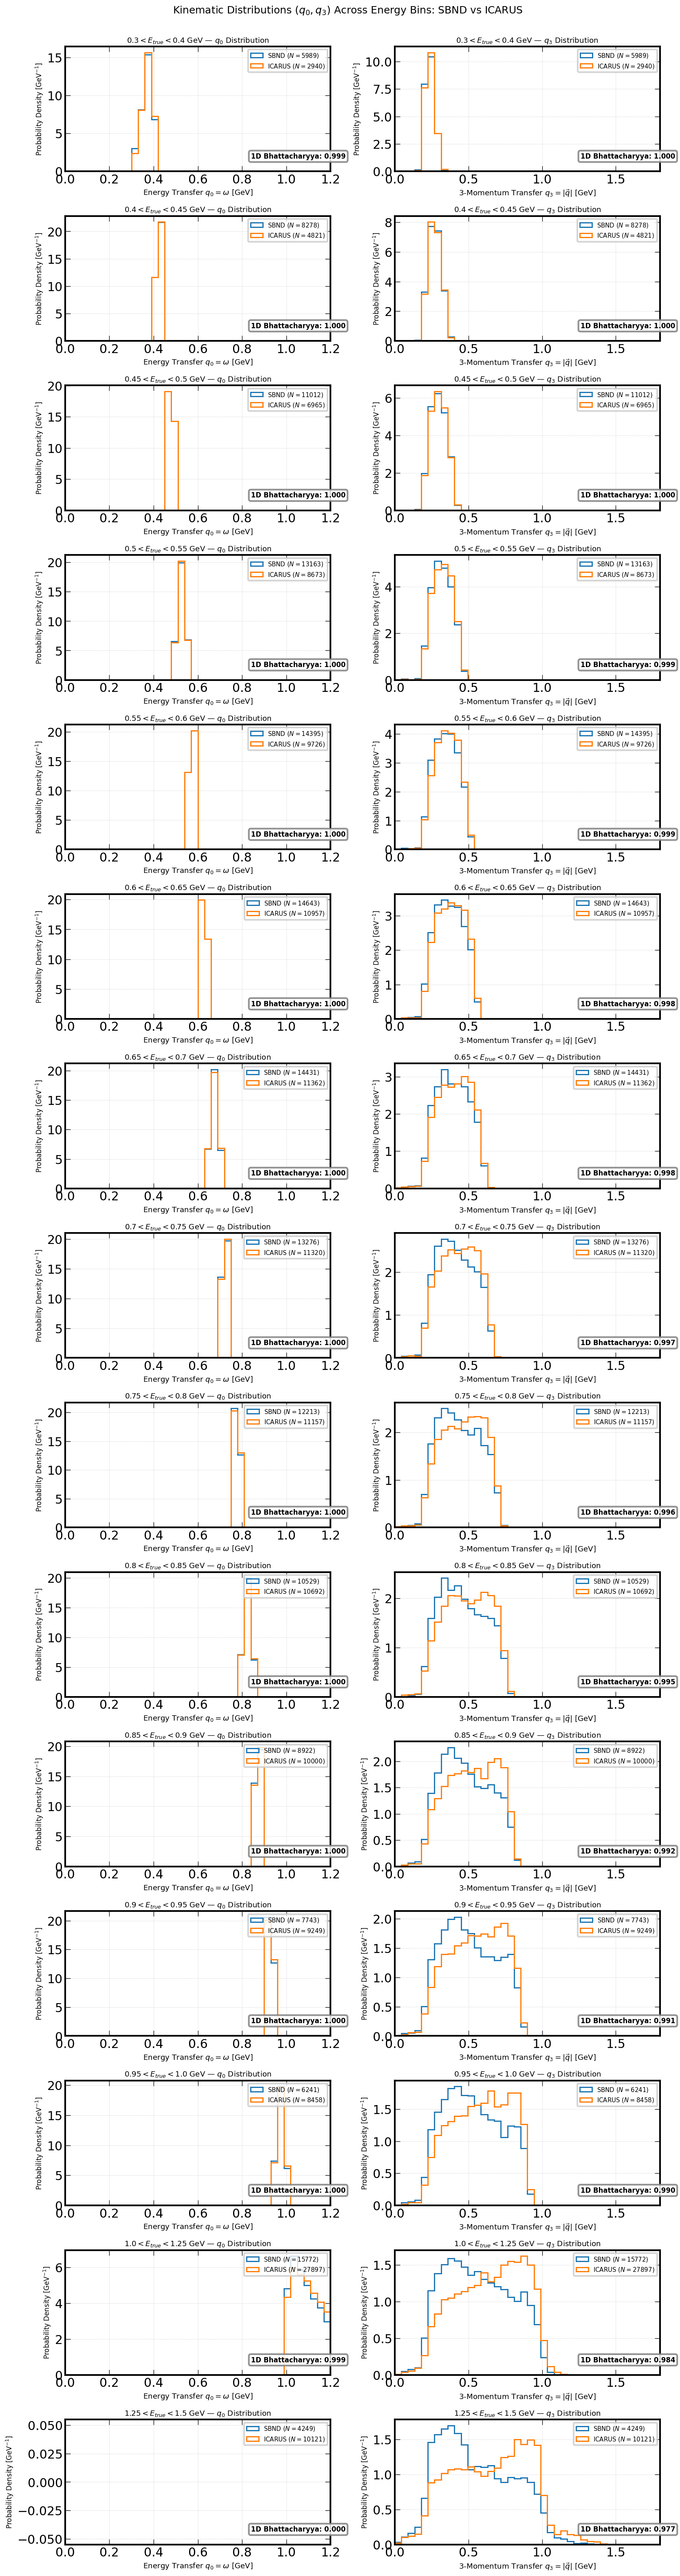

In [184]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Set to True to combine all energy bins into a single multi-panel figure.
# Set to False to display/render a separate figure per energy bin.
PLOT_SUMMARY_GRID = True

# Particle masses in GeV
MUON_MASS = 0.105658
bins = np.array(
    [
        0.3,
        0.4,
        0.45,
        0.5,
        0.55,
        0.6,
        0.65,
        0.7,
        0.75,
        0.8,
        0.85,
        0.9,
        0.95,
        1.0,
        1.25,
        1.5,
    ]
)


def compute_true_q0_q3(df):
    """Computes true energy transfer (q0) and 3-momentum transfer magnitude (q3)

    from the DataFrame truth branches.
    """
    true_mu_E = np.sqrt(df["true_mu_p"] ** 2 + MUON_MASS**2)
    q0 = df["true_nu_E"] - true_mu_E

    cos_theta_mu = df["true_mu_dir_z"]
    q3_sq = (
        df["true_nu_E"] ** 2
        + df["true_mu_p"] ** 2
        - 2 * df["true_nu_E"] * df["true_mu_p"] * cos_theta_mu
    )

    q3 = np.sqrt(np.maximum(q3_sq, 0))
    return q0, q3


def calculate_bhattacharyya_1d(df1, df2, col, nbins=50, val_range=(0, 1.8)):
    """Computes the 1D Bhattacharyya Coefficient directly from binned probability distributions."""
    if len(df1) == 0 or len(df2) == 0:
        return np.nan

    # 1D histograms over the same range
    h1, _ = np.histogram(df1[col], bins=nbins, range=list(val_range))
    h2, _ = np.histogram(df2[col], bins=nbins, range=list(val_range))

    # Normalize to discrete probabilities (sum = 1.0)
    p1 = h1 / np.sum(h1) if np.sum(h1) > 0 else np.zeros_like(h1)
    p2 = h2 / np.sum(h2) if np.sum(h2) > 0 else np.zeros_like(h2)

    # BC = sum(sqrt(p1 * p2))
    return np.sum(np.sqrt(p1 * p2))


def plot_1d_distribution(
    ax,
    df1,
    df2,
    col,
    nbins=30,
    val_range=(0, 1.5),
    xlabel="",
    title_suffix="",
):
    """Plots normalized 1D step histograms for SBND vs ICARUS and annotates the 1D BC."""
    bc_score = calculate_bhattacharyya_1d(
        df1, df2, col=col, nbins=nbins, val_range=val_range
    )

    # SBND
    ax.hist(
        df1[col],
        bins=nbins,
        range=val_range,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="#1f77b4",
        label=f"SBND ($N={len(df1)}$)",
    )

    # ICARUS
    ax.hist(
        df2[col],
        bins=nbins,
        range=val_range,
        density=True,
        histtype="step",
        linewidth=1.8,
        color="#ff7f0e",
        label=f"ICARUS ($N={len(df2)}$)",
    )

    # Formatting
    ax.set_xlabel(xlabel, fontsize=11, labelpad=4)
    ax.set_ylabel("Probability Density [GeV$^{-1}$]", fontsize=10, labelpad=4)
    ax.set_xlim(val_range)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper right", frameon=True, fontsize=9)

    # BC Annotation
    bc_str = (
        f"1D Bhattacharyya: {bc_score:.3f}" if not np.isnan(bc_score) else "1D BC: N/A"
    )
    ax.text(
        0.7,
        0.15,
        bc_str,
        transform=ax.transAxes,
        fontsize=10,
        fontweight="bold",
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="gray",
            alpha=0.85,
        ),
    )


# --- Data Filtering & Processing ---
valid_bins = []
processed_data = []

for bl, br in zip(bins[:-1], bins[1:]):
    Sdf_clean = Sdf.loc[
        Sdf["selected"] & (Sdf.nu_E_true > bl) & (Sdf.nu_E_true < br)
    ].dropna(subset=["true_nu_E", "true_mu_p", "true_mu_dir_z"]).copy()

    Idf_clean = Idf.loc[
        Idf["selected"] & (Idf.nu_E_true > bl) & (Idf.nu_E_true < br)
    ].dropna(subset=["true_nu_E", "true_mu_p", "true_mu_dir_z"]).copy()

    if Sdf_clean.empty or Idf_clean.empty:
        print(
            f"Skipping bin {bl}-{br}: Insufficient data (SBND: {len(Sdf_clean)}, ICARUS: {len(Idf_clean)})"
        )
        continue

    Sdf_clean["q0_true"], Sdf_clean["q3_true"] = compute_true_q0_q3(Sdf_clean)
    Idf_clean["q0_true"], Idf_clean["q3_true"] = compute_true_q0_q3(Idf_clean)

    # # Filter physical CC region (q3 >= q0 and q0 > 0)
    # Sdf_clean = Sdf_clean[
    #     (Sdf_clean["q3_true"] >= Sdf_clean["q0_true"])
    #     & (Sdf_clean["q0_true"] > 0)
    # ]
    # Idf_clean = Idf_clean[
    #     (Idf_clean["q3_true"] >= Idf_clean["q0_true"])
    #     & (Idf_clean["q0_true"] > 0)
    # ]

    valid_bins.append((bl, br))
    processed_data.append((Sdf_clean, Idf_clean))

# --- Plotting Mode Execution ---
if PLOT_SUMMARY_GRID:
    n_valid = len(valid_bins)
    if n_valid > 0:
        # Create a combined grid figure: rows = energy bins, cols = 2 (q0 and q3)
        fig, axes = plt.subplots(
            n_valid, 2, figsize=(14, 3.5 * n_valid), dpi=120, squeeze=False
        )

        for i, ((bl, br), (Sdf_clean, Idf_clean)) in enumerate(
            zip(valid_bins, processed_data)
        ):
            ax_q0 = axes[i, 0]
            ax_q3 = axes[i, 1]

            # 1D q0 Distribution
            plot_1d_distribution(
                ax_q0,
                Sdf_clean,
                Idf_clean,
                col="nu_E_true",
                nbins=40,
                val_range=(0, 1.2),
                xlabel="True Nu Energy",#xlabel=r"Energy Transfer $q_0 = \omega$ [GeV]",
            )
            ax_q0.set_title(
                rf"${bl} < E_{{true}} < {br}$ GeV — $q_0$ Distribution",
                fontsize=11,
            )

            # 1D q3 Distribution
            plot_1d_distribution(
                ax_q3,
                Sdf_clean,
                Idf_clean,
                col="true_mu_p",
                nbins=40,
                val_range=(0, 1.8),
                xlabel="True Muon Momentum",#xlabel=r"3-Momentum Transfer $q_3 = |\vec{q}|$ [GeV]",
            )
            ax_q3.set_title(
                rf"${bl} < E_{{true}} < {br}$ GeV — $q_3$ Distribution",
                fontsize=11,
            )

        fig.suptitle(
            "Kinematic Distributions ($E_{{\\nu, p_{{\\mu}}$) Across Energy Bins: SBND vs ICARUS",#"Kinematic Distributions ($q_0, q_3$) Across Energy Bins: SBND vs ICARUS",
            fontsize=15,
            y=1.002,
        )
        plt.tight_layout()
        plt.show()

else:
    # Plot as individual standalone figures per energy bin
    for (bl, br), (Sdf_clean, Idf_clean) in zip(valid_bins, processed_data):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

        # 1D q0 Distribution
        plot_1d_distribution(
            ax1,
            Sdf_clean,
            Idf_clean,
            col="q0_true",
            nbins=40,
            val_range=(0, 1.2),
            xlabel=r"Energy Transfer $q_0 = \omega$ [GeV]",
        )
        ax1.set_title(r"Energy Transfer ($q_0$) Distribution", fontsize=12)

        # 1D q3 Distribution
        plot_1d_distribution(
            ax2,
            Sdf_clean,
            Idf_clean,
            col="q3_true",
            nbins=40,
            val_range=(0, 1.8),
            xlabel=r"3-Momentum Transfer $q_3 = |\vec{q}|$ [GeV]",
        )
        ax2.set_title(r"3-Momentum Transfer ($q_3$) Distribution", fontsize=12)

        fig.suptitle(
            rf"Kinematic Distributions for ${bl} < E_{{true}} < {br}$ GeV: SBND vs ICARUS",
            fontsize=14,
            y=0.98,
        )

        plt.tight_layout()
        plt.show()

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.3 < E_{reco} < 0.4$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

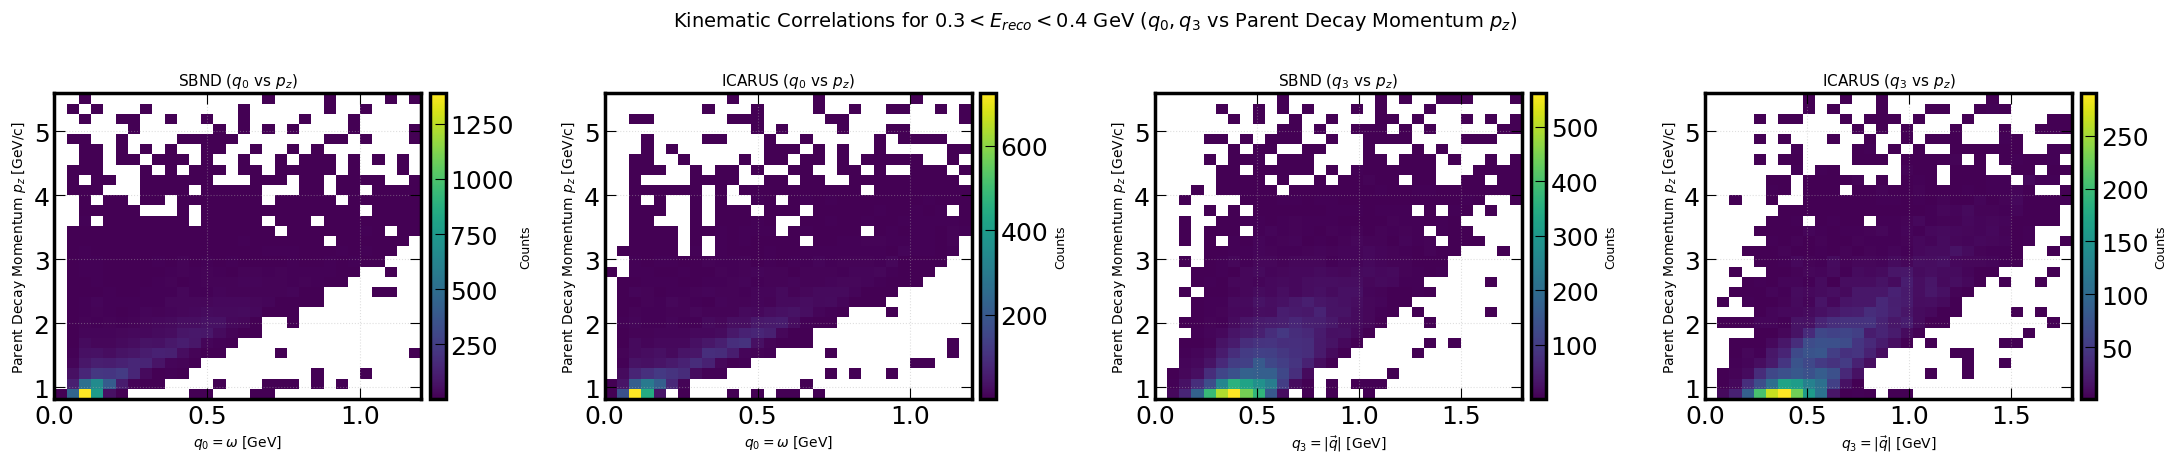

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.4 < E_{reco} < 0.45$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

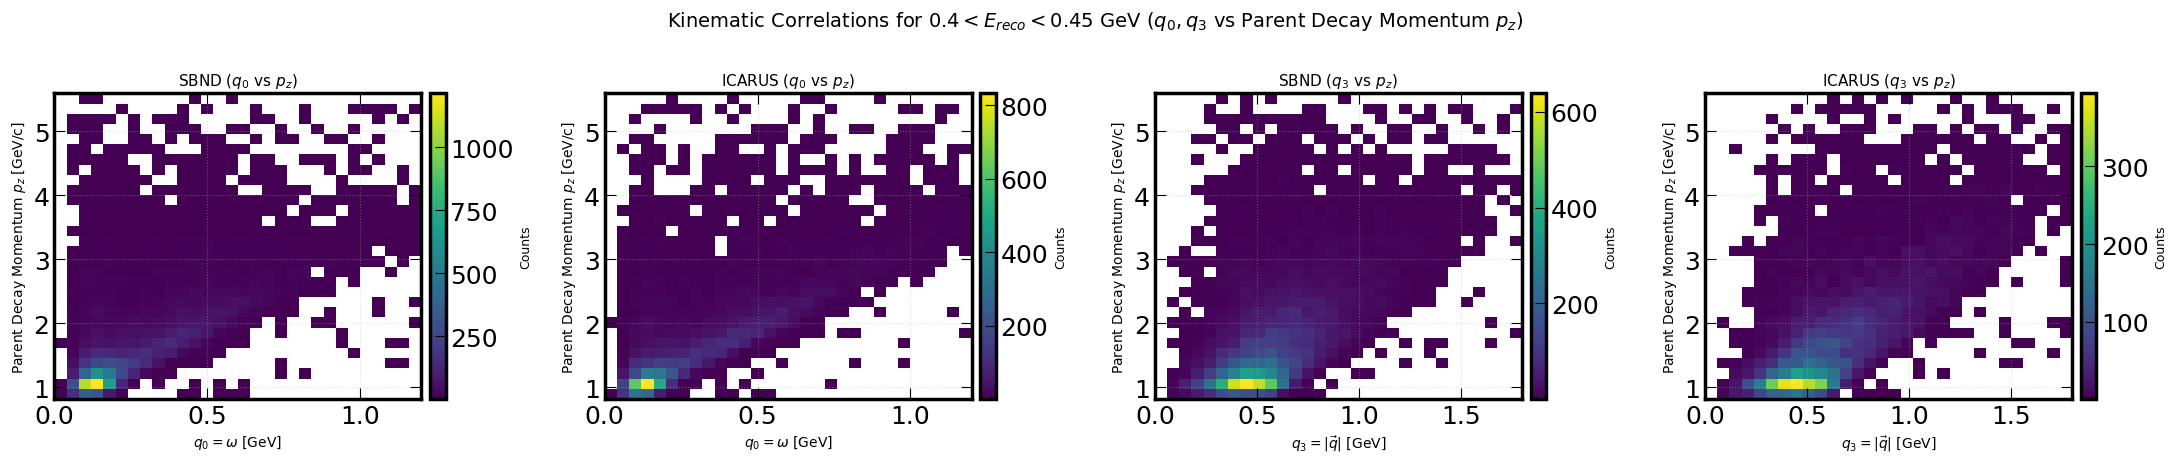

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.45 < E_{reco} < 0.5$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

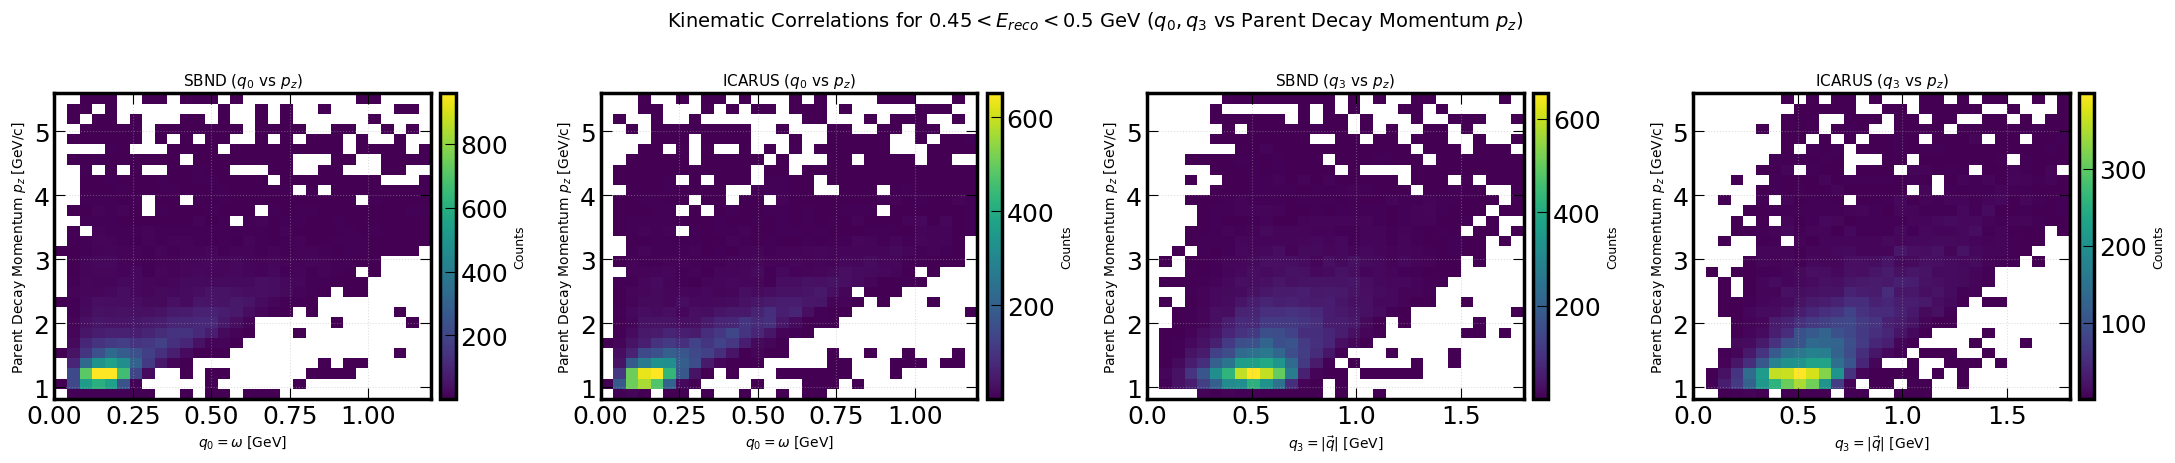

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.5 < E_{reco} < 0.55$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

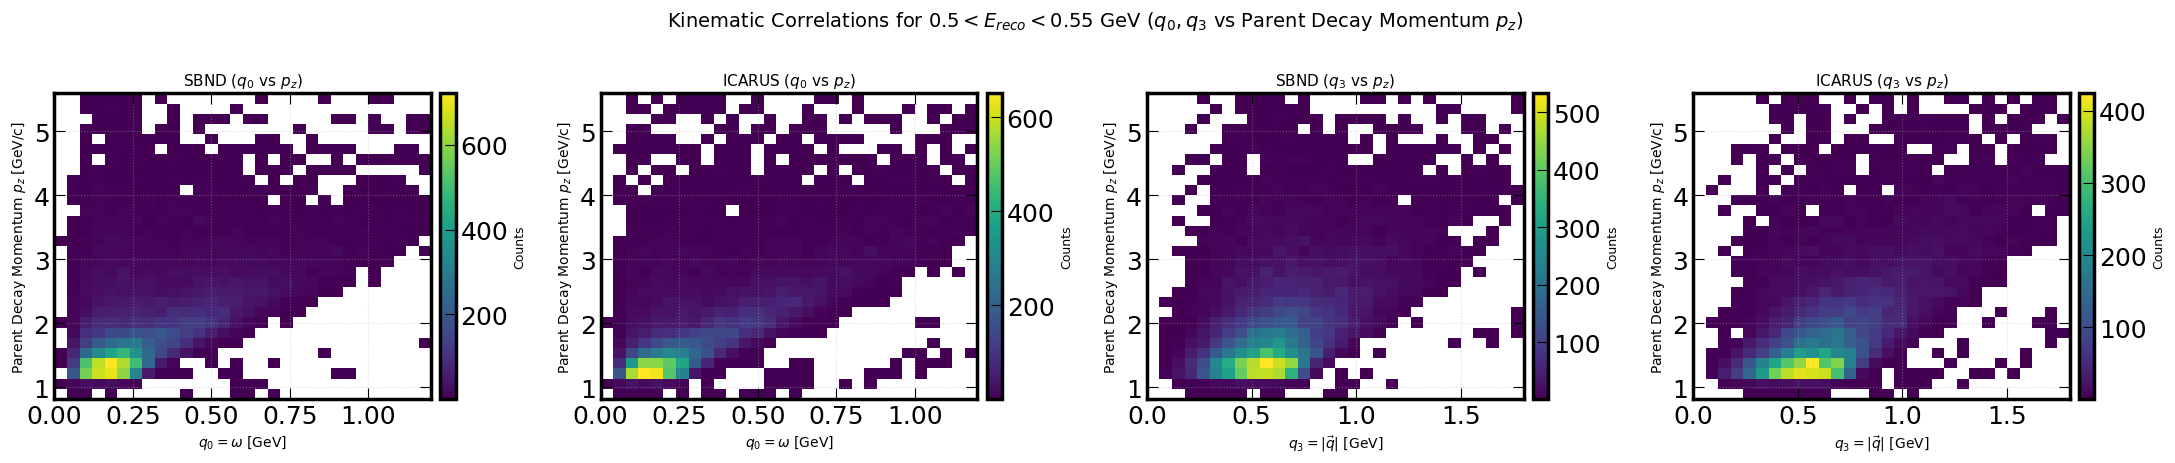

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.55 < E_{reco} < 0.6$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

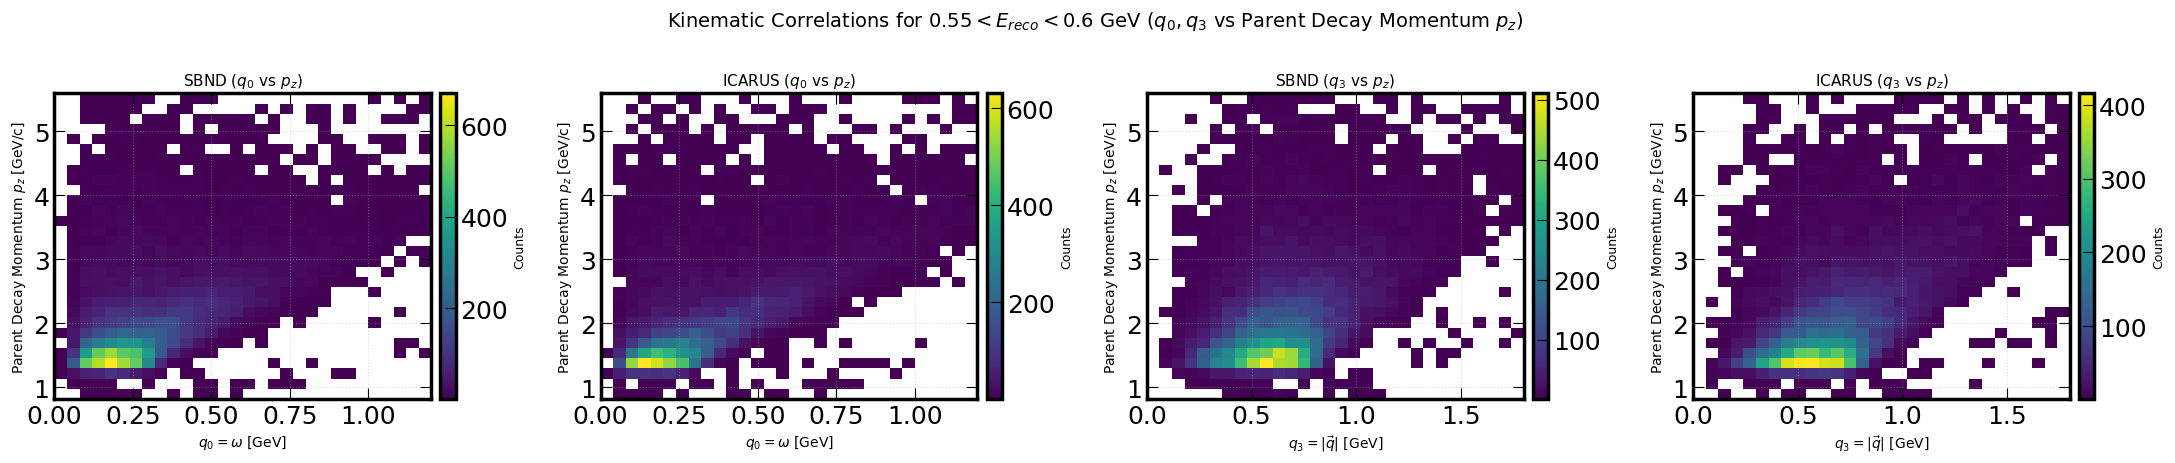

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.6 < E_{reco} < 0.65$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

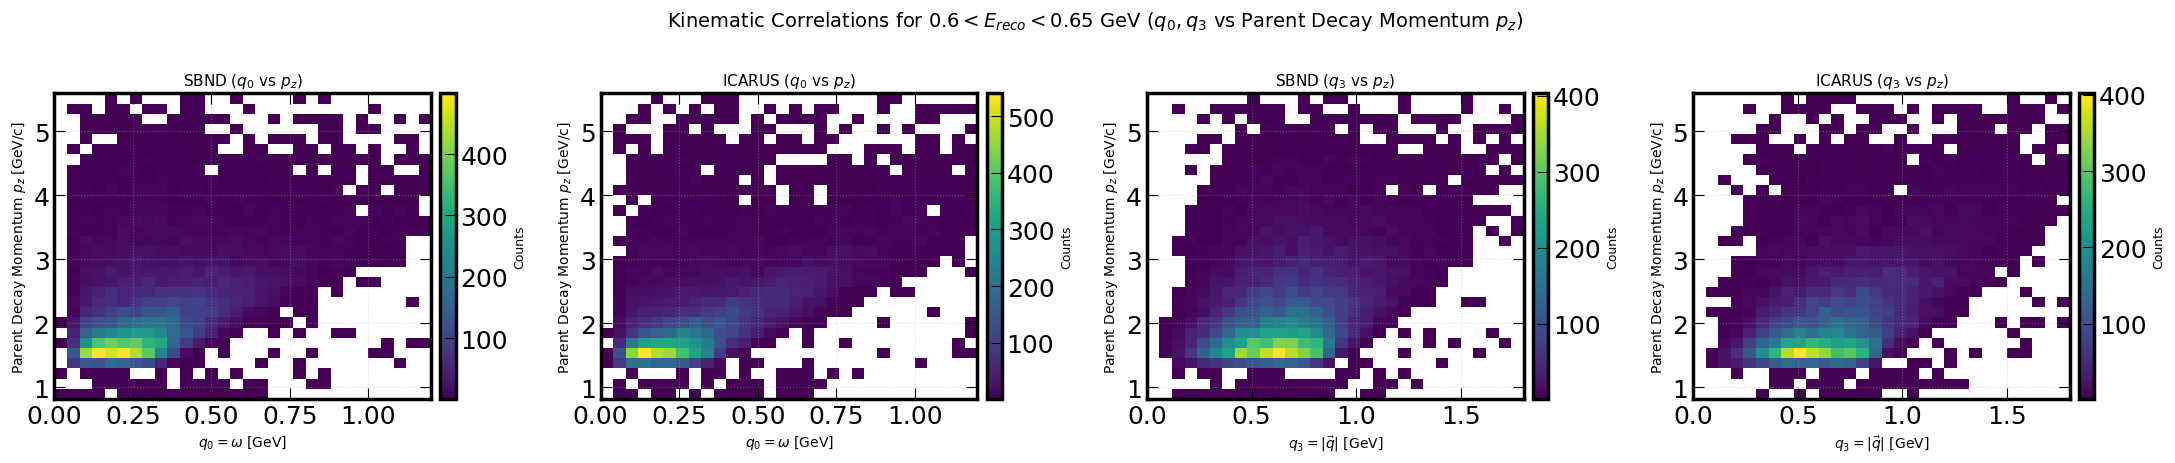

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.65 < E_{reco} < 0.7$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

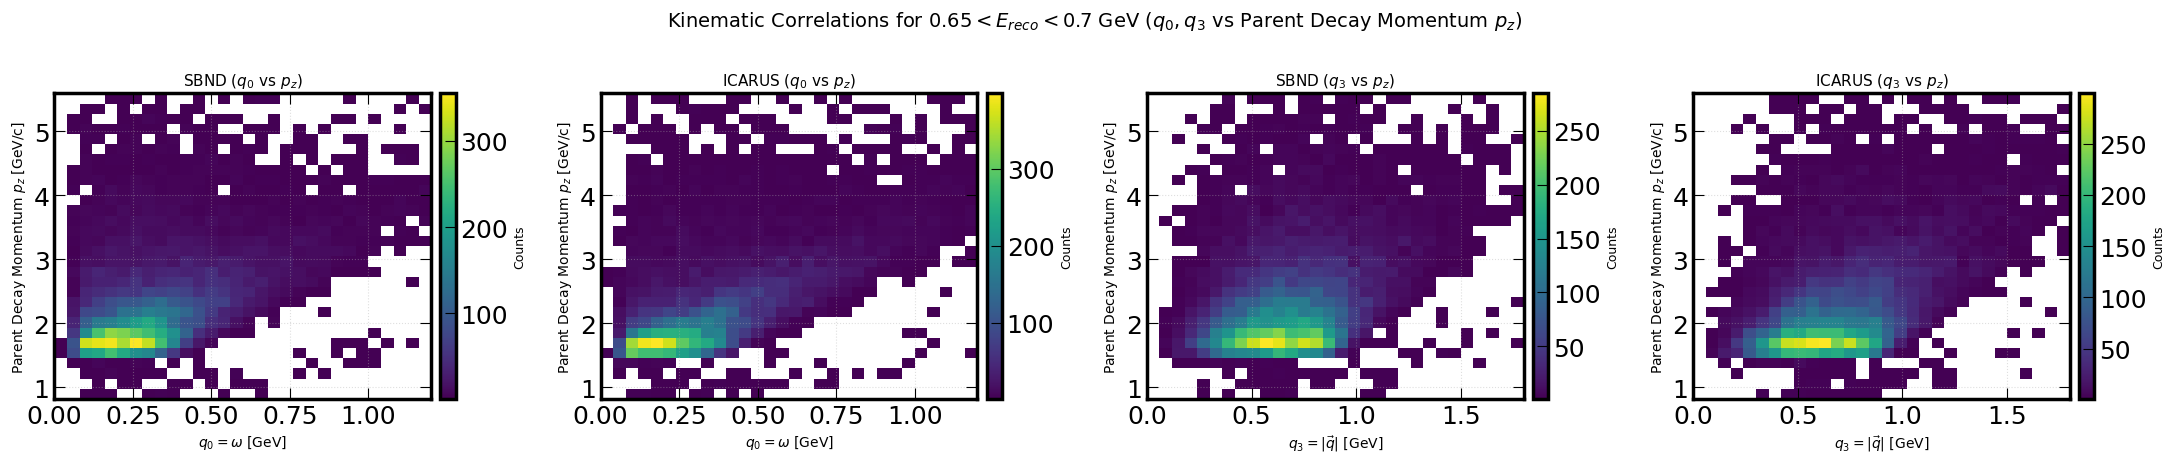

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.7 < E_{reco} < 0.75$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

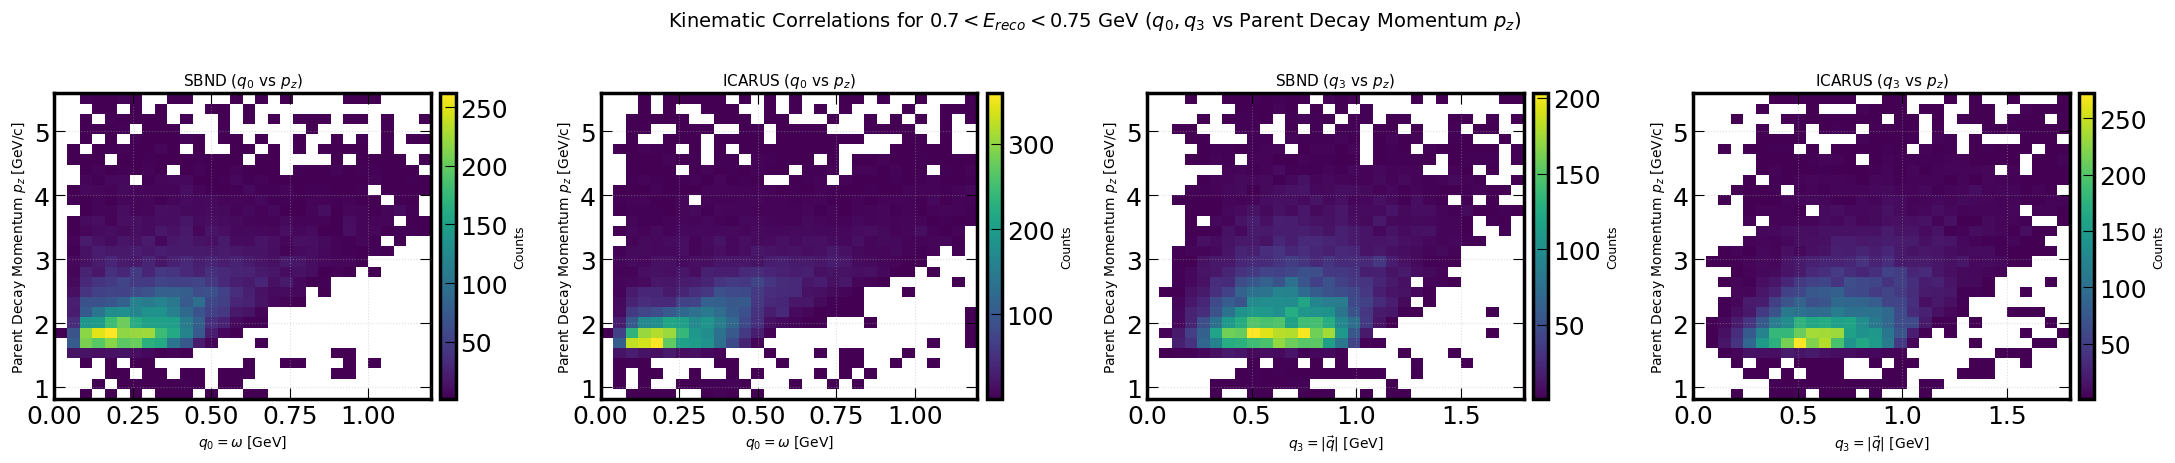

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.75 < E_{reco} < 0.8$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

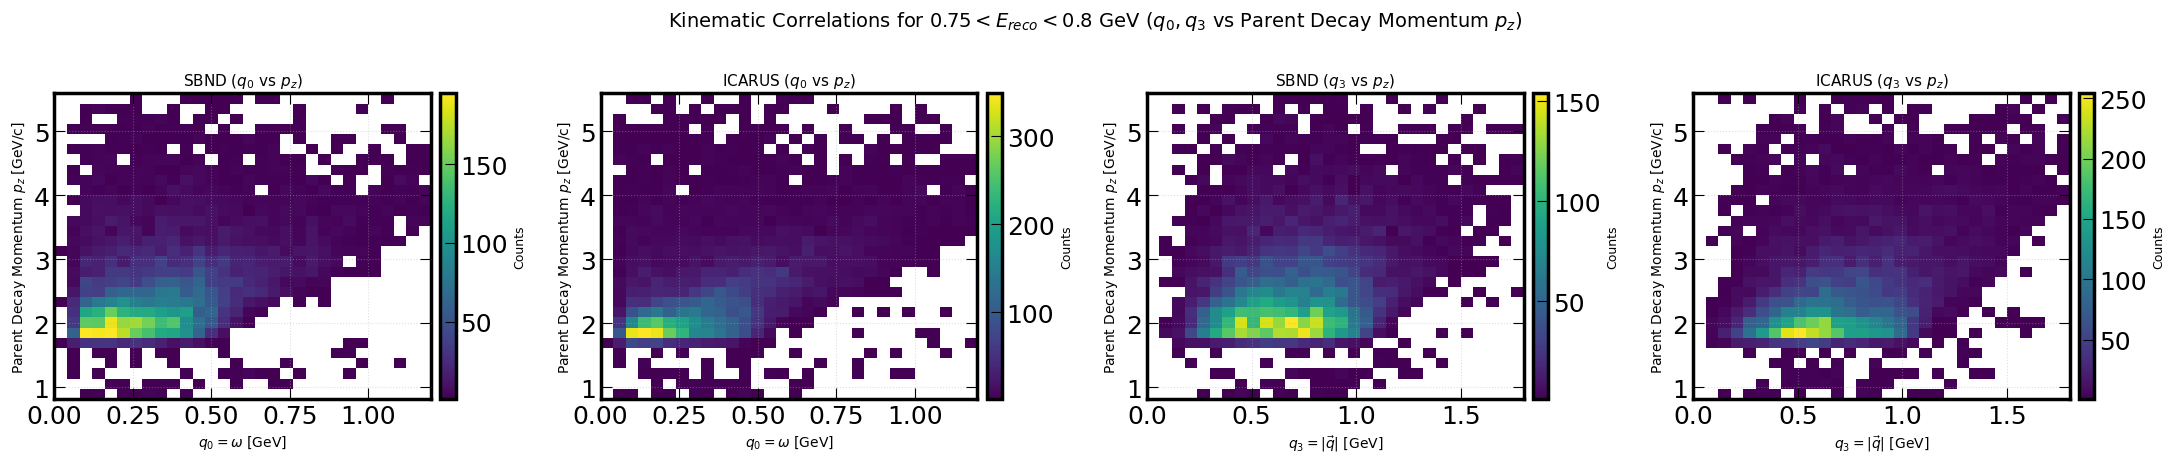

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.8 < E_{reco} < 0.85$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

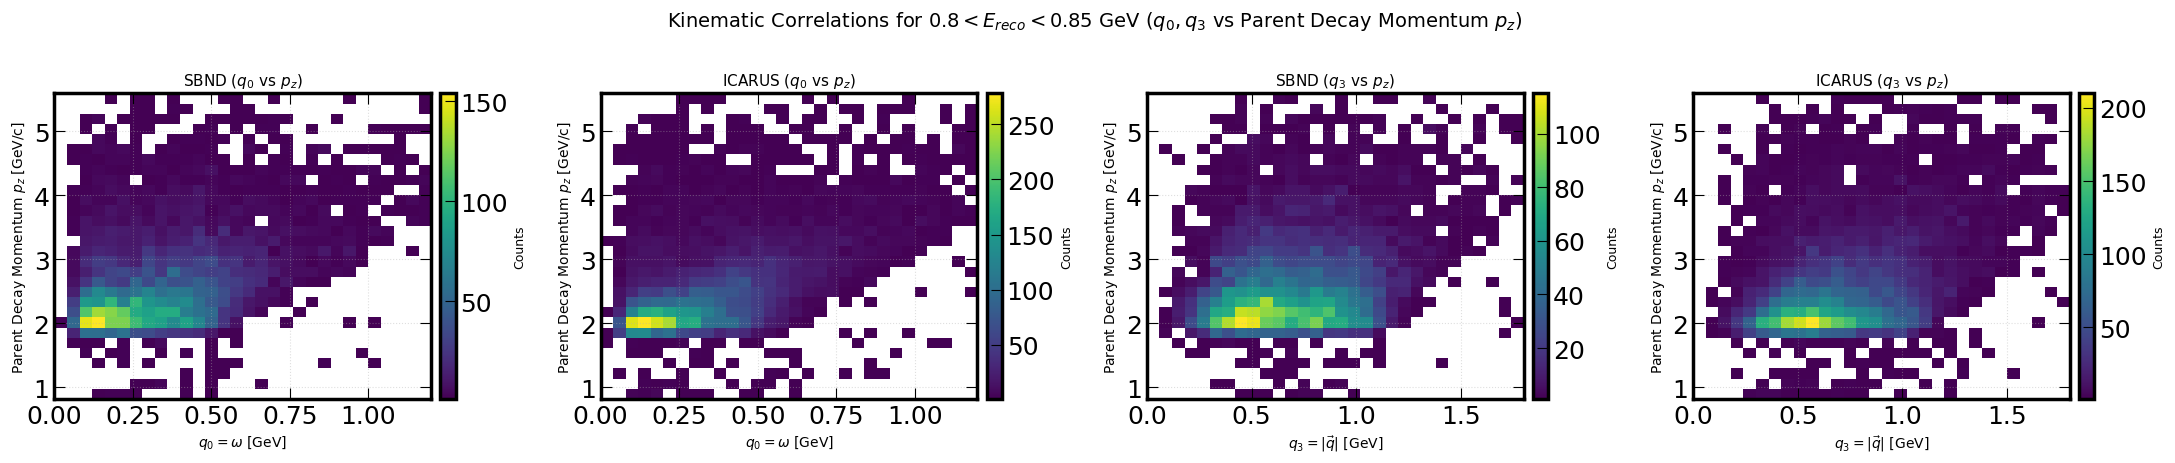

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.85 < E_{reco} < 0.9$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

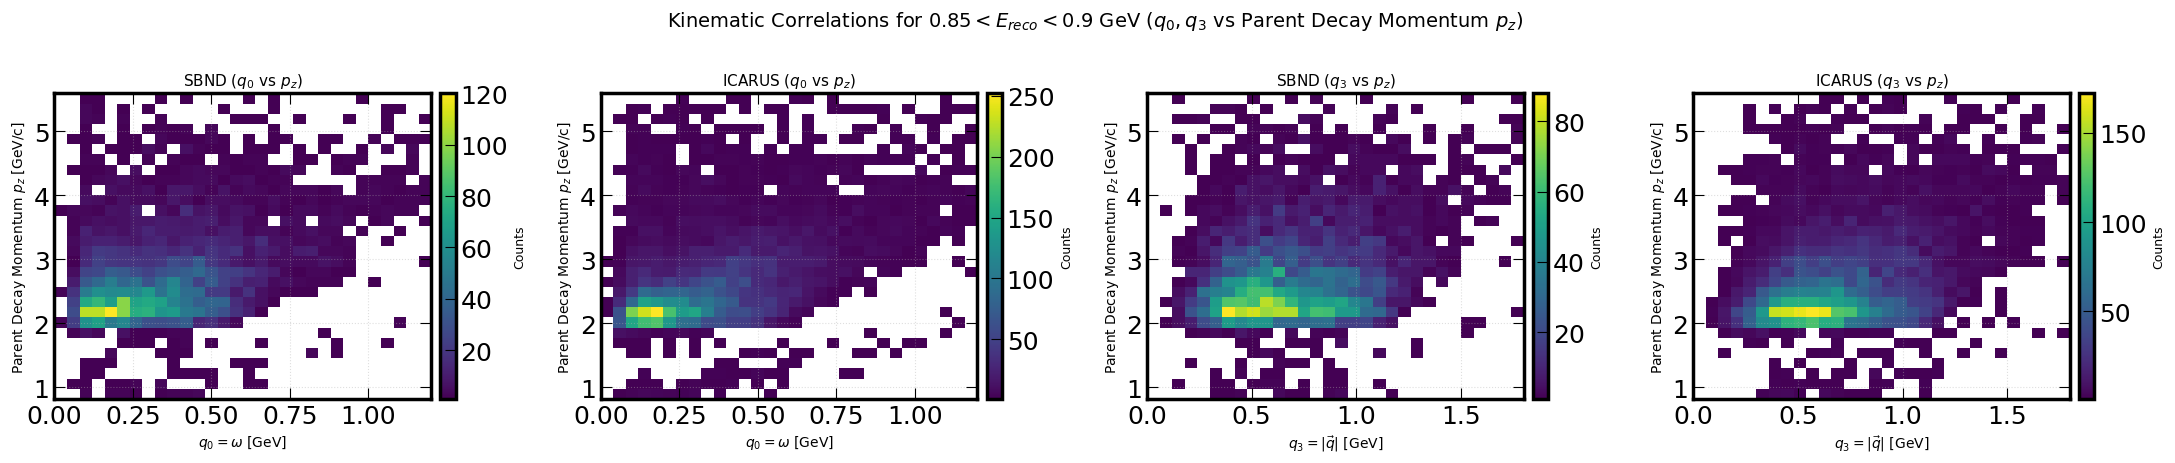

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.9 < E_{reco} < 0.95$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

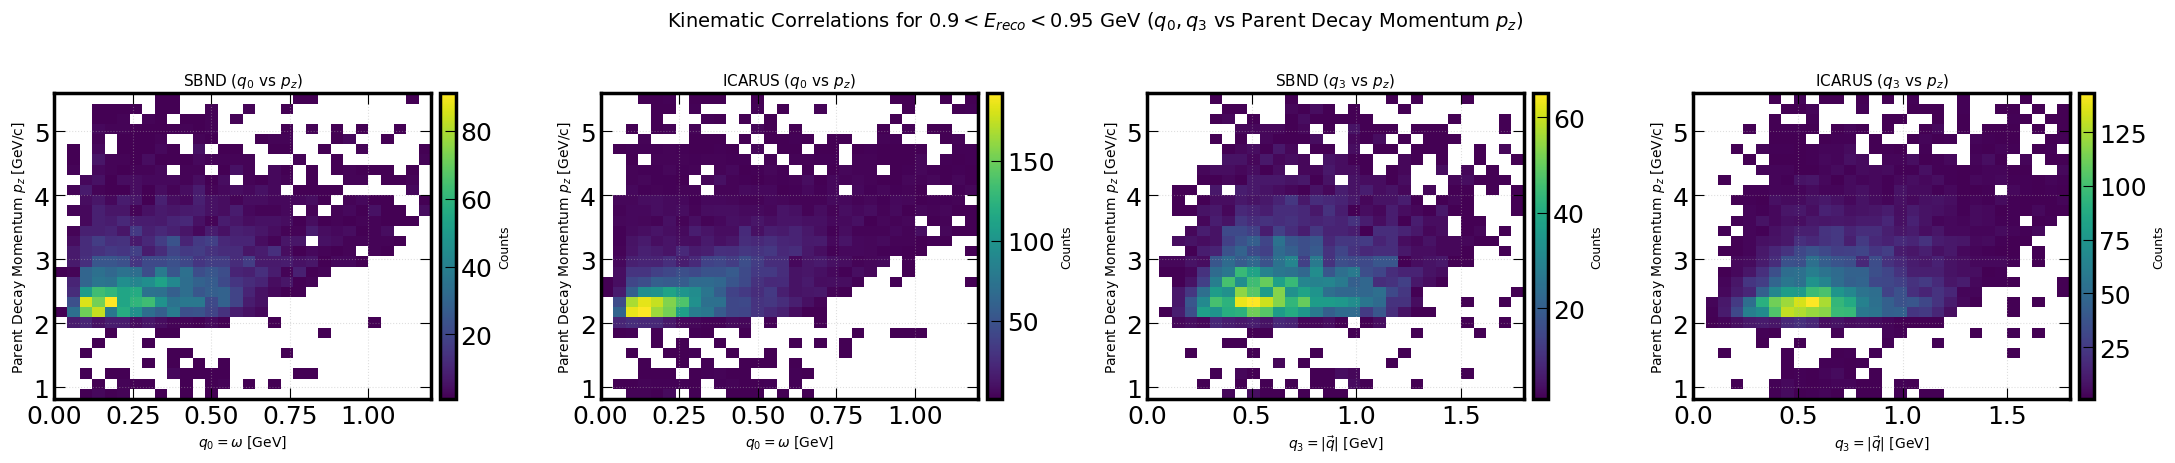

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $0.95 < E_{reco} < 1.0$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

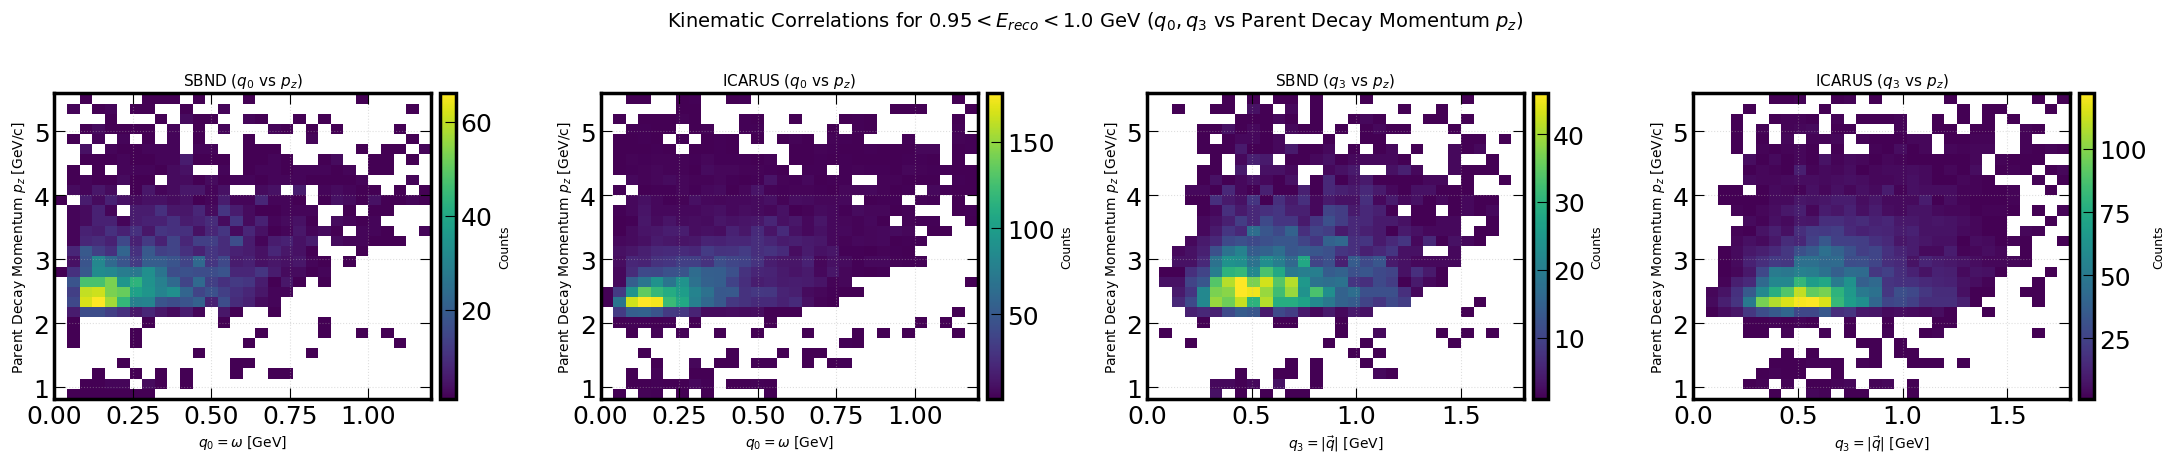

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $1.0 < E_{reco} < 1.25$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

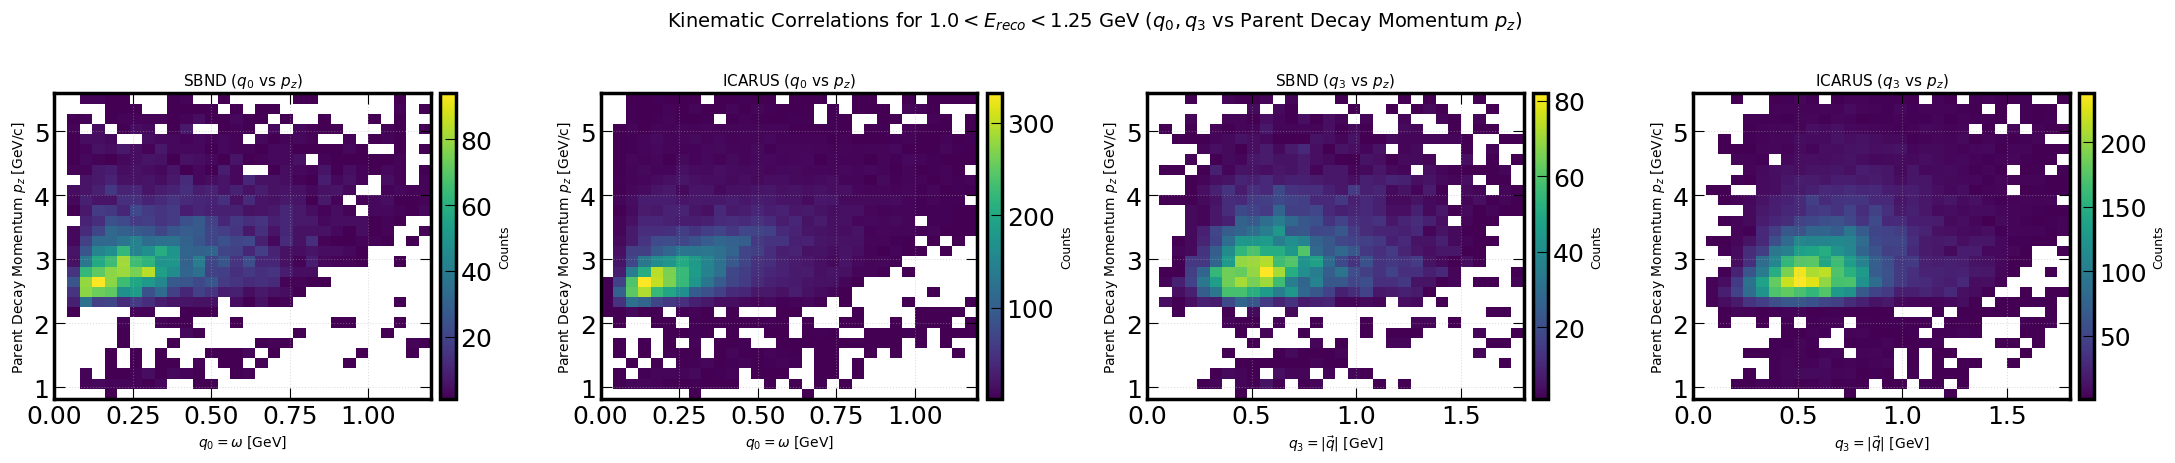

Text(0.5, 1.0, 'SBND ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_0$ vs $p_{z}$)')

Text(0.5, 1.0, 'SBND ($q_3$ vs $p_{z}$)')

Text(0.5, 1.0, 'ICARUS ($q_3$ vs $p_{z}$)')

Text(0.5, 1.02, 'Kinematic Correlations for $1.25 < E_{reco} < 1.5$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{z}$)')

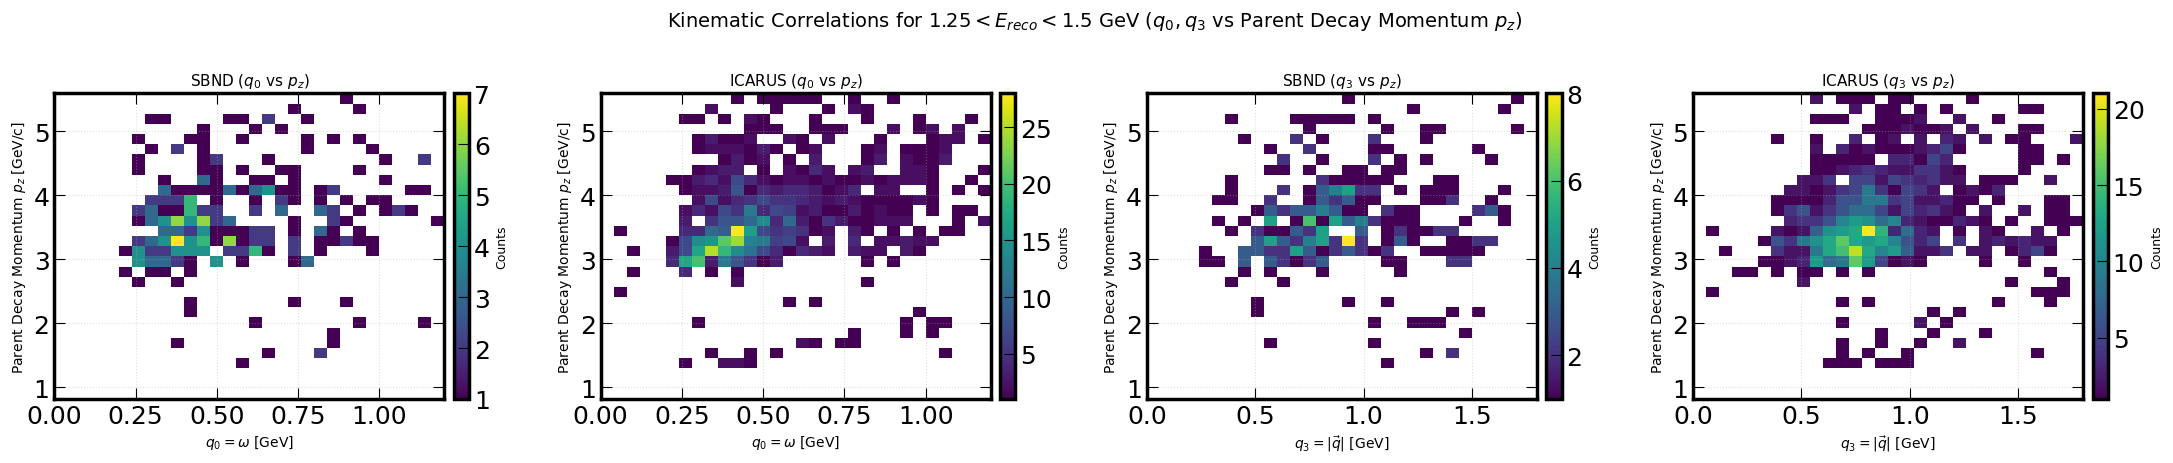

In [180]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# CONFIGURATION
# ==============================================================================
# Set to "x", "y", or "z" to select parent_dcy_mom component for the 2D y-axis
PARENT_MOM_VAR = "z"

# Particle masses in GeV
MUON_MASS = 0.105658
bins = np.array(
    [
        0.3,
        0.4,
        0.45,
        0.5,
        0.55,
        0.6,
        0.65,
        0.7,
        0.75,
        0.8,
        0.85,
        0.9,
        0.95,
        1.0,
        1.25,
        1.5,
    ]
)


def compute_true_q0_q3(df):
    """Computes true energy transfer (q0) and 3-momentum transfer magnitude (q3)

    from the DataFrame truth branches.
    """
    true_mu_E = np.sqrt(df["true_mu_p"] ** 2 + MUON_MASS**2)
    q0 = df["true_nu_E"] - true_mu_E

    cos_theta_mu = df["true_mu_dir_z"]
    q3_sq = (
        df["true_nu_E"] ** 2
        + df["true_mu_p"] ** 2
        - 2 * df["true_nu_E"] * df["true_mu_p"] * cos_theta_mu
    )

    q3 = np.sqrt(np.maximum(q3_sq, 0))
    return q0, q3


def plot_2d_hist(
    ax,
    df,
    x_col,
    y_col,
    detector_name,
    nbins=(30, 30),
    x_range=(0, 1.5),
    y_range=(-2, 10),
    xlabel="",
    ylabel="",
):
    """Plots a 2D histogram (heatmap) of kinematic variable vs parent decay momentum component."""
    if df.empty or y_col not in df.columns:
        ax.set_title(f"{detector_name} (No Data)")
        return

    counts, xedges, yedges, im = ax.hist2d(
        df[x_col],
        df[y_col],
        bins=nbins,
        range=[list(x_range), list(y_range)],
        cmap="viridis",
        cmin=1,  # leave empty/white where counts = 0
    )

    ax.set_xlabel(xlabel, fontsize=10, labelpad=4)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=4)
    ax.grid(True, linestyle=":", alpha=0.4)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Counts", fontsize=9)


# --- FIX B: Pre-assign target momentum column ONCE to avoid DataFrame copies ---
mom_col = f"parent_dcy_mom_{PARENT_MOM_VAR}"
mom_label = rf"Parent Decay Momentum $p_{{{PARENT_MOM_VAR}}}$ [GeV/c]"

# Extract momentum series safely (handles CAF nested naming vs flat naming)
key_nested = f"slcdf.slc.truth.parent_dcy_mom.{PARENT_MOM_VAR}"
key_flat = f"parent_dcy_mom_{PARENT_MOM_VAR}"
key_dot = f"parent_dcy_mom.{PARENT_MOM_VAR}"

Sdf[mom_col] = (
    Sdf[key_nested]
    if key_nested in Sdf.columns
    else Sdf.get(key_flat, Sdf.get(key_dot))
)
Idf[mom_col] = (
    Idf[key_nested]
    if key_nested in Idf.columns
    else Idf.get(key_flat, Idf.get(key_dot))
)

# --- Data Filtering & Processing ---
valid_bins = []
processed_data = []

for bl, br in zip(bins[:-1], bins[1:]):
    Sdf_clean = Sdf.loc[
        Sdf["selected"] & (Sdf.nu_E_calo > bl) & (Sdf.nu_E_calo < br)
    ].dropna(subset=["true_nu_E", "true_mu_p", "true_mu_dir_z", mom_col]).copy()

    Idf_clean = Idf.loc[
        Idf["selected"] & (Idf.nu_E_calo > bl) & (Idf.nu_E_calo < br)
    ].dropna(subset=["true_nu_E", "true_mu_p", "true_mu_dir_z", mom_col]).copy()

    if Sdf_clean.empty or Idf_clean.empty:
        print(
            f"Skipping bin {bl}-{br}: Insufficient data (SBND: {len(Sdf_clean)}, ICARUS: {len(Idf_clean)})"
        )
        continue

    Sdf_clean["q0_true"], Sdf_clean["q3_true"] = compute_true_q0_q3(Sdf_clean)
    Idf_clean["q0_true"], Idf_clean["q3_true"] = compute_true_q0_q3(Idf_clean)

    # Filter physical CC region (q3 >= q0 and q0 > 0)
    Sdf_clean = Sdf_clean[
        (Sdf_clean["q3_true"] >= Sdf_clean["q0_true"])
        & (Sdf_clean["q0_true"] > 0)
    ]
    Idf_clean = Idf_clean[
        (Idf_clean["q3_true"] >= Idf_clean["q0_true"])
        & (Idf_clean["q0_true"] > 0)
    ]

    valid_bins.append((bl, br))
    processed_data.append((Sdf_clean, Idf_clean))

# Determine common y-axis range based on percentiles across all valid data
all_mom_vals = []
for Sdf_clean, Idf_clean in processed_data:
    all_mom_vals.extend(Sdf_clean[mom_col].values)
    all_mom_vals.extend(Idf_clean[mom_col].values)

if len(all_mom_vals) > 0:
    y_min, y_max = np.percentile(all_mom_vals, [0.5, 99.5])
    mom_y_range = (y_min, y_max)
else:
    mom_y_range = (-1.0, 5.0)

# --- FIX A: Render Each Energy Bin as an Individual Figure ---
for (bl, br), (Sdf_clean, Idf_clean) in zip(valid_bins, processed_data):
    # 1 row x 4 columns figure per energy bin
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), dpi=100)

    # 1. SBND q0 vs parent_dcy_mom
    plot_2d_hist(
        axes[0],
        Sdf_clean,
        x_col="q0_true",
        y_col=mom_col,
        detector_name="SBND",
        nbins=(30, 30),
        x_range=(0, 1.2),
        y_range=mom_y_range,
        xlabel=r"$q_0 = \omega$ [GeV]",
        ylabel=mom_label,
    )
    axes[0].set_title(r"SBND ($q_0$ vs $p_{" + PARENT_MOM_VAR + r"}$)", fontsize=11)

    # 2. ICARUS q0 vs parent_dcy_mom
    plot_2d_hist(
        axes[1],
        Idf_clean,
        x_col="q0_true",
        y_col=mom_col,
        detector_name="ICARUS",
        nbins=(30, 30),
        x_range=(0, 1.2),
        y_range=mom_y_range,
        xlabel=r"$q_0 = \omega$ [GeV]",
        ylabel=mom_label,
    )
    axes[1].set_title(r"ICARUS ($q_0$ vs $p_{" + PARENT_MOM_VAR + r"}$)", fontsize=11)

    # 3. SBND q3 vs parent_dcy_mom
    plot_2d_hist(
        axes[2],
        Sdf_clean,
        x_col="q3_true",
        y_col=mom_col,
        detector_name="SBND",
        nbins=(30, 30),
        x_range=(0, 1.8),
        y_range=mom_y_range,
        xlabel=r"$q_3 = |\vec{{q}}|$ [GeV]",
        ylabel=mom_label,
    )
    axes[2].set_title(r"SBND ($q_3$ vs $p_{" + PARENT_MOM_VAR + r"}$)", fontsize=11)

    # 4. ICARUS q3 vs parent_dcy_mom
    plot_2d_hist(
        axes[3],
        Idf_clean,
        x_col="q3_true",
        y_col=mom_col,
        detector_name="ICARUS",
        nbins=(30, 30),
        x_range=(0, 1.8),
        y_range=mom_y_range,
        xlabel=r"$q_3 = |\vec{{q}}|$ [GeV]",
        ylabel=mom_label,
    )
    axes[3].set_title(r"ICARUS ($q_3$ vs $p_{" + PARENT_MOM_VAR + r"}$)", fontsize=11)

    fig.suptitle(
        rf"Kinematic Correlations for ${bl} < E_{{reco}} < {br}$ GeV ($q_0, q_3$ vs Parent Decay Momentum $p_{{{PARENT_MOM_VAR}}}$)",
        fontsize=14,
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

    # Free memory after rendering each figure
    plt.close(fig)

In [376]:
# Human-readable GENIE interaction mode labels
GENIE_MODE_MAP = {
    0: "CCQE",
    1: "CCRES",
    2: "CCDIS",
    3: "CCCoh",
    10: "CCMEC",
    1000: "NCQE",
    1001: "NCRES",
    1002: "NCDIS",
    1003: "NCCoh",
    1010: "NCMEC",
}


def get_genie_label(mode_code):
    """Returns human-readable string for GENIE mode, falling back to 'Mode X' if unmapped."""
    mode_int = int(mode_code)
    return GENIE_MODE_MAP.get(mode_int, f"Mode {mode_int}")


def plot_genie_pie(ax, df, detector_name, color_map):
    """Plots a pie chart showing genie_mode percentage composition for a given detector."""
    if df.empty or "genie_mode" not in df.columns:
        ax.text(
            0.5,
            0.5,
            f"{detector_name}\n(No Data)",
            ha="center",
            va="center",
            fontsize=12,
        )
        ax.axis("off")
        return

    # Count occurrences of each mode
    counts = df["genie_mode"].value_counts().sort_index()
    modes = counts.index.astype(int).tolist()
    values = counts.values

    labels = [get_genie_label(m) for m in modes]
    colors = [color_map[m] for m in modes]

    # Custom autopct function: hides percentages < 2% to avoid overlapping text
    def custom_autopct(pct):
        return f"{pct:.1f}%" if pct >= 2.0 else ""

    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,  # Handled via legend for cleanliness
        autopct=custom_autopct,
        pctdistance=0.7,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.6, edgecolor="white", linewidth=1.5),  # Donut style
    )

    # Style percentage text inside wedges
    plt.setp(autotexts, size=9, weight="bold", color="white")

    # Legend with breakdown count + percentage
    total = sum(values)
    legend_labels = [
        f"{lbl}: {val} ({val/total*100:.1f}%)"
        for lbl, val in zip(labels, values)
    ]

    ax.legend(
        wedges,
        legend_labels,
        title="GENIE Modes",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        frameon=True,
        fontsize=9,
        title_fontsize=10,
    )

    ax.set_title(
        f"{detector_name}\n($N_{{total}} = {total}$)", fontsize=12, pad=10
    )


# --- Pre-scan Data & Build Global Color Map ---
all_modes_set = set()
valid_bins = []
processed_data = []

for bl, br in zip(bins[:-1], bins[1:]):
    Sdf_clean = Sdf.loc[
        Sdf["selected"] & (Sdf.nu_E_calo > bl) & (Sdf.nu_E_calo < br)
    ].dropna(subset=["genie_mode"]).copy()
    Sdf_clean.loc[Sdf_clean.true_isnc == 1, 'genie_mode'] += 1000
    
    Idf_clean = Idf.loc[
        Idf["selected"] & (Idf.nu_E_calo > bl) & (Idf.nu_E_calo < br)
    ].dropna(subset=["genie_mode"]).copy()
    Idf_clean.loc[Idf_clean.true_isnc == 1, 'genie_mode'] += 1000
    
    if Sdf_clean.empty and Idf_clean.empty:
        print(f"Skipping bin {bl}-{br}: Insufficient data")
        continue

    all_modes_set.update(Sdf_clean["genie_mode"].dropna().unique())
    all_modes_set.update(Idf_clean["genie_mode"].dropna().unique())

    valid_bins.append((bl, br))
    processed_data.append((Sdf_clean, Idf_clean))

# Assign consistent color mapping across all pie charts
all_genie_modes = sorted([int(m) for m in all_modes_set])
cmap = plt.cm.get_cmap(
    "tab20" if len(all_genie_modes) > 10 else "tab10", len(all_genie_modes)
)
color_map = {mode: cmap(i) for i, mode in enumerate(all_genie_modes)}


# --- Processing Loop (Individual Figure Per Energy Bin) ---
for (bl, br), (Sdf_clean, Idf_clean) in zip(valid_bins, processed_data):
    print(f"--- Plotting GENIE composition pie charts for bin min:{bl}, max:{br} GeV ---")

    # 1 row x 2 columns figure per energy bin
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)
    
    # 1. SBND Pie Chart
    plot_genie_pie(
        axes[0],
        Sdf_clean,
        detector_name="SBND",
        color_map=color_map,
    )
    
    # 2. ICARUS Pie Chart
    plot_genie_pie(
        axes[1],
        Idf_clean,
        detector_name="ICARUS",
        color_map=color_map,
    )

    # Title for the energy bin
    fig.suptitle(
        rf"GENIE Mode Composition for ${bl} < E_{{reco}} < {br}$ GeV",
        fontsize=14,
        fontweight="bold",
        y=1.03,
    )

    plt.tight_layout()
    if DOSAVE:
        plt.savefig(PLOTDIR + f"/png/{bl}_{br}_mode.png", bbox_inches="tight")
    plt.close(fig)

--- Plotting GENIE composition pie charts for bin min:0.3, max:0.4 GeV ---


/tmp/ipykernel_1892/3739143578.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(


Text(0.5, 1.03, 'GENIE Mode Composition for $0.3 < E_{reco} < 0.4$ GeV')

--- Plotting GENIE composition pie charts for bin min:0.4, max:0.45 GeV ---


Text(0.5, 1.03, 'GENIE Mode Composition for $0.4 < E_{reco} < 0.45$ GeV')

...

Text(0.5, 1.03, 'GENIE Mode Composition for $0.95 < E_{reco} < 1.0$ GeV')

--- Plotting GENIE composition pie charts for bin min:1.0, max:1.25 GeV ---


Text(0.5, 1.03, 'GENIE Mode Composition for $1.0 < E_{reco} < 1.25$ GeV')

--- Plotting GENIE composition pie charts for bin min:1.25, max:1.5 GeV ---


Text(0.5, 1.03, 'GENIE Mode Composition for $1.25 < E_{reco} < 1.5$ GeV')

In [375]:
from rwt_map import *
plot_2d_hist_from_file('../win_len/SBND_DENT.txt', 'DENT', 'DENT')

<Figure size 1000x600 with 0 Axes>

In [386]:
bl = 0.3
br = 0.4

Sdf_clean = Sdf.loc[
        (Sdf.genie_mode == 1) & (Sdf.true_isnc == 0) & Sdf["selected"] & (Sdf.nu_E_calo > bl) & (Sdf.nu_E_calo < br)
    ]

Idf_clean = Idf.loc[
        (Idf.genie_mode == 1) & (Idf.true_isnc == 0) & Idf["selected"] & (Idf.nu_E_calo > bl) & (Idf.nu_E_calo < br)
    ]

1947
1590


([<matplotlib.patches.Wedge at 0x7fb85c97af20>,
 [Text(0.524185885762101, -0.9670724673817376, '$\\mu^-$'),
  Text(-0.3936809067643927, 1.0271393983530988, '$\\pi^+$'),
  Text(-0.690849509078876, 0.8559947171597942, 'Proton'),
  Text(-0.7965160810035075, 0.7586581131859159, 'Other')],
 [Text(0.2859195740520551, -0.5274940731173113, '88.0%'),
  Text(-0.2147350400533051, 0.5602578536471448, '7.8%'),
  Text(-0.37682700495211413, 0.4669062093598877, '2.2%'),
  Text(-0.43446331691100404, 0.4138135162832268, '2.0%')])

Text(0.5, 1.0, 'Sdf_clean: true_mucand_pdg')

([<matplotlib.patches.Wedge at 0x7fb84d450160>,
 [Text(0.2513268408231049, -1.070903739409793, '$\\mu^-$'),
  Text(0.07022609395638214, 1.0977560274157594, '$\\pi^+$'),
  Text(-0.4919524061785132, 0.983861184342167, 'Proton'),
  Text(-0.7562705686886567, 0.798783341673658, 'Other')],
 [Text(0.13708736772169358, -0.5841293124053416, '79.6%'),
  Text(0.03830514215802662, 0.5987760149540505, '11.1%'),
  Text(-0.2683376760973708, 0.5366515550957274, '5.7%'),
  Text(-0.4125112192847218, 0.435700004549268, '3.6%')])

Text(0.5, 1.0, 'Idf_clean: true_mucand_pdg')

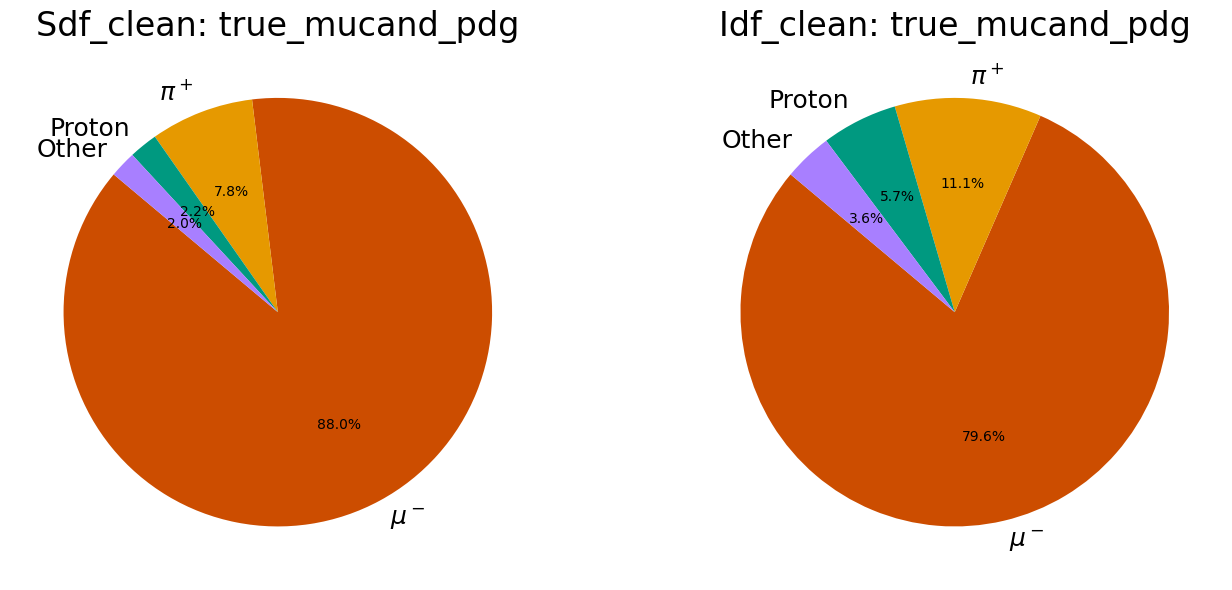

In [399]:
import matplotlib.pyplot as plt
import pandas as pd

pdg_map = {
    13: r'$\mu^-$',
    -13: r'$\mu^+$',
    211: r'$\pi^+$',
    -211: r'$\pi^-$',
    11: r'$e^-$',
    -11: r'$e^+$',
    2212: 'Proton',
    22: r'$\gamma$'
}

# Pass labels=sdf_labels and labels=idf_labels to pie()

def group_small_categories(series, threshold=0.015):
    """Group values accounting for less than `threshold` into an 'Other' category."""
    counts = series.value_counts()
    total = counts.sum()
    
    # Identify categories above and below the threshold
    mask = (counts / total) >= threshold
    main_counts = counts[mask].copy()
    other_sum = counts[~mask].sum()
    
    # Add 'Other' category if any small categories were grouped
    if other_sum > 0:
        main_counts['Other'] = other_sum
        
    return main_counts

# Process data for both DataFrames
sdf_counts = group_small_categories(Sdf_clean['true_mucand_pdg'])
idf_counts = group_small_categories(Idf_clean['true_mucand_pdg'])

# Map numeric PDG IDs to particle strings, leaving 'Other' untouched
sdf_labels = [pdg_map.get(k, str(k)) for k in sdf_counts.index]
idf_labels = [pdg_map.get(k, str(k)) for k in idf_counts.index]

# Plot side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    sdf_counts, 
    autopct='%1.1f%%', 
    startangle=140,
    labels=sdf_labels
)
axes[0].set_title('Sdf_clean: true_mucand_pdg')

axes[1].pie(
    idf_counts, 
    autopct='%1.1f%%', 
    startangle=140,
    labels=idf_labels
)
axes[1].set_title('Idf_clean: true_mucand_pdg')

plt.tight_layout()
plt.show()

([<matplotlib.patches.Wedge at 0x7fb85d3cdf60>,
 [Text(0.6853102966482558, -0.8604358182385713, 'Proton'),
  Text(-0.5673286153466477, 0.9424108669836397, '$\\pi^+$'),
  Text(-0.6797422743451019, 0.864841280506515, '$\\mu^-$'),
  Text(-0.7550096456394662, 0.7999752714874179, '$\\gamma$'),
  Text(-0.8134492502032717, 0.7404730362030308, 'Other')],
 [Text(0.37380561635359405, -0.46932862813012977, '93.6%'),
  Text(-0.3094519720072624, 0.5140422910819853, '2.2%'),
  Text(-0.3707685132791465, 0.4717316075490081, '1.7%'),
  Text(-0.4118234430760724, 0.43635014808404604, '1.1%'),
  Text(-0.44369959101996637, 0.40389438338347133, '1.3%')])

Text(0.5, 1.0, 'Sdf_clean: true_pcand_pdg')

([<matplotlib.patches.Wedge at 0x7fb84d6b8d30>,
 [Text(0.6406889655169263, -0.8941575081968786, 'Proton'),
  Text(-0.5055119064308408, 0.9769635164409453, '$\\mu^-$'),
  Text(-0.666903623151073, 0.8747797193739528, '$\\pi^+$'),
  Text(-0.7531070935513096, 0.8017666154453547, '$\\gamma$'),
  Text(-0.8125942429609283, 0.7414112194367953, 'Other')],
 [Text(0.349466708463778, -0.48772227719829736, '92.0%'),
  Text(-0.2757337671440949, 0.5328891907859701, '3.4%'),
  Text(-0.36376561262785795, 0.4771525742039742, '2.1%'),
  Text(-0.41078568739162336, 0.4373272447883752, '1.1%'),
  Text(-0.4432332234332336, 0.4044061196927974, '1.3%')])

Text(0.5, 1.0, 'Idf_clean: true_pcand_pdg')

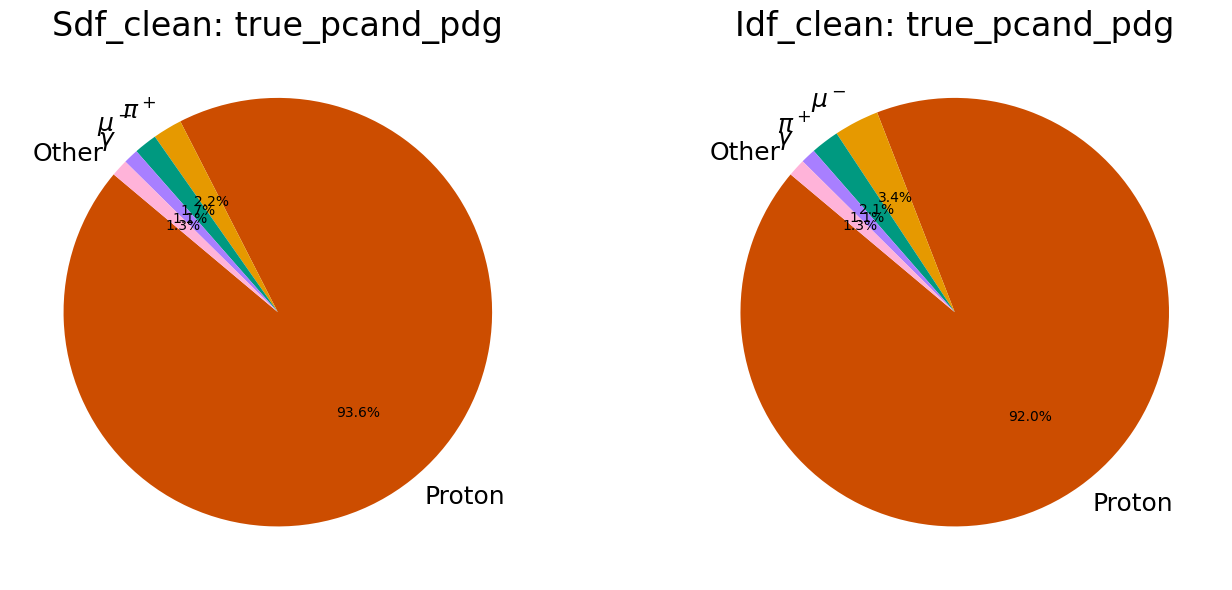

In [398]:
import matplotlib.pyplot as plt
import pandas as pd

pdg_map = {
    13: r'$\mu^-$',
    -13: r'$\mu^+$',
    211: r'$\pi^+$',
    -211: r'$\pi^-$',
    11: r'$e^-$',
    -11: r'$e^+$',
    2212: 'Proton',
    22: r'$\gamma$'
}

# Pass labels=sdf_labels and labels=idf_labels to pie()

def group_small_categories(series, threshold=0.01):
    """Group values accounting for less than `threshold` into an 'Other' category."""
    counts = series.value_counts()
    total = counts.sum()
    
    # Identify categories above and below the threshold
    mask = (counts / total) >= threshold
    main_counts = counts[mask].copy()
    other_sum = counts[~mask].sum()
    
    # Add 'Other' category if any small categories were grouped
    if other_sum > 0:
        main_counts['Other'] = other_sum
        
    return main_counts

# Process data for both DataFrames
sdf_counts = group_small_categories(Sdf_clean['true_pcand_pdg'])
idf_counts = group_small_categories(Idf_clean['true_pcand_pdg'])

# Map numeric PDG IDs to particle strings, leaving 'Other' untouched
sdf_labels = [pdg_map.get(k, str(k)) for k in sdf_counts.index]
idf_labels = [pdg_map.get(k, str(k)) for k in idf_counts.index]

# Plot side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    sdf_counts, 
    autopct='%1.1f%%', 
    startangle=140,
    labels=sdf_labels
)
axes[0].set_title('Sdf_clean: true_pcand_pdg')

axes[1].pie(
    idf_counts, 
    autopct='%1.1f%%', 
    startangle=140,
    labels=idf_labels
)
axes[1].set_title('Idf_clean: true_pcand_pdg')

plt.tight_layout()
plt.show()

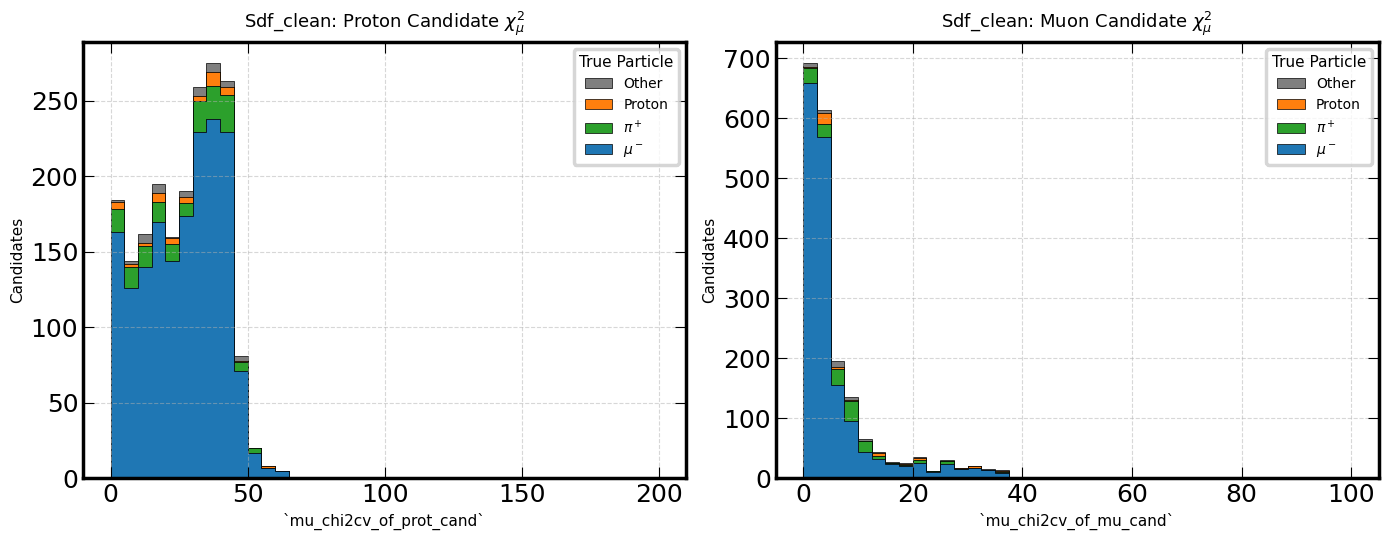

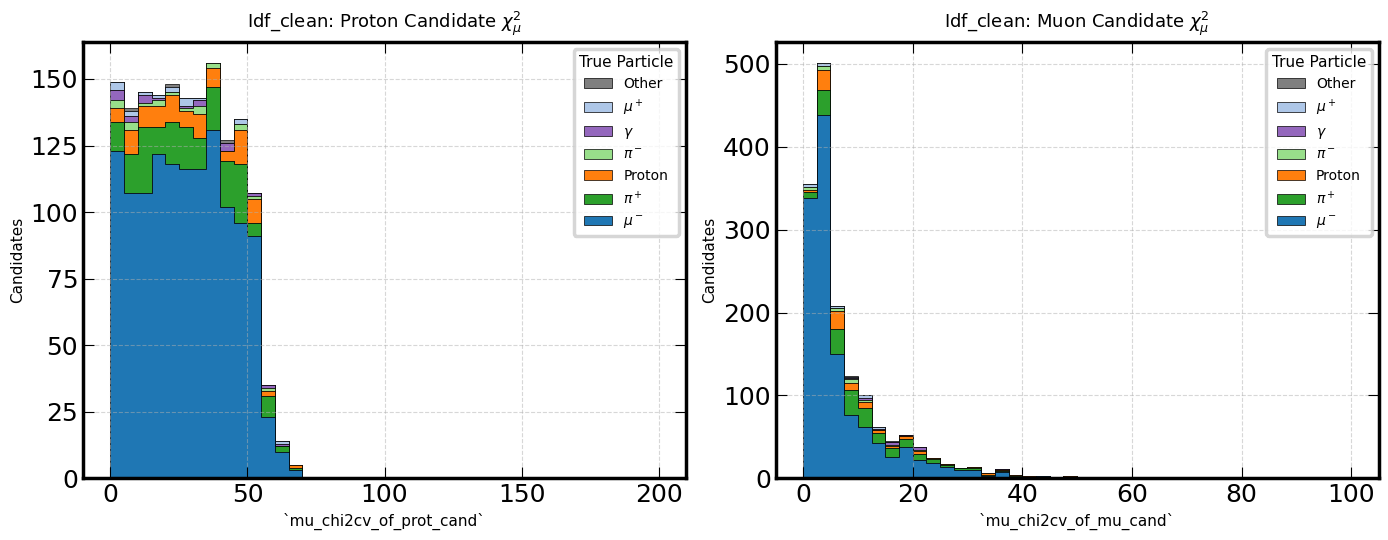

In [404]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define PDG categories and custom labels/colors for particle species
# Group rarer background species together into 'Other'
PDG_CONFIG = {
    13: {"label": r"$\mu^-$", "color": "#1f77b4"},  # Blue
    -13: {"label": r"$\mu^+$", "color": "#aec7e8"},  # Light Blue
    211: {"label": r"$\pi^+$", "color": "#2ca02c"},  # Green
    -211: {"label": r"$\pi^-$", "color": "#98df8a"},  # Light Green
    2212: {"label": "Proton", "color": "#ff7f0e"},  # Orange
    11: {"label": r"$e^-$ / $e^+$", "color": "#d62728"},  # Red
    -11: {"label": r"$e^-$ / $e^+$", "color": "#d62728"},  # Red (merged)
    22: {"label": r"$\gamma$", "color": "#9467bd"},  # Purple
}


def prepare_stacked_data(df, var_col, pdg_col="true_mucand_pdg", min_share=0.01):
  """Splits variable data into a list of arrays grouped by PDG ID for stacked plotting."""
  df_clean = df.dropna(subset=[var_col, pdg_col])
  counts = df_clean[pdg_col].value_counts()
  total = len(df_clean)

  data_list = []
  labels = []
  colors = []

  # Group main categories
  other_mask = pd.Series(True, index=df_clean.index)

  for pdg, count in counts.items():
    if (count / total) >= min_share and pdg in PDG_CONFIG:
      mask = df_clean[pdg_col] == pdg
      data_list.append(df_clean.loc[mask, var_col])

      cfg = PDG_CONFIG[pdg]
      labels.append(cfg["label"])
      colors.append(cfg["color"])
      other_mask &= ~mask

  # Group remaining into 'Other'
  other_data = df_clean.loc[other_mask, var_col]
  if len(other_data) > 0:
    data_list.append(other_data)
    labels.append("Other")
    colors.append("#7f7f7f")  # Gray

  return data_list, labels, colors


def plot_stacked_particle_breakdown(
    df,
    vars_to_plot,
    pdg_col="true_mucand_pdg",
    bins=40,
    var_ranges=None,
    dataset_name="Sdf_clean",
):
  """Plots side-by-side stacked histograms for specified variables."""
  fig, axes = plt.subplots(
      1, len(vars_to_plot), figsize=(7 * len(vars_to_plot), 5.5)
  )

  if len(vars_to_plot) == 1:
    axes = [axes]

  for i, (var_col, title_name) in enumerate(vars_to_plot):
    ax = axes[i]
    var_range = var_ranges.get(var_col, None) if var_ranges else None

    # Get data grouped by particle type
    data_list, labels, colors = prepare_stacked_data(
        df, var_col, pdg_col=pdg_col
    )

    # Plot stacked histogram
    n, bin_edges, patches = ax.hist(
        data_list,
        bins=bins,
        range=var_range,
        stacked=True,
        label=labels,
        color=colors,
        histtype="stepfilled",
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set_xlabel(f"`{var_col}`", fontsize=11)
    ax.set_ylabel("Candidates", fontsize=11)
    ax.set_title(f"{dataset_name}: {title_name}", fontsize=13, pad=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(title="True Particle", fontsize=10, title_fontsize=11)

  plt.tight_layout()
  plt.show()


# --- Variables to plot ---
vars_to_plot = [
    ("mu_chi2cv_of_prot_cand", "Proton Candidate $\chi^2_\mu$"),
    ("mu_chi2cv_of_mu_cand", "Muon Candidate $\chi^2_\mu$"),
]

# Optional fixed x-axis ranges (adjust boundaries to fit your data range)
var_ranges = {
    "mu_chi2cv_of_prot_cand": (0, 200),
    "mu_chi2cv_of_mu_cand": (0, 100),
}

# --- Execute Plots ---
# Run for Sdf_clean
plot_stacked_particle_breakdown(
    Sdf_clean,
    vars_to_plot,
    var_ranges=var_ranges,
    dataset_name="Sdf_clean",
    bins=40,
)

# Run for Idf_clean
plot_stacked_particle_breakdown(
    Idf_clean,
    vars_to_plot,
    var_ranges=var_ranges,
    dataset_name="Idf_clean",
    bins=40,
)

In [406]:
for c in Sdf_clean.columns:
    print(c)

other_shw_length
other_trk_length
slc_vtx_x
slc_vtx_y
slc_vtx_z
is_clear_cosmic
nu_score
crlongtrkdiry
mu_chi2_of_mu_cand
mu_chi2_of_prot_cand
prot_chi2_of_mu_cand
prot_chi2_of_prot_cand
p_len
mu_len
nu_E_calo
mu_E
mu_T
p_E
p_T
mu_dist_to_vertex
p_dist_to_vertex
mu_track_score
p_track_score
mu_end_x
mu_end_y
mu_end_z
p_end_x
p_end_y
p_end_z
mu_dir_x
mu_dir_y
mu_dir_z
p_dir_x
p_dir_y
p_dir_z
parent_dcy_E
parent_dcy_mode
parent_dcy_mom_x
parent_dcy_mom_y
parent_dcy_mom_z
parent_pdg
del_p
del_Tp
del_phi
has_stub
tmatch_idx
tmatch_eff
tmatch_pur
true_prism_angle
true_nu_costh
baseline
true_baseline
nu_E_true
true_nu_E
true_pdg
true_nu_pdg_x
is_cosmic
true_is_cosmic
true_nu_vtx_x
true_nu_vtx_y
true_nu_vtx_z
p_true_p
true_pcand_p
p_true_pdg
true_pcand_pdg
true_pcand_dir_x
true_pcand_dir_y
true_pcand_dir_z
true_pcand_end_x
true_pcand_end_y
true_pcand_end_z
mu_true_p
true_mucand_p
mu_true_pdg
true_mucand_pdg
true_mucand_dir_x
true_mucand_dir_y
true_mucand_dir_z
true_mucand_end_x
true_mucand_en